# Lab 07: 如何找出真正的根因

```mermaid
flowchart LR
    M1["照直覺查一遍<br/>用幅度排"] --> M2["四種證據<br/>位置、關聯<br/>時序、可預測性"] --> M3["合成一個排名<br/>Score(c)"] --> M4["LLM 架構<br/>打包 context<br/>檢索領域知識"] --> M5["LLM 診斷<br/>與驗證"] --> M6["換產業、換檢索<br/>回饋迴路與上線"]
```


<p align="center"><img src="slides/u08_symptom_vs_cause.png" width="80%" alt="單元 08 的症狀與根因投影片: 最異常的指標不一定是根因 (下游症狀常比上游根因更劇烈) 、最早發生的異常也不一定是根因 (時間先後是重要證據但不是充分條件) 、可信 Root Cause 應具備的六個特徵，以及根因的操作性定義: 元件層、指標層、事件層、機制層四種輸出粒度"></p>

## 先看拓樸: 五個 port 在哪裡、各自負責什麼業務

#### RCA 要找的不是最明顯的異常，是最能解釋整場事件的原因。

**講義把傳播拆成三種形狀，這一章的資料裡三種都出現過**: 
- 依賴傳播 (上游劣化沿著呼叫關係往下擴散,**就是這一章示範的事故 L**)
- 扇出 (共用資源讓多個下游同時異常，事故 G 的廣播風暴是這一種)
- 級聯故障 (小問題因重試與排隊逐步放大)。

#### 五個 port 各自對應一段業務

| port | port_role | 在三竹的角色 | 發生異常事件的後果 |
| --- | --- | --- | --- |
| `port-id7427` | wan-primary | 對外主線: 券商行情連線、行動下單回報、企業簡訊發送出口 | 下單回報延遲、簡訊發送延遲 |
| `port-id7428` | wan-secondary | 對外備援線 | 主線發生異常事件時沒有退路 |
| `port-id7429` | server-uplink | 行情推播與交易主機群的 uplink | 報價更新變慢 |
| `port-id7430` | office-vlan | 內部辦公與開發 | 影響內部，不影響客戶 |
| `port-id7431` | backup-storage | 日終對帳與備份 | 對帳與結算延後 |

#### 三層拓樸

```mermaid
flowchart LR
    W1["port-id7427<br/>wan-primary"] --> FW["edge-fw-01"]
    W2["port-id7428<br/>wan-secondary"] -.->|"備援"| FW
    FW --> CORE["core-sw-01"]
    CORE --> S1["port-id7429<br/>server-uplink"]
    CORE --> S2["port-id7430<br/>office-vlan"]
    CORE --> DIST["dist-sw-02"]
    DIST --> B1["port-id7431<br/>backup-storage"]
```

這張圖有三件事後面每一節都會用到:

- **只有 `port-id7427` 有現用下游。** 它後面掛著主機群、辦公網段與備份儲存，所以它出問題的時候，那三個 port 會一起有反應
- **`port-id7428` 的下游是空的。** 它是備援線 (圖上的虛線)，這是事故發生前就寫在 CMDB 裡的事實，不是拿事後的答案回頭補的
- **`port-id7429`、`port-id7430`、`port-id7431` 在這張 port 層的依賴圖上是末端**,下游可達範圍是空的，所以它們出問題不會沿著這張圖往下傳

資料就是 Lab 06 那一份，欄位、取樣與事件目錄完全相同。


---

## 載入套件


In [1]:
# 🎯 載入套件、設定中文字型、找到課程資料的位置。
#    這一本只用 numpy / pandas / scipy / matplotlib，networkx 缺了只降級。
#    整本 notebook 要從這一格開始，由上往下依序執行; 跳過任何一格，後面都會出錯。
from pathlib import Path
import base64, io, json, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as _fm
from scipy import stats
from IPython.display import HTML, display

# ============ ⚙️ 可調參數 ============
# CJK_CANDIDATES: 圖上的中文用哪一套字型，由左到右試，用第一個裝得到的。
#                 一個都沒裝到不影響任何數字，只會讓圖上的中文變方框。
CJK_CANDIDATES = ["PingFang TC", "PingFang HK", "Heiti TC", "Arial Unicode MS",   # macOS
                  "Microsoft JhengHei", "Microsoft YaHei",                        # Windows
                  "Noto Sans CJK TC", "Noto Sans TC", "Source Han Sans TW",       # Linux
                  "WenQuanYi Zen Hei", "Droid Sans Fallback"]
ACC, GREY, INK = "tab:red", "0.55", "0.25"    # 全書配色: 一個強調色，其餘一律走灰階
# ====================================

# ---- 1. 關掉套件的雜訊訊息，統一圖與表的外觀 ----
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
_installed = {f.name for f in _fm.fontManager.ttflist}
CJK_FONT = next((f for f in CJK_CANDIDATES if f in _installed), None)
if CJK_FONT:
    plt.rcParams["font.sans-serif"] = [CJK_FONT] + plt.rcParams["font.sans-serif"]
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["axes.unicode_minus"] = False        # 用 ASCII 的減號，中文字型才畫得出負號
# 這一章有的表欄很多，有的格子裝的是整段診斷文字，設寬一點兩種表才都印得完。
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 220)


def show_fig(fig, width="80%"):
    """把圖存成 PNG，再以 80% 寬度置中顯示，然後關掉它。

    直接 display(fig) 會靠左，寬度也只由 figsize 決定; 轉成 <img> 才控制得了寬度與置中。
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=fig.dpi, bbox_inches="tight")
    plt.close(fig)
    src = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")
    display(HTML(f'<div style="text-align: center">'
                 f'<img src="{src}" style="width: {width}"></div>'))


# ---- 2. 檔案放在哪一層 ----
#         從 notebook 自己的位置往上一層一層找，第一個看得到 data/synthetic 的就是根目錄。
NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR
while (PROJECT_ROOT != PROJECT_ROOT.parent
       and not (PROJECT_ROOT / "data" / "synthetic").is_dir()
       and not (PROJECT_ROOT / "environments").is_dir()):
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_SYNTHETIC = PROJECT_ROOT / "data" / "synthetic"       # 課程資料放這裡 (只讀不寫)
DATA_PROCESSED = PROJECT_ROOT / "outputs" / "workshop"     # 這一套教材算完的結果寫這裡
if not (DATA_SYNTHETIC / "synthetic_rrd_metrics_week6.csv").exists():
    raise FileNotFoundError(
        f"找不到課程資料 {DATA_SYNTHETIC / 'synthetic_rrd_metrics_week6.csv'}\n"
        f"目前所在資料夾是 {NB_DIR}\n"
        "請關掉 JupyterLab，改成在 week6 這個資料夾裡重新打開它，再開這本 notebook。")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# ---- 3. 選配套件: networkx 缺了就降級 ----
#         拓樸那一節本來呼叫它的 descendants() 沿著依賴表往下走，沒有它就改用那一格裡
#         自己寫的走訪程式跑同一張依賴表。兩條路算出來的下游集合一模一樣。
try:
    import networkx as nx
    HAS_NX = True
except Exception:
    HAS_NX = False

display(pd.DataFrame([
    ("repo 根目錄", str(PROJECT_ROOT)),
    ("中文字型", CJK_FONT if CJK_FONT else "找不到，圖上的中文會變成方框"),
    ("networkx", f"{HAS_NX}  (缺了會降級成寫死的下游表)"),
    ("其他套件", "不需要。關聯用 numpy、Granger 自己寫、檢索是數詞"),
], columns=["環境", "狀態"]))


,環境,狀態
0,repo 根目錄,E:\桌面\agent_os\database\NTU_POLab\AIAxMitake\github_code\aiops-anomaly-zero-to-hero\week6
1,中文字型,Microsoft JhengHei
2,networkx,True (缺了會降級成寫死的下游表)
3,其他套件,不需要。關聯用 numpy、Granger 自己寫、檢索是數詞


---

## 載入資料



In [2]:
# 🎯 讀進 Week 6 補充資料集、做同一份特徵工程 (同 Lab 01)，並鎖定這一章要走的那次事故。

# ============ ⚙️ 可調參數 ============
INCIDENT_ID = "L"    # 這一章示範哪一次事故。選 L 的理由: 它是「上游輕微劣化、下游反應劇烈」
                     # 的例子，正好是照幅度排名會排錯的那一種。其餘 16 個評估那一節會全部跑過
# METRICS: 後面每一節要掃過哪幾欄 (z 分數、異常起點、相關係數、Granger 都是對這八欄各算一次)。
#   只留 traffic_total: 這一章的根因在流量上是 -0.50，它從頭到尾不會進候選，示範就跑不出來。
METRICS = ["traffic_total", "error_rate", "discard_rate", "broadcast_total",
           "multicast_total", "unknown_total", "ucast_total", "avg_packet_size"]
# SIGNATURE_METRIC: 每一種事故型別「最該動」的那個量。排名程式先查這張表決定要拿哪一欄去算
#   z 與 onset，所以缺一個鍵整個事故就排不出來。這張表是領域知識不是從資料學出來的:
#   光路劣化先出現位元錯誤，所以是 error_rate; 佇列塞住先出現丟棄，所以是 discard_rate。
SIGNATURE_METRIC = {
    "queue_congestion": "discard_rate",
    "link_quality_issue": "error_rate",
    "broadcast_storm": "broadcast_total",
    "multicast_flooding": "multicast_total",
    "large_file_backup": "traffic_total",
    "business_traffic_growth": "traffic_total",
    "small_packet_scan": "ucast_total",
    "abnormal_device_sender": "traffic_total",
    "unknown_protocol_scan": "unknown_total",
    "load_sensitive_link_issue": "error_rate",
    # Week 6 補充資料集新增的七種
    "batch_egress_saturation": "traffic_total",       # K: 月結簡訊大量送出把出口推到飽和
    "benign_batch_ramp": "traffic_total",             # K_BENIGN: 同形狀但不越線的對照組
    "quote_push_batch_ramp": "traffic_total",         # M: 行情推播檔期的爬坡
    "benign_capacity_growth": "traffic_total",        # N: 多週良性成長
    "batch_window_overrun": "traffic_total",          # P: 日終對帳逐日長大
    "upstream_partial_outage": "traffic_total",       # R: 異常方向是流量往下掉，不是往上升
    "optical_degradation_failover": "error_rate",     # L: 光路劣化，溫和的錯誤上升
}
# ====================================


# ---- 1. 特徵工程: 從 RRD 累積計數器算出語意特徵 (同 Lab 01) ----
#         只做兩種事: 把同一件事的 IN 與 OUT 加起來變成總量，以及把壞掉的封包數換成比率。
#         用比率的原因是錯誤數會跟著流量一起變大，而五個 port 的流量差好幾個數量級。
def build_features(df):
    df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)
    sdiv = lambda a, b: np.where(b > 0, a / b, 0.0)     # 分母是 0 的格子直接給 0
    df["traffic_total"]   = df["INOCTETS"] + df["OUTOCTETS"]
    df["ucast_total"]     = df["INUCASTPKTS"] + df["OUTUCASTPKTS"]
    df["broadcast_total"] = df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]
    df["multicast_total"] = df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]
    df["errors_total"]    = df["INERRORS"] + df["OUTERRORS"]
    df["discards_total"]  = df["INDISCARDS"] + df["OUTDISCARDS"]
    df["error_rate"]      = sdiv(df["errors_total"], df["ucast_total"])
    df["discard_rate"]    = sdiv(df["discards_total"], df["ucast_total"])
    df["unknown_total"]   = df["INUNKNOWNPROTOS"]
    df["avg_packet_size"] = sdiv(df["traffic_total"], df["ucast_total"])
    return df


# ---- 2. 讀三個檔 ----
#         指標是每 5 分鐘一列的量測值; 事件目錄是「哪一次事故、注入在哪個 port、幾點到幾點」
#         的標準答案; 排程日曆是事先公告過的例行行為，所以它們是排程不是異常。
RRD_CSV = DATA_SYNTHETIC / "synthetic_rrd_metrics_week6.csv"
raw = pd.read_csv(RRD_CSV, parse_dates=["timestamp"])
features = build_features(raw)
events = pd.read_csv(DATA_SYNTHETIC / "synthetic_event_catalog_week6.csv",
                     parse_dates=["start_time", "end_time"])
SCHEDULED = pd.read_csv(DATA_SYNTHETIC / "synthetic_scheduled_calendar_week6.csv",
                        parse_dates=["start_time", "end_time"])
# 用開盤微爆當判準挑出交易日: 它每一個交易日都會發生一次，非交易日不會有。
TRADING_DAYS = {t.date() for t in SCHEDULED[SCHEDULED.kind == "market_open_microburst"].start_time}

ALL_PORTS = sorted(features.port_id.unique())
features = features.sort_values(["port_id", "timestamp"]).reset_index(drop=True)
# 把一張大表依 port_id 拆成五張小表，時間設成索引，之後才能用 .loc[起:迄] 直接切一段時間。
feat_by_port = {p: g.set_index("timestamp") for p, g in features.groupby("port_id")}


# ---- 3. 鎖定這一章要走的那次事故，並查出它的簽章指標 ----
def signature_metric(event_type):
    """查不到就講清楚是哪一個型別缺鍵，不要丟一個只有型別名字的裸 KeyError。"""
    if event_type not in SIGNATURE_METRIC:
        raise ValueError(f"event_type「{event_type}」還沒有對應的 signature metric，"
                         f"請在 SIGNATURE_METRIC 補上這個鍵。"
                         f"目前有的型別: {sorted(SIGNATURE_METRIC)}")
    return SIGNATURE_METRIC[event_type]


INCIDENT = events[events.event_id == INCIDENT_ID].iloc[0]
SIGNATURE = signature_metric(INCIDENT.event_type)   # 這一章之後每一節都拿這一欄當主軸

display(pd.DataFrame([
    ("資料", f"{len(features):,} 列，{features.timestamp.min():%Y-%m-%d} 到 "
             f"{features.timestamp.max():%Y-%m-%d}，{len(ALL_PORTS)} 個 port，5 分鐘取樣"),
    ("排程日曆", f"{len(SCHEDULED)} 筆 ｜ {len(TRADING_DAYS)} 個交易日 "
                 f"(最後一個 {max(TRADING_DAYS)}) ｜ 種類 {'、'.join(sorted(SCHEDULED.kind.unique()))}"),
    ("這一章的事故", f"{INCIDENT.event_id}  {INCIDENT.event_type}"),
    ("時窗", f"{INCIDENT.start_time:%Y-%m-%d %H:%M} 到 {INCIDENT.end_time:%H:%M}"
             f" ({INCIDENT.start_time.day_name()}，交易日)"),
    ("真正的根因 port", f"{INCIDENT.port_id}  (標準答案，排名程式看不到)"),
    ("signature metric", SIGNATURE),
    ("另外還有幾個事故", f"{len(events) - 1} 個，都有標準答案，評估那一節會全部跑過"),
], columns=["這一章要用的東西", "內容"]))


,這一章要用的東西,內容
0,資料,"43,200 列，2026-02-01 到 2026-03-02，5 個 port，5 分鐘取樣"
1,排程日曆,107 筆 ｜ 21 個交易日 (最後一個 2026-03-02) ｜ 種類 batch_queue_loading、desktop_backup、market_close_auction、market_open_microburst、nightly_reconciliation_batch、partner_file_exchange
2,這一章的事故,L optical_degradation_failover
3,時窗,2026-03-02 14:00 到 17:55 (Monday，交易日)
4,真正的根因 port,port-id7427 (標準答案，排名程式看不到)
5,signature metric,error_rate
6,另外還有幾個事故,16 個，都有標準答案，評估那一節會全部跑過


In [3]:
# 🎯 這份資料裡全部的事故。上一格挑的那一個 (事故 L) 就在裡面，其餘 16 個評估那一節會全部跑過。

# 一列一個事故: 編號、型別、被注入的 port、時窗。port_id 是 MULTI 的那兩個代表
# 同一場事故注入了好幾個 port，評估的時候它們每一個都算正確答案。
# 這一格只印東西出來，沒有改到任何資料。想換一個事故示範的話，先在這裡挑一個 event_id，
# 再回上一格把 "L" 換掉。
# 兩層中括號 events[["a", "b"]] 是「只取這幾欄出來」，印出來的欄位順序照你寫的順序。
# set_index("event_id") 把事故編號當成每一列的標題，表格左邊就不會再多一排流水號。
display(events[["event_id", "event_type", "port_id", "start_time", "end_time"]].set_index("event_id"))


,event_type,port_id,start_time,end_time
event_id,,,,
A,business_traffic_growth,port-id7430,2026-02-04 09:00:00,2026-02-04 10:55:00
B,small_packet_scan,port-id7428,2026-02-06 13:10:00,2026-02-06 13:55:00
C,large_file_backup,port-id7431,2026-02-08 01:00:00,2026-02-08 03:55:00
D,queue_congestion,port-id7427,2026-02-11 15:20:00,2026-02-11 16:25:00
E,link_quality_issue,port-id7429,2026-02-14 10:35:00,2026-02-14 11:10:00
F,load_sensitive_link_issue,port-id7427,2026-02-17 16:00:00,2026-02-17 17:25:00
G,broadcast_storm,MULTI,2026-02-19 11:30:00,2026-02-19 12:25:00
H,multicast_flooding,MULTI,2026-02-22 20:05:00,2026-02-22 21:30:00
I,abnormal_device_sender,port-id7430,2026-02-25 09:45:00,2026-02-25 11:00:00


---

## 先照直覺查一遍: 幅度最大的那個 port

```mermaid
flowchart LR
    M1["照直覺查一遍<br/>用幅度排"] --> M2["四種證據<br/>位置、關聯<br/>時序、可預測性"] --> M3["合成一個排名<br/>Score(c)"] --> M4["LLM 架構<br/>打包 context<br/>檢索領域知識"] --> M5["LLM 診斷<br/>與驗證"] --> M6["換產業、換檢索<br/>回饋迴路與上線"]
    style M1 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### 一個交易日的下午兩點，監控畫面上有兩個 port 翻了好幾倍。第一直覺是去查漲最多的那一個，這一節就照這個直覺走完，看它會走到哪裡。



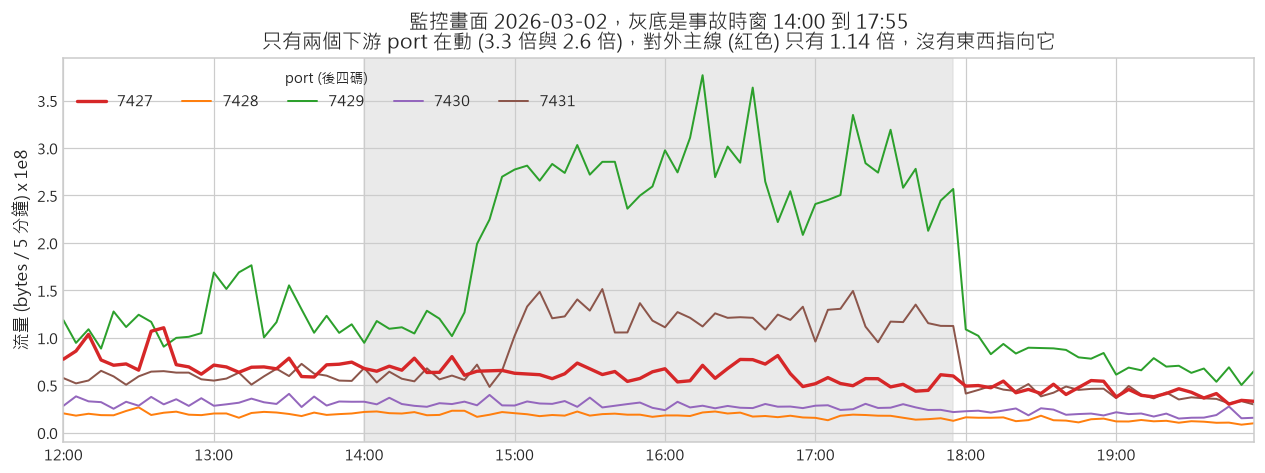


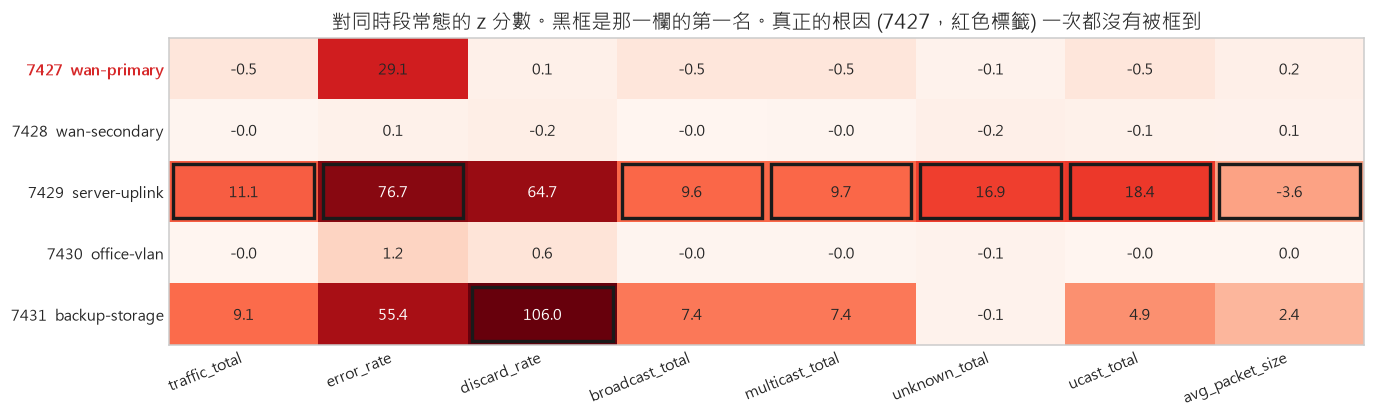

,照幅度排候選的規則 (事故 L，基線 seasonal，簽章指標 error_rate),第一名,對不對
0,逐 metric 取第一名 (八次投票的多數),7429,不是根因
1,每個 port 最大的 |z|,7431,不是根因
2,每個 port 平均的 |z|,7429,不是根因


In [4]:
# 🎯 監控畫面上只有流量，先看; 再把「動得多不多」量成 z 分數，照幅度排一次候選。

# ============ ⚙️ 可調參數 ============
PRE_WIN = "2h"          # 事故前後各多看多久。它同時決定折線圖畫多寬，以及 peak_ratio 的
                        # 比較基準取哪一段。調小: 分母只剩幾格，多一個尖峰就換一個答案;
                        # 調大: 會蓋到開盤前後，那一段的水準本來就跟中午不一樣
BASELINE_DAYS = 7       # 同時段基線最多往回堆幾個同類日子 (交易日對交易日)
MIN_BASELINE_DAYS = 3   # 至少要湊到幾天才敢用同時段基線，湊不到就退回「事故前 PRE_WIN」
                        # 標準差要有三個以上的觀測才不會完全由一兩天決定
SHORTLIST_N = 2         # 幅度這一欄算完之後，候選看板上還留幾個候選
# ====================================
lo = INCIDENT.start_time - pd.Timedelta(PRE_WIN)
hi = INCIDENT.end_time + pd.Timedelta(PRE_WIN)
pre0 = INCIDENT.start_time - pd.Timedelta(PRE_WIN)
pre1 = INCIDENT.start_time - pd.Timedelta("5min")     # 扣一格，事故開始那一格不進分母
PORT_DEVICE = features.groupby("port_id").device_id.first().to_dict()
PORT_ROLE = features.groupby("port_id").port_role.first().to_dict()


# ---- 1. 監控畫面: 五個 port 的流量 ----
#         強調色只留給根因，其餘四條走非紅的色盤 (matplotlib 預設色循環的第四個就是紅色)。
def peak_ratio(port, metric):
    """事故窗內的峰值除以事故前 PRE_WIN 的中位數。回傳的是倍數，分母是 0 就回 NaN。"""
    w = feat_by_port[port].loc[INCIDENT.start_time:INCIDENT.end_time][metric]
    b = float(feat_by_port[port].loc[pre0:pre1][metric].median())
    return float(w.max()) / b if b > 0 else np.nan


OTHER = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:brown"]
LINE_COLOR = {p: ("tab:red" if p == INCIDENT.port_id else OTHER[i % len(OTHER)])
              for i, p in enumerate(ALL_PORTS)}
fig, ax = plt.subplots(figsize=(11.6, 4.4), dpi=110)
for p in ALL_PORTS:
    s = feat_by_port[p].loc[lo:hi]["traffic_total"]
    root = p == INCIDENT.port_id
    ax.plot(s.index, s.values / 1e8, lw=2.2 if root else 1.3,
            color=LINE_COLOR[p], zorder=3 if root else 2, label=p[-4:])
ax.axvspan(INCIDENT.start_time, INCIDENT.end_time, color="0.85", alpha=0.55, zorder=0)
ax.set_xlim(lo, hi)
ax.set_ylabel("流量 (bytes / 5 分鐘) x 1e8", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.tick_params(labelsize=9.5)
r29, r31, r27 = (peak_ratio("port-id7429", "traffic_total"),
                 peak_ratio("port-id7431", "traffic_total"),
                 peak_ratio("port-id7427", "traffic_total"))
ax.legend(fontsize=9.5, ncol=5, loc="upper left", title="port (後四碼)", title_fontsize=9)
ax.set_title(f"監控畫面 {INCIDENT.start_time:%Y-%m-%d}，灰底是事故時窗 "
             f"{INCIDENT.start_time:%H:%M} 到 {INCIDENT.end_time:%H:%M}\n"
             f"只有兩個下游 port 在動 ({r29:.1f} 倍與 {r31:.1f} 倍)，"
             f"對外主線 (紅色) 只有 {r27:.2f} 倍，沒有東西指向它", fontsize=13)
plt.tight_layout()
show_fig(fig)


# ---- 2. 基線: 這個 port 在這一段時間的常態長什麼樣 ----
#         首選同時段歷史: 往回找同一段時鐘時間、同一種日子的前幾天，逐格堆起來取平均與
#         標準差，落在排程視窗裡的格子先標成 NaN。湊不到天數就退回事故前 PRE_WIN。
#         注意: 這裡用的是平均與標準差，不是 Lab 06 的中位數與 MAD，所以它不是穩健統計量。
def scheduled_mask(index):
    """哪些取樣點落在已發布的排程視窗裡。回傳一串等長的 True / False。"""
    m = np.zeros(len(index), dtype=bool)
    for a, b in zip(SCHEDULED.start_time, SCHEDULED.end_time):
        m |= (index >= a) & (index <= b)
    return m


_baseline_cache = {}      # 基線要算很多次 (每個 port x 每個事故)，所以做快取


def baseline_stats(port, t0, t1, pre=PRE_WIN):
    """事件窗每一格的常態值 mu 與散布 sd，回傳 (mu, sd, mode)。

    mu 是逐格的 (每個時刻有自己的常態值)，sd 不是逐格的 (整段窗共用一個散布)。
    mode 是 "seasonal" 或 "pre-window"，說明這一次走的是哪一條路。
    已知限制: 這裡只剔掉已發布的排程視窗，沒有剔掉過去的 catalog 事件，所以往回找
    同時段基線時會撈到前一晚同形狀的事件，基線被墊高、那個事故的 z 被壓下去。"""
    ck = (port, t0, t1, pre)
    if ck in _baseline_cache:
        return _baseline_cache[ck]
    g = feat_by_port[port]
    cur = g.loc[t0:t1]
    same_kind, stack, back = t0.date() in TRADING_DAYS, [], 1
    while len(cur) and len(stack) < BASELINE_DAYS and back <= 21:
        a, b = t0 - pd.Timedelta(days=back), t1 - pd.Timedelta(days=back)
        if a < g.index[0]:
            break
        if (a.date() in TRADING_DAYS) == same_kind:
            w = g.loc[a:b]
            if len(w) == len(cur):        # 取樣格數不一樣的那一天 (缺資料) 疊不起來
                arr = w[METRICS].to_numpy(float).copy()
                arr[scheduled_mask(w.index)] = np.nan
                stack.append(arr)
        back += 1
    if len(stack) >= MIN_BASELINE_DAYS:
        S = np.stack(stack)               # 形狀是 (天數, 每天的取樣格數, metric 數)
        mu = pd.DataFrame(np.nanmean(S, axis=0), index=cur.index, columns=METRICS)
        # 先對「天」取標準差得到每一格自己的散布，再把各格的變異數平均起來開根號。
        sd = pd.Series(np.sqrt(np.nanmean(np.nanstd(S, axis=0, ddof=1) ** 2, axis=0)), index=METRICS)
        out = (mu, sd, "seasonal")
    else:
        pre_w = g.loc[t0 - pd.Timedelta(pre): t0 - pd.Timedelta("5min")]
        mu = pd.DataFrame(np.tile(pre_w[METRICS].mean().to_numpy(), (max(len(cur), 1), 1)),
                          index=cur.index, columns=METRICS)
        out = (mu, pre_w[METRICS].std(), "pre-window")
    _baseline_cache[ck] = out
    return out


# ---- 3. z 分數: 對自己的常態偏離了幾個標準差 ----
#         z = (事故期的平均偏離) / 基線的合併標準差，所以它讀作「偏離這個 port 自己的常態
#         幾個標準差」。每個 port 都拿自己的歷史當分母，流量差好幾個數量級也比得起來。
def window_zscores(t0, t1, pre=PRE_WIN):
    """對一個事故窗，逐 (port, metric) 算 z。回傳一張表: 列是 port，欄是 metric。

    z 量到的只有「動得多不多」: 它的計算裡沒有用到任何位置或時間的資訊。"""
    rows = []
    for p in ALL_PORTS:
        cur = feat_by_port[p].loc[t0:t1]
        if cur.empty:
            continue
        mu, sd, _ = baseline_stats(p, t0, t1, pre)
        rec = {"port_id": p}
        for m in METRICS:
            s = sd[m]
            dev = float(np.nanmean(cur[m].to_numpy(float) - mu[m].to_numpy(float)))
            # 分母太小 (這個 metric 的基線根本不動) 就記 0.0，不然會除出一個看起來像
            # 嚴重異常的大數字，其實只代表那一欄從來沒有變化過。
            rec[m] = float(dev / s) if np.isfinite(s) and s > 1e-9 and np.isfinite(dev) else 0.0
        rows.append(rec)
    return pd.DataFrame(rows).set_index("port_id")


def zmax_port(zcol, tol=1e-9):
    """這一欄 z 最大的 port。整欄沒有唯一的最大值時回 None，而不是回第一個 port。

    基線是平的時候整欄會全部變成 0，此時 idxmax() 會挑到名稱排最前面的那一個，
    那是字典序不是證據。"""
    v = pd.Series(zcol).dropna()
    if len(v) == 0 or float(np.ptp(v.to_numpy())) < tol \
            or int((v.to_numpy() >= v.max() - tol).sum()) > 1:
        return None
    return v.idxmax()


zmat = window_zscores(INCIDENT.start_time, INCIDENT.end_time)
_, _, zmat_mode = baseline_stats(INCIDENT.port_id, INCIDENT.start_time, INCIDENT.end_time)

# ---- 4. 熱圖: 每一欄的第一名框起來，看它會不會落在根因那一列 ----
#         底色取 log10(|z|+1)，因為 z 的範圍橫跨好幾個數量級，直接上色的話除了最大的
#         那一格全部都是白的。取絕對值是因為往下掉也是異常。
Z = zmat.reindex(ALL_PORTS)[METRICS]
V = np.abs(Z.to_numpy(float))
fig, ax = plt.subplots(figsize=(12.6, 3.9), dpi=110)
ax.imshow(np.log10(V + 1), cmap="Reds", aspect="auto", vmin=0)
ax.grid(False)
for i, p in enumerate(ALL_PORTS):
    for j, m in enumerate(METRICS):
        v = float(Z.iloc[i, j])
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=10,
                color="white" if abs(v) > 40 else "0.15")
for j, m in enumerate(METRICS):                      # 每一欄的第一名框起來
    top = zmax_port(Z[m].abs())
    if top is not None:
        ax.add_patch(plt.Rectangle((j - 0.47, ALL_PORTS.index(top) - 0.44), 0.94, 0.88,
                                   fill=False, edgecolor="0.1", lw=2.2))
ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels(METRICS, rotation=22, ha="right", fontsize=9.5)
ax.set_yticks(range(len(ALL_PORTS)))
ax.set_yticklabels([f"{p[-4:]}  {PORT_ROLE[p]}" for p in ALL_PORTS], fontsize=10)
for tick, p in zip(ax.get_yticklabels(), ALL_PORTS):   # 真正的根因那一列標成紅色粗體
    if p == INCIDENT.port_id:
        tick.set_color("tab:red"); tick.set_fontweight("bold")
ax.set_title(f"對同時段常態的 z 分數。黑框是那一欄的第一名。"
             f"真正的根因 ({INCIDENT.port_id[-4:]}，紅色標籤) 一次都沒有被框到", fontsize=13)
plt.tight_layout()
show_fig(fig)

# ---- 5. 三種用幅度排候選的規則，看第一名分別是誰 ----
#         三種都是「照動得多不多排」，只是彙總的方式不同。標準答案只用在這裡驗證，
#         排名程式本身看不到它。
per_metric = [zmax_port(Z[m].abs()) for m in METRICS]
rule_top = {
    "逐 metric 取第一名 (八次投票的多數)": max(set(per_metric), key=per_metric.count),
    "每個 port 最大的 |z|": zmax_port(pd.Series(V.max(axis=1), index=ALL_PORTS)),
    "每個 port 平均的 |z|": zmax_port(pd.Series(V.mean(axis=1), index=ALL_PORTS)),
}
display(pd.DataFrame(
    [(name, (top[-4:] if top else "沒有唯一最大值"),
      "命中" if top == INCIDENT.port_id else "不是根因")
     for name, top in rule_top.items()],
    columns=[f"照幅度排候選的規則 (事故 {INCIDENT.event_id}，基線 {zmat_mode}，"
             f"簽章指標 {SIGNATURE})", "第一名", "對不對"]))


# ---- 6. 候選看板: 每一節算完一種證據就往右加一欄，並重畫一次 ----
#         它是這一章的記分板，讓人一眼看出「這一節刪掉了誰、留下了誰」。
BOARD = []


def add_board_column(title, cell_text, supports, shortlist):
    """往看板右邊加一欄。supports 為 True 的格子上色，代表這一欄指向那個候選。"""
    BOARD.append(dict(title=title, cell=cell_text, sup=supports, short=shortlist))


def draw_board(caption):
    """把目前 BOARD 裡的每一欄畫成一張表。最新加的那一欄用紅色，之前的用灰色。

    這是用一個一個矩形手工排出來的表格，所以最後會把外框、格線與刻度線全部關掉。"""
    n = len(BOARD)
    nrow = len(ALL_PORTS)
    fig, ax = plt.subplots(figsize=(2.3 + 2.45 * n, 4.2), dpi=110)
    for j, col in enumerate(BOARD):
        new = (j == n - 1)                 # 是不是最新加進來的那一欄
        for i, p in enumerate(ALL_PORTS):
            y = nrow - 1 - i               # matplotlib 的 y 往上變大，表格要第一列在最上面
            sup = bool(col["sup"].get(p, False))
            # 四種底色: 新欄支持 (紅)、舊欄支持 (深灰)、新欄不支持 (淺灰)、舊欄不支持 (更淺)。
            face = ("tab:red" if new else "0.55") if sup else ("0.90" if new else "0.95")
            ax.add_patch(plt.Rectangle((j + 0.03, y + 0.08), 0.94, 0.84,
                                       facecolor=face, edgecolor="white", lw=1.6))
            ax.text(j + 0.5, y + 0.5, col["cell"].get(p, ""), ha="center", va="center",
                    fontsize=9.5, color="white" if sup else "0.3", linespacing=1.35)
        ax.text(j + 0.5, nrow + 0.30, col["title"], ha="center", fontsize=10.5,
                color="tab:red" if new else "0.5", fontweight="bold" if new else "normal")
        ax.add_patch(plt.Rectangle((j + 0.03, -1.10), 0.94, 0.84, facecolor="white",
                                   edgecolor="tab:red" if new else "0.75", lw=1.6))
        ax.text(j + 0.5, -0.68, col["short"], ha="center", va="center", fontsize=9.5,
                color="tab:red" if new else "0.45")
    ax.set_xlim(0, n)
    ax.set_ylim(-1.35, nrow + 0.75)
    ax.set_xticks([])
    ax.set_yticks([nrow - 1 - i + 0.5 for i in range(nrow)] + [-0.68])
    ax.set_yticklabels([f"{p[-4:]}  {PORT_ROLE[p]}" for p in ALL_PORTS] + ["這一欄指向的候選"],
                       fontsize=10)
    for tick, p in zip(ax.get_yticklabels(), ALL_PORTS):
        if p == INCIDENT.port_id:
            tick.set_color("tab:red"); tick.set_fontweight("bold")
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    ax.set_title(caption, fontsize=12)
    plt.tight_layout()
    show_fig(fig)


# 看板的第一欄: 每個 port 在簽章指標上的 z，留下前 SHORTLIST_N 名。
# 這一欄留下的是 7429 與 7431，真正的根因在這一欄排第三，所以留幾個都一樣把它排除在外。
# 這正是這一節要示範的事: 問題不在留幾個，在於「幅度」這一條軸本身指不到根因。
_zsig = zmat[SIGNATURE].reindex(ALL_PORTS)
_top2 = list(_zsig.abs().sort_values(ascending=False).index[:SHORTLIST_N])
add_board_column(
    "magnitude  |z|",
    {p: f"{_zsig[p]:+.1f}" for p in ALL_PORTS},
    {p: p in _top2 for p in ALL_PORTS},
    ", ".join(q[-4:] for q in _top2),
)


### 需要更多的關聯分析！
- 熱圖下面那張表是三種用幅度排候選的規則: 逐 metric 取第一名、取每個 port 最大的 |z|、取每個 port 的平均 |z|。**三種的第一名都落在下游那兩個 port，沒有一種指到根因。**
- 不是排法挑錯了，是幅度這條軸本身指不到: 上游輕微劣化，下游因為重傳與佇列堆積而放大，所以下游的症狀本來就比上游的原因劇烈。**告警系統看到的是放大之後的結果，不是觸發點。**
- 要繼續查下去，只剩三種跟幅度無關的資訊: **位置、時間、統計關係**。下一節一次算一種，每算完一種就把候選看板重畫一次，看它刪掉了哪一個候選、或刪掉了哪一種解釋。


---

## 幅度以外的四種證據: 位置、關聯、時序、可預測性

```mermaid
flowchart LR
    M1["照直覺查一遍<br/>用幅度排"] --> M2["四種證據<br/>位置、關聯<br/>時序、可預測性"] --> M3["合成一個排名<br/>Score(c)"] --> M4["LLM 架構<br/>打包 context<br/>檢索領域知識"] --> M5["LLM 診斷<br/>與驗證"] --> M6["換產業、換檢索<br/>回饋迴路與上線"]
    style M2 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

```mermaid
flowchart LR
    G1["位置<br/>拓樸可達範圍"] --> G2["統計關聯<br/>有沒有一起動"] --> G3["時序<br/>誰先動"] --> G4["可預測性<br/>加上它的過去<br/>預測得動嗎"]
    style G1 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```


---

## 位置: 誰的下游蓋得到這些症狀

Correlation 告訴你哪些元件一起變化，Topology 告訴你哪些元件真的可能互相影響:

拓樸項 $G(c)$ 量的就是後者，符號直接沿用講義右下角那一格:

$$
G(c)=\frac{|\,D(c) \cap A\,|}{|\,A\,|}
$$

- $c$ 是候選根因元件，這一章以 port 為單位
- $D(c)$ 是 $c$ 的下游可達集合。依拓樸只往下游走，不含它自己
- $A$ 是本次的異常集合，由 z 分數挑出來
- $|\cdot|$ 是集合大小

分子只數「下游而且異常」的 port，**不要求候選自己也異常**,否則它就退化成幅度項的複本，兩項會量到同一件事。

**$A$ 怎麼來的要講明白。** 講義那一格寫「$A$: 本次異常集合 (由 Z-score 得到) 」,這一章就是照它做的: $A$ 是**簽章指標的 $|z| > 3$** 挑出來的那幾個 port,門檻寫在下一格的 `ANOM_Z`,全章對「異常」只用這一個定義。

**為什麼不用相關係數挑 $A$。** 關聯那一節會量出來: 這一次的機制隔了 40 分鐘，相關係數比的是同一格的擺動，用它挑異常集合會挑錯人。**挑法一定要寫進 provenance**,否則同一個 $G(c)$ 在兩份報告上會是不同的東西。

<p align="center"><img src="slides/u08_topology.png" width="80%" alt="單元 08 的拓樸與依賴圖投影片: 拓樸限制異常傳播路徑; Correlation 告訴我們哪些元件一起變化，Topology 告訴我們哪些元件真的可能互相影響，兩者結合才能有效縮小搜尋空間; 右下角把拓樸可達範圍量化成 G(c) = |D(c) ∩ A| / |A|，並列出符號: c 是候選根因元件、D(c) 是 c 的下游可達集合、|·| 是集合大小，以及 A 是本次異常集合 (由 Z-score 得到)"></p>


,role,下游可達,其中 |z| > 3 的 (error_rate),G(c)
port,,,,
7427,wan-primary,7429、7430、7431,7429、7431,0.67
7428,wan-secondary,(空),(空),0.00
7429,server-uplink,(空),(空),0.00
7430,office-vlan,(空),(空),0.00
7431,backup-storage,(空),(空),0.00



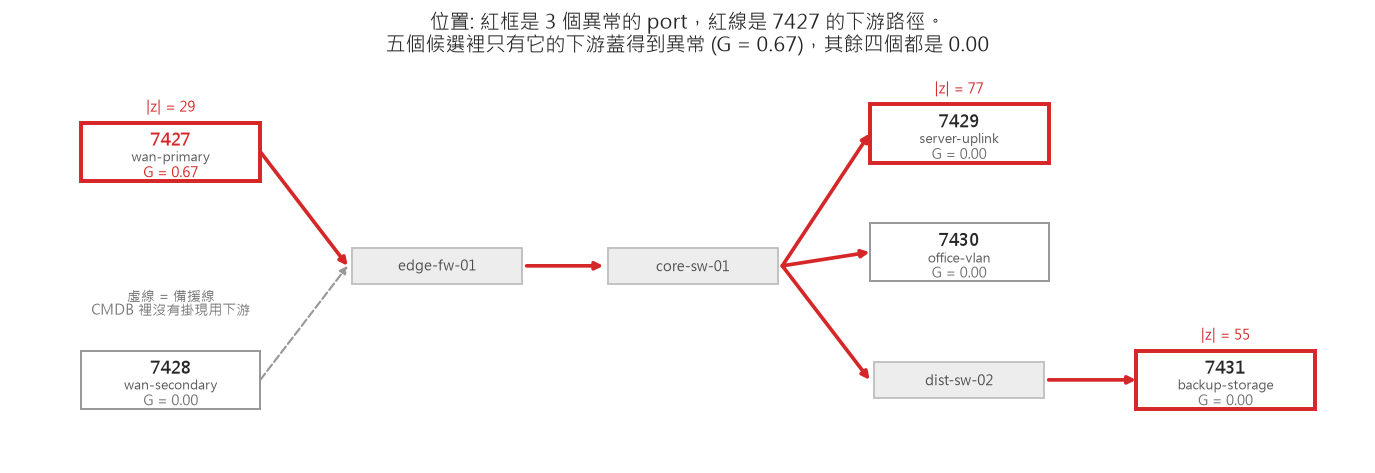


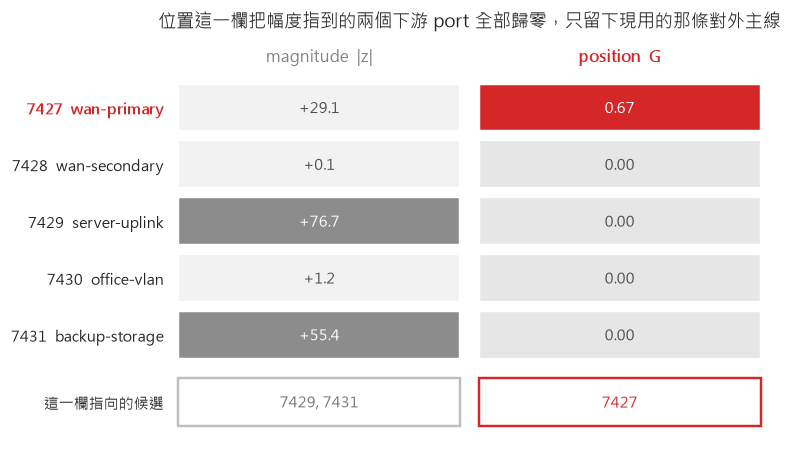

In [5]:
# 🎯 拓樸項 G(c): 候選的下游可達範圍裡有多少異常 port。跟它自己有多嚴重無關。

# ============ ⚙️ 可調參數 ============
# PORT_DOWNSTREAM: port 層的依賴表 (冒號右邊是掛在它下面的直接下游)。這是領域知識不是
#   從資料學出來的，正式環境要接 CMDB。節點取設備的話，同一台設備底下的兩個 port 在圖上
#   會是同一個點，G(c) 永遠同分，所以節點必須跟排名的對象一樣細。
PORT_DOWNSTREAM = {
    "port-id7427": ["port-id7429", "port-id7430", "port-id7431"],   # wan-primary，現用路徑
    "port-id7428": [],                                              # wan-secondary，備援
    "port-id7429": [], "port-id7430": [], "port-id7431": [],
}
ANOM_Z = 3      # 簽章指標的 |z| 超過多少才進異常集合 A (也就是 G(c) 的分母)。
                # 調小 (2): 只是輕微擺動的 port 也會進 A，分母變大而分子不變，五個候選的
                #   G(c) 一起被壓低，這一欄就分不出上下游;
                # 調大 (5): A 只剩一兩個 port，G(c) 只會是 0 或 1，中間沒有刻度可以排序。
                # 選 3 的理由: 跟 Lab 06 的管制界限同一個門檻。
# ====================================


# ---- 1. 「下游可達」不只是直接相連的那幾個，是沿著箭頭一直走下去能碰到的全部 ----
#         networkx 的 descendants 就在做這件事; 沒裝就自己用堆疊走一次同一張表。
if HAS_NX:
    G_topo = nx.DiGraph(); G_topo.add_nodes_from(PORT_DOWNSTREAM)
    for p, downs in PORT_DOWNSTREAM.items():
        for dn in downs:
            G_topo.add_edge(p, dn)
    downstream_ports = lambda p: set(nx.descendants(G_topo, p))
else:
    def downstream_ports(p):
        seen, stack = set(), list(PORT_DOWNSTREAM.get(p, []))
        while stack:
            dd = stack.pop()
            if dd not in seen:
                seen.add(dd); stack += PORT_DOWNSTREAM.get(dd, [])
        return seen


# ---- 2. 算 G(c) = |c 的下游可達 ∩ 異常集合| / |異常集合| ----
#         讀作「這次的異常，有幾成落在這個候選的下游」，一定落在 0 到 1 之間。
#         分子只數「下游而且異常」的，不要求候選自己也異常: 要求的話它就退化成幅度項的
#         複本，兩項會量到同一件事，等權相加等於把幅度算了兩次。
anomalous_inc = [p for p in ALL_PORTS if abs(zmat.loc[p, SIGNATURE]) > ANOM_Z]
G_inc, reach_inc = {}, {}
for p in ALL_PORTS:
    downs = downstream_ports(p)
    reach_inc[p] = [q for q in anomalous_inc if q in downs]
    G_inc[p] = float(np.clip(len(reach_inc[p]) / max(len(anomalous_inc), 1), 0, 1))

# 空的時候印「(空)」而不是留白: 空白格會讓人以為是程式漏算。
display(pd.DataFrame(
    [(p[-4:], PORT_ROLE[p],
      "、".join(sorted(q[-4:] for q in downstream_ports(p))) or "(空)",
      "、".join(q[-4:] for q in reach_inc[p]) or "(空)",
      round(G_inc[p], 2)) for p in ALL_PORTS],
    columns=["port", "role", "下游可達",
             f"其中 |z| > {ANOM_Z} 的 ({SIGNATURE})", "G(c)"]).set_index("port"))

# ---- 3. 畫依賴圖: 誰異常、誰的下游蓋得到那些異常 ----
#         POS 與 EDGES 是排版用的，不是算出來的: 位置手排，箭頭才不會互相交叉。
POS = {"port-id7427": (0.0, 3.05), "port-id7428": (0.0, 0.55),
       "edge-fw-01": (1.25, 1.80), "core-sw-01": (2.45, 1.80),
       "port-id7429": (3.70, 3.25), "port-id7430": (3.70, 1.95),
       "dist-sw-02": (3.70, 0.55), "port-id7431": (4.95, 0.55)}
EDGES = [("port-id7427", "edge-fw-01", "live"), ("port-id7428", "edge-fw-01", "standby"),
         ("edge-fw-01", "core-sw-01", "live"), ("core-sw-01", "port-id7429", "live"),
         ("core-sw-01", "port-id7430", "live"), ("core-sw-01", "dist-sw-02", "live"),
         ("dist-sw-02", "port-id7431", "live")]
CAND = INCIDENT.port_id
reach_all = downstream_ports(CAND)

fig, ax = plt.subplots(figsize=(12.6, 4.4), dpi=110)
for a, b, kind in EDGES:                 # 這次候選的現用下游路徑畫紅色粗線，其餘灰色細線
    (x0, y0), (x1, y1) = POS[a], POS[b]
    on_path = kind == "live" and a != "port-id7428"
    ax.annotate("", xy=(x1 - 0.42, y1), xytext=(x0 + 0.42, y0),
                arrowprops=dict(arrowstyle="-|>", lw=2.4 if on_path else 1.4,
                                color="tab:red" if on_path else "0.6",
                                linestyle="-" if kind == "live" else "--",
                                shrinkA=0, shrinkB=0))
for name, (x, y) in POS.items():         # port 畫大方塊 (三行字)，設備畫灰色小方塊
    is_port = name.startswith("port-id")
    if is_port:
        anom = name in anomalous_inc
        ax.add_patch(plt.Rectangle((x - 0.42, y - 0.32), 0.84, 0.64, facecolor="white",
                                   edgecolor="tab:red" if anom else "0.6",
                                   lw=2.6 if anom else 1.3, zorder=3))
        ax.text(x, y + 0.14, name[-4:], ha="center", va="center", fontsize=11,
                fontweight="bold", zorder=4,
                color="tab:red" if name == CAND else "0.15")
        ax.text(x, y - 0.06, PORT_ROLE[name], ha="center", va="center", fontsize=8.2,
                color="0.35", zorder=4)
        ax.text(x, y - 0.22, f"G = {G_inc[name]:.2f}", ha="center", va="center", fontsize=9,
                color="tab:red" if G_inc[name] > 0 else "0.45", zorder=4)
        if anom:
            ax.text(x, y + 0.44, f"|z| = {abs(zmat.loc[name, SIGNATURE]):.0f}", ha="center",
                    fontsize=9, color="tab:red")
    else:
        ax.add_patch(plt.Rectangle((x - 0.40, y - 0.20), 0.80, 0.40, facecolor="0.93",
                                   edgecolor="0.75", lw=1.2, zorder=3))
        ax.text(x, y, name, ha="center", va="center", fontsize=9, color="0.3", zorder=4)
ax.text(0.0, 1.55, "虛線 = 備援線\nCMDB 裡沒有掛現用下游",
        ha="center", va="top", fontsize=9, color="0.45")
ax.set_xlim(-0.75, 5.6); ax.set_ylim(-0.35, 4.05)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title(f"位置: 紅框是 {len(anomalous_inc)} 個異常的 port，紅線是 {CAND[-4:]} 的下游路徑。\n"
             f"五個候選裡只有它的下游蓋得到異常 (G = {G_inc[CAND]:.2f})，其餘四個都是 0.00",
             fontsize=13)
plt.tight_layout()
show_fig(fig)

# ---- 4. 記上候選看板: 上色的條件是 G(c) > 0，也就是「下游蓋得到這次異常」的那幾個 ----
add_board_column(
    "position  G",
    {p: f"{G_inc[p]:.2f}" for p in ALL_PORTS},
    {p: G_inc[p] > 0 for p in ALL_PORTS},
    ", ".join(q[-4:] for q in ALL_PORTS if G_inc[q] > 0) or "none",
)
draw_board("位置這一欄把幅度指到的兩個下游 port 全部歸零，只留下現用的那條對外主線")


---

## 關聯: 一起動的是哪兩個 port

```mermaid
flowchart LR
    G1["位置<br/>拓樸可達範圍"] --> G2["統計關聯<br/>有沒有一起動"] --> G3["時序<br/>誰先動"] --> G4["可預測性<br/>加上它的過去<br/>預測得動嗎"]
    style G2 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

#### 統計關聯為什麼使用 **Pearson 相關係數**:

- **要看的是「一起上一起下」,那是線性問得動的問題。** 這一節問的是兩個 port 的變化量有沒有同步，不是它們之間有沒有某種彎曲的函數關係
- **事故窗只有 48 個取樣點。** 講義在 mutual information 底下標了「估計需足夠資料」,而 48 格對最近鄰估計器來說偏少; Pearson 沒有估計器要餵，只有一個公式
- **要看得到方向。** 講義在 mutual information 底下標的另一個限制是「數值大小無方向資訊」,可是同一份資料裡的事故 R 是流量往下掉，反向傳播只有帶正負號的相關讀得到。Pearson 的「尺度有意義」也是講義自己列的優點: 0.8 是高、0.1 是低，不必再套一層換算
- **代價:** 對離群值敏感、只看得到線性關係、而且高相關不代表因果。這也是為什麼這個關聯這一項在排名裡只佔 $C(c)$ 的一部分，不是自己決定第一名。真的碰到非線性耦合時，這一項換成 mutual information，所以是依照資料做決定。

#### 計算時要注意的點!

- **只量事故發生的那 235 分鐘，不去算沒有事故的日子長什麼樣。** : 事故正在發生的時候，誰跟誰一起動才是重點。
- **量在哪一條序列上**: 這個事故的簽章指標是 `error_rate`,但 `port-id7428` 有 96%、`port-id7430` 有 79% 的取樣點是 0。整數錯誤計數在這兩個 port 上只出現過 0、1、2,非零那幾格之間的高低差來自分母的封包數在變,所以剩下的變化幾乎全是量測解析度。這樣的序列算得出相關係數，卻讀不出意義: 用 `error_rate` 算，7428 對 7431 是 r = -0.44,而那個數字由那兩格計數器決定; 改算 `traffic_total`,同一對是 -0.13。下一格把這個檢查跑成一張圖，再決定這一節要量哪一條
- **相關要算在變化量上，不是算在原始的線上**: 兩條都在爬的線本來就會高度相關，那是趨勢不是關係。所以送進去之前先做一階差分，也就是每一格減掉前一格。下一格的第二張圖就拿事故窗裡真的一起被放大的那兩個 port 跑一次，把原始序列與差分之後的 r 各算一遍

<p align="center"><img src="slides/u08_association.png" width="80%" alt="單元 08 的統計相關分析投影片: Pearson、Spearman、偏相關與 mutual information 四種關聯度量的適用情境與限制，底下是從線性到一般依賴關係的關係型態光譜"></p>


,事故窗 48 格裡的相異值比例,沒過 50% 門檻的 port,結論
候選序列,,,
error_rate,7427 100%、7428 6%、7429 96%、7430 23%、7431 88%,7428、7430,不用
traffic_total,7427 100%、7428 100%、7429 100%、7430 100%、7431 100%,沒有,這一節用它



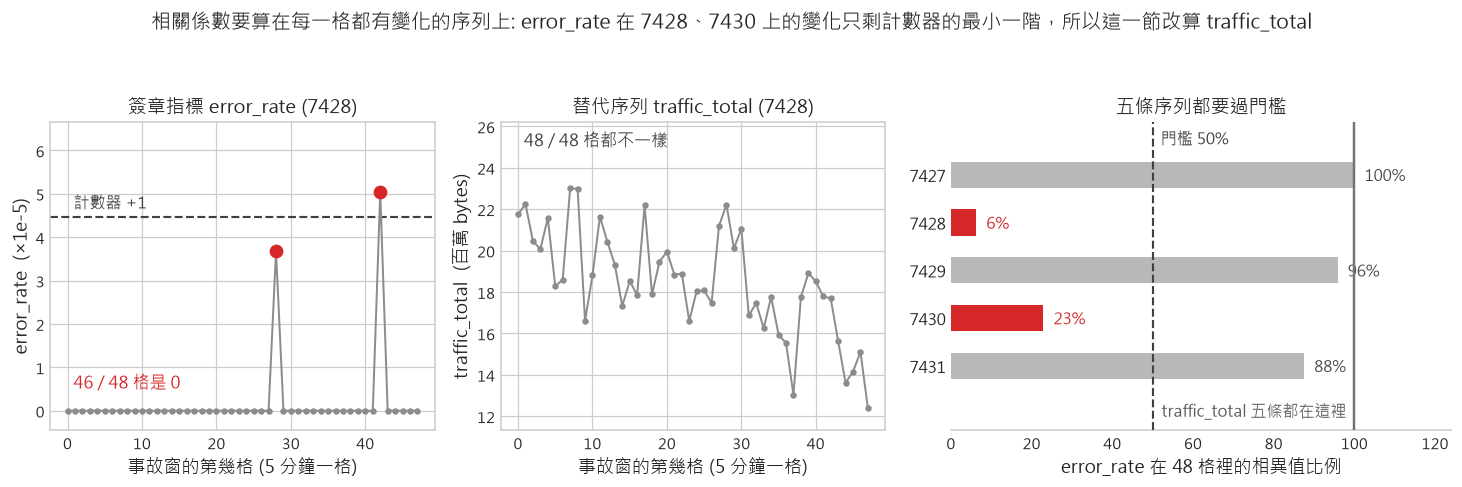


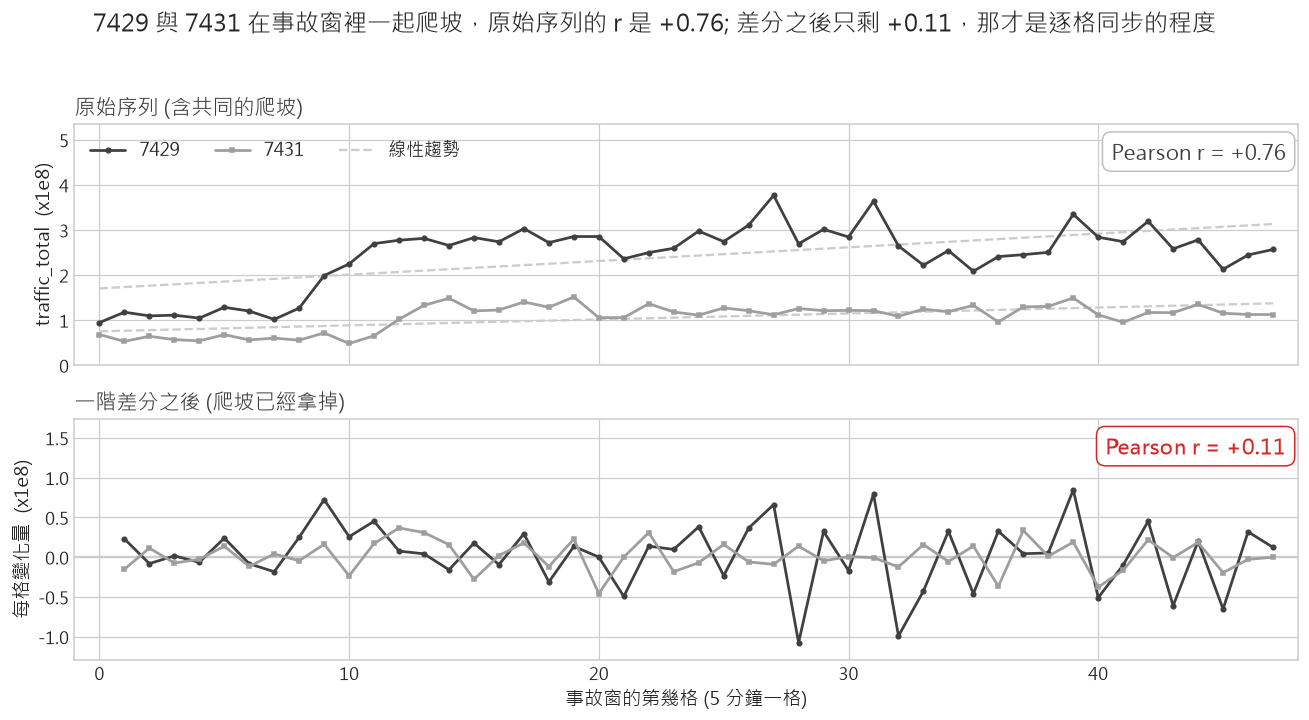

In [6]:
# 🎯 這一格做兩件事: 先決定相關係數要算在哪一個 metric 上，再說明為什麼要先做一階差分。
#    簽章指標是這次事故的主軸，所以先看它; 它在某些 port 上量不出高低的時候才換一條。
#    底下那一格才真的去算五個 port 兩兩的相關。

# ============ ⚙️ 可調參數 ============
MIN_DISTINCT_RATIO = 0.5   # 一條序列在事故窗裡的相異值要佔到幾成，才拿去算相關係數。
                           # 調小 (0.1): 7430 的 23% 也算過關，只剩 7428 出局;
                           # 調大 (1.0): 只留每一格都不重複的序列，這份資料裡只有 traffic_total
CANDIDATES = [SIGNATURE, "traffic_total"]   # 依序檢查，第一個五個 port 全過的就是要用的那一條
RESOLUTION_DEMO = "port-id7428"             # 左邊兩張圖畫哪一個 port 的兩條候選序列
PICK_WINDOW = (INCIDENT.start_time, INCIDENT.end_time)   # 跟底下那一格量同一段時間
DIFF_DEMO_PAIR = ("port-id7429", "port-id7431")   # 第 4 塊那張一階差分的圖拿哪兩個 port
                           # 示範。挑它們的理由: 事故窗裡就這兩個 port 被放大，而且五個
                           # port 十對裡它們原始序列的 r 最高，最看得出差分前後差多少
# ====================================


# ---- 1. 一條序列在事故窗裡有幾個不同的值 ----
#         error_rate 是「整數錯誤計數 / 封包數」，所以它只能落在 0、1/N、2/N 這幾個位置上。
#         相異值一少，代表這條線量到的是計數器有沒有加一，不是現象本身的高低。這種序列算得
#         出相關係數 (不會回 None) ，可是那個數字由那一格計數器決定。
def distinct_ratio(port, metric, t0, t1):
    s = feat_by_port[port].loc[t0:t1][metric].to_numpy(float)
    return len(np.unique(s)) / len(s)


def screen(metric, t0, t1, ports=None):
    """回傳每個 port 的相異值比例，以及沒過門檻的那幾個。

    Pearson 是兩兩比對，所以標準是「每一條都要過」而不是「平均有過就好」: 五個 port
    有十對，只要有一條沒過，牽涉到它的那幾對就都不能用。"""
    ports = list(ports) if ports else ALL_PORTS
    ratio = {p: distinct_ratio(p, metric, t0, t1) for p in ports}
    return ratio, [p for p in ports if ratio[p] < MIN_DISTINCT_RATIO]


# ---- 2. 依序檢查候選，挑第一個全過的 ----
WIN_N = len(feat_by_port[ALL_PORTS[0]].loc[PICK_WINDOW[0]:PICK_WINDOW[1]])
RATIO, FAIL = {}, {}
for _m in CANDIDATES:
    RATIO[_m], FAIL[_m] = screen(_m, *PICK_WINDOW)
PICKED = next((m for m in CANDIDATES if not FAIL[m]), None)
if PICKED is None:
    raise ValueError(f"候選 {CANDIDATES} 每一條都有 port 沒過 {MIN_DISTINCT_RATIO:.0%} 門檻，"
                     f"請在 CANDIDATES 補一個量得動的 metric，或說明為什麼這一節不算相關。")

display(pd.DataFrame(
    [(m, "、".join(f"{p[-4:]} {RATIO[m][p]:.0%}" for p in ALL_PORTS),
      "、".join(p[-4:] for p in FAIL[m]) or "沒有",
      "這一節用它" if m == PICKED else "不用")
     for m in CANDIDATES],
    columns=["候選序列", f"事故窗 {WIN_N} 格裡的相異值比例",
             f"沒過 {MIN_DISTINCT_RATIO:.0%} 門檻的 port", "結論"]).set_index("候選序列"))

# ---- 3. 選序列的結果畫出來: 左兩張是同一個 port 的兩條候選序列，右邊是五個 port 一起看 ----
_w  = feat_by_port[RESOLUTION_DEMO].loc[PICK_WINDOW[0]:PICK_WINDOW[1]]
_x  = np.arange(len(_w))
_er = _w[SIGNATURE].to_numpy(float) * 1e5
_tt = _w[PICKED].to_numpy(float) / 1e6
# 計數器 +1 對應的高度 = 1 個錯誤封包 / 這個窗的封包數中位數。兩格非零就落在這條線附近。
floor_med = float(1e5 / np.median(_w["ucast_total"].to_numpy(float)))

fig, axes = plt.subplots(1, 3, figsize=(13.4, 4.4), dpi=110,
                         gridspec_kw={"width_ratios": [1, 1, 1.3]})

# 左: 簽章指標在這個 port 上只有兩格離開 0，而那兩格就是計數器的最小一階。
ax = axes[0]
ytop = max(_er.max(), floor_med) * 1.32
ax.axhline(floor_med, ls="--", lw=1.4, color=INK, zorder=2)
ax.plot(_x, _er, color=GREY, lw=1.3, zorder=3)
_nz = _er > 0
ax.plot(_x[~_nz], _er[~_nz], "o", ms=3.2, color=GREY, zorder=4)
ax.plot(_x[_nz],  _er[_nz],  "o", ms=8,   color=ACC,  zorder=5)
ax.text(0.8, floor_med + ytop * 0.025, "計數器 +1", ha="left", va="bottom",
        fontsize=10.5, color=INK)
ax.text(0.8, ytop * 0.07, f"{int((~_nz).sum())} / {len(_x)} 格是 0", ha="left",
        va="bottom", fontsize=11, color=ACC)
ax.set_ylim(-0.45, ytop)
ax.set_xlabel("事故窗的第幾格 (5 分鐘一格)", fontsize=11.5)
ax.set_ylabel(f"{SIGNATURE}  (×1e-5)", fontsize=11.5)
ax.set_title(f"簽章指標 {SIGNATURE} ({RESOLUTION_DEMO[-4:]})", fontsize=12.5)

# 中: 同一個 port、同一段時間，換成 PICKED 這一條就每一格都在動。
ax = axes[1]
_lo, _hi = _tt.min(), _tt.max()
ax.plot(_x, _tt, color=GREY, lw=1.3, marker="o", ms=3.2, zorder=3)
ax.set_ylim(_lo - (_hi - _lo) * 0.10, _hi + (_hi - _lo) * 0.30)
ax.text(0.8, _hi + (_hi - _lo) * 0.22, f"{len(np.unique(_tt))} / {len(_x)} 格都不一樣",
        ha="left", va="center", fontsize=11, color=INK)
ax.set_xlabel("事故窗的第幾格 (5 分鐘一格)", fontsize=11.5)
ax.set_ylabel(f"{PICKED}  (百萬 bytes)", fontsize=11.5)
ax.set_title(f"替代序列 {PICKED} ({RESOLUTION_DEMO[-4:]})", fontsize=12.5)

# 右: 五個 port 一起看。上色的是沒過門檻的那幾條，也就是不能拿來算相關的那幾條。
ax = axes[2]
_yy = np.arange(len(ALL_PORTS))[::-1]
_vals = [RATIO[SIGNATURE][p] * 100 for p in ALL_PORTS]
ax.barh(_yy, _vals, height=0.55, zorder=3,
        color=[ACC if p in FAIL[SIGNATURE] else "0.72" for p in ALL_PORTS])
for _y, p, v in zip(_yy, ALL_PORTS, _vals):
    ax.text(v + 2.5, _y, f"{v:.0f}%", va="center", fontsize=10.5,
            color=ACC if p in FAIL[SIGNATURE] else "0.3")
ax.axvline(MIN_DISTINCT_RATIO * 100, ls="--", lw=1.4, color=INK, zorder=4)
ax.text(MIN_DISTINCT_RATIO * 100 + 2, len(ALL_PORTS) - 0.40,
        f"門檻 {MIN_DISTINCT_RATIO:.0%}", ha="left", va="bottom", fontsize=10.5, color=INK)
ax.axvline(100, lw=1.6, color="0.45", zorder=4)
ax.text(98, -0.95, f"{PICKED} 五條都在這裡", ha="right", va="center",
        fontsize=10.5, color="0.35")
ax.set_yticks(_yy)
ax.set_yticklabels([p[-4:] for p in ALL_PORTS], fontsize=10.5)
ax.set_xlim(0, 124)
ax.set_ylim(-1.35, len(ALL_PORTS) + 0.10)
ax.set_xlabel(f"{SIGNATURE} 在 {WIN_N} 格裡的相異值比例", fontsize=11.5)
ax.grid(False)
for _sp in ("top", "right", "left"):
    ax.spines[_sp].set_visible(False)
ax.set_title("五條序列都要過門檻", fontsize=12.5)

fig.suptitle("相關係數要算在每一格都有變化的序列上: "
             f"{SIGNATURE} 在 {'、'.join(p[-4:] for p in FAIL[SIGNATURE])} 上的變化"
             f"只剩計數器的最小一階，所以這一節改算 {PICKED}", fontsize=13, y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.93))
show_fig(fig)


# ---- 4. 為什麼相關要算在一階差分上，不是算在原始的線上 ----
#         兩條都在爬的線本來就會高度相關，那是趨勢不是關係。這一塊拿事故窗裡真的一起被
#         放大的那兩個 port 跑一次: 上排是原始序列，下排是每一格減掉前一格。
#         兩個 r 都是這裡現算的，沒有寫死; 換一對 port 或換一個 metric，數字就會跟著變。
_a, _b = DIFF_DEMO_PAIR
_scale = 1e8            # 只是把 y 軸的數字縮到個位數。r 對尺度不敏感，除不除都是同一個值
_sa = feat_by_port[_a].loc[PICK_WINDOW[0]:PICK_WINDOW[1]][PICKED].to_numpy(float) / _scale
_sb = feat_by_port[_b].loc[PICK_WINDOW[0]:PICK_WINDOW[1]][PICKED].to_numpy(float) / _scale
_da, _db = np.diff(_sa), np.diff(_sb)     # 一階差分: 第 i 格減第 i-1 格，所以長度少一格
_r_raw = float(np.corrcoef(_sa, _sb)[0, 1])
_r_dif = float(np.corrcoef(_da, _db)[0, 1])
# 差分後的 x 從 1 開始數: 第一格沒有前一格可以減。這樣兩排的同一個 x 才是同一個時刻。
_xr, _xd = np.arange(len(_sa)), np.arange(1, len(_sa))

fig, axes = plt.subplots(2, 1, figsize=(12.0, 6.6), dpi=110, sharex=True)

# 上排: 原始序列。虛線是各自的線性趨勢，畫在資料底下，只用來指出「兩條都在往上長」。
ax = axes[0]
for _s in (_sa, _sb):
    _k, _c = np.polyfit(_xr, _s, 1)
    ax.plot(_xr, _k * _xr + _c, ls="--", lw=1.5, color="0.80", zorder=2)
ax.plot(_xr, _sa, color=INK, lw=1.8, marker="o", ms=3.0, zorder=3, label=_a[-4:])
ax.plot(_xr, _sb, color="0.62", lw=1.8, marker="s", ms=3.0, zorder=3, label=_b[-4:])
ax.plot([], [], ls="--", lw=1.5, color="0.80", label="線性趨勢")
# 上方留四成空白，右上角那個 r 的方塊才不會跟最高的那幾格重疊。
ax.set_ylim(0, max(_sa.max(), _sb.max()) * 1.42)
ax.set_ylabel(f"{PICKED}  (x1e8)", fontsize=12.5)
ax.set_title("原始序列 (含共同的爬坡)", fontsize=13.5, color=INK, loc="left")
ax.text(0.99, 0.93, f"Pearson r = {_r_raw:+.2f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=14, color=INK,
        bbox=dict(facecolor="white", edgecolor="0.75", boxstyle="round,pad=0.42"))
ax.legend(fontsize=11.5, ncol=3, loc="upper left", frameon=False)
ax.tick_params(labelsize=11)

# 下排: 同樣兩條線做完一階差分。水準與趨勢都不見了，剩下的只有逐格的擺動。
ax = axes[1]
ax.axhline(0, lw=1.5, color="0.80", zorder=2)
ax.plot(_xd, _da, color=INK, lw=1.8, marker="o", ms=3.0, zorder=3)
ax.plot(_xd, _db, color="0.62", lw=1.8, marker="s", ms=3.0, zorder=3)
_amp = max(np.abs(_da).max(), np.abs(_db).max())
ax.set_ylim(-_amp * 1.20, _amp * 1.62)
ax.set_ylabel("每格變化量  (x1e8)", fontsize=12.5)
ax.set_xlabel("事故窗的第幾格 (5 分鐘一格)", fontsize=12.5)
ax.set_title("一階差分之後 (爬坡已經拿掉)", fontsize=13.5, color=INK, loc="left")
ax.text(0.99, 0.93, f"Pearson r = {_r_dif:+.2f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=14, color=ACC, fontweight="bold",
        bbox=dict(facecolor="white", edgecolor=ACC, boxstyle="round,pad=0.42"))
ax.set_xlim(-1, len(_sa))
ax.tick_params(labelsize=11)

fig.suptitle(f"{_a[-4:]} 與 {_b[-4:]} 在事故窗裡一起爬坡，原始序列的 r 是 {_r_raw:+.2f}; "
             f"差分之後只剩 {_r_dif:+.2f}，那才是逐格同步的程度", fontsize=15.5, y=0.985)
plt.tight_layout(rect=(0, 0, 1, 0.945))
show_fig(fig)

,role,平均 |r| (強度，進排名),平均 r (方向),方向讀作
port,,,,
7427,wan-primary,0.127,+0.035,跟其他 port 同向
7428,wan-secondary,0.122,-0.031,跟其他 port 反向
7429,server-uplink,0.114,+0.014,跟其他 port 同向
7430,office-vlan,0.160,-0.160,跟其他 port 反向
7431,backup-storage,0.148,-0.095,跟其他 port 反向



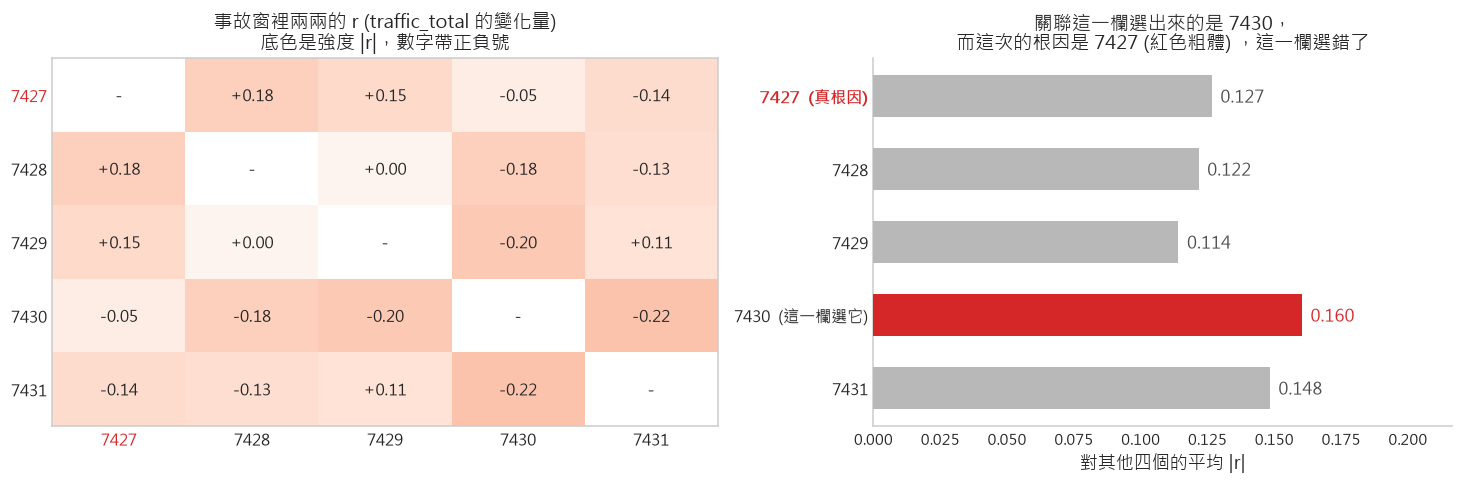


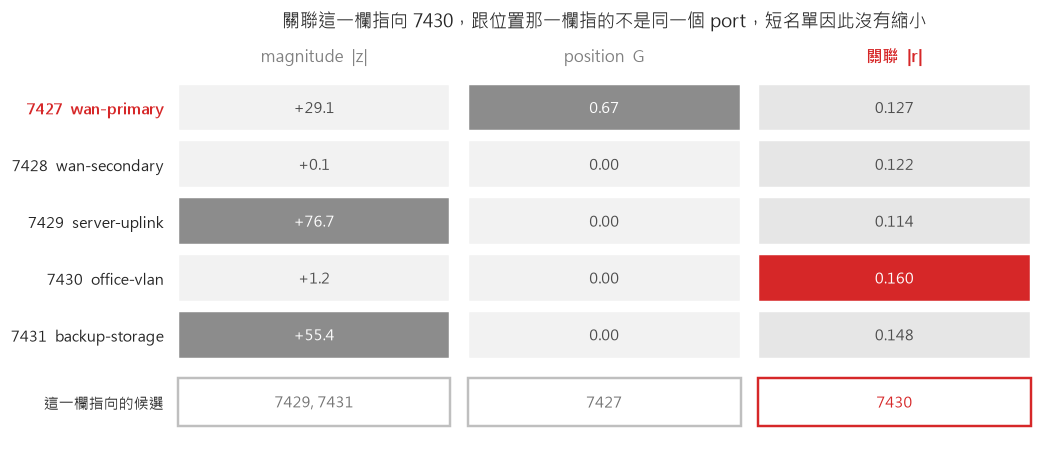

In [7]:
# 🎯 關聯: 事故窗裡誰跟誰一起動。函式與結果一次做完。

# ============ ⚙️ 可調參數 ============
ASSOC_METRIC = PICKED   # 關聯要算在哪一個 metric 上。上一格已經照相異值比例挑過。
                        # 改成 "error_rate": 7428 與 7430 的相異值比例只有 6% 與 23%，
                        #   五個 port 的十對裡有七對牽涉到它們，算得出數字但數字由一格
                        #   計數器決定 (7428 對 7431 會從 -0.13 變成 -0.44) 。
                        # 改成 "discard_rate" 或 "broadcast_total": 一樣稀疏，過不了同一個門檻
ASSOC_MIN_SAMPLES = 20   # 一對序列至少要有幾格才願意算相關係數，不到就回 None。
                         # 調小 (5): 五個點湊出 r = 0.9 的情況就會進到排名裡;
                         # 調大 (60): 事故窗只有 48 格，這一整欄會全部變成「算不出來」
ASSOC_WINDOW = (INCIDENT.start_time, INCIDENT.end_time)   # 只量事故發生的那 235 分鐘。
                         # 加長 (往前借正常時段): 樣本變多，但量到的變成「平常誰跟誰一起動」
# ====================================


# ---- 1. 兩條序列之間的 Pearson 相關係數 ----
#
#        r = Σ(x_i - x̄)(y_i - ȳ)  /  [ sqrt(Σ(x_i - x̄)²) * sqrt(Σ(y_i - ȳ)²) ]
#
#      分子是兩條序列「一起偏離自己的平均」的程度，分母是兩條各自偏離自己平均的程度，
#      除下去之後單位互相抵消，所以 r 一定落在 -1 (完全反向) 到 +1 (完全同向) 之間。
#      換成 Spearman 或 mutual information 只要改這個函式，底下兩層完全不用動;
#      但三種都是「同一格對同一格」比對，這次的因與果隔了 40 分鐘，換尺一樣對不上。
def pearson_pair(x, y):
    """算不出來就回 None，不要回 0: 「沒有關係」與「算不出來」是兩件事。"""
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    n = min(len(x), len(y))                    # 兩條長度不一樣時，以短的為準對齊
    x, y = x[:n], y[:n]
    if n < ASSOC_MIN_SAMPLES or x.std() < 1e-12 or y.std() < 1e-12:
        return None                            # 樣本不夠，或其中一條是常數 -> 分母是 0
    r = float(np.corrcoef(x, y)[0, 1])
    return r if np.isfinite(r) else None


# ---- 2. 相關要算在「變化量」上，不是算在原始的線上 ----
#         兩條都在往上爬的線，即使彼此毫無關係 r 也會接近 1，因為它們都跟時間相關。
#         一階差分 (每一格減掉前一格) 把「水準」拿掉，只留下同步擺動。
#         context 是給短事故窗用的: 往前多借一段正常時段一起差分，只為了湊過樣本數下限。
def delta_series(port, t0, t1, metric, context=None):
    lo_ = t0 - pd.Timedelta(context) if context else t0
    return np.diff(feat_by_port[port].loc[lo_:t1][metric].to_numpy(float))


# ---- 3. 一個 port 對其他四個的關聯，收成兩個數字 ----
#         強度 = mean(|r|)  先取絕對值再平均，反向也是一種強關係。這個數字進排名。
#         方向 = mean(r)    保留正負號，回答「一起漲還是一個漲一個跌」。它不進排名。
#         注意先後: 兩個都是「先對每一對算 r，再把四個 r 平均」，不是把四條序列先平均
#         成一條再算相關 (後者會讓同向與反向互相抵消)。
def assoc_row(t0, t1, metric, ports=None, context=None):
    ports = list(ports) if ports else ALL_PORTS
    d = {p: delta_series(p, t0, t1, metric, context) for p in ports}
    strength, direction = {}, {}
    for p in ports:
        rs = [pearson_pair(d[p], d[q]) for q in ports if q != p]
        rs = [r for r in rs if r is not None]
        if not rs:
            strength[p] = direction[p] = None
        else:
            strength[p] = float(np.mean(np.abs(rs)))
            direction[p] = float(np.mean(rs))
    return strength, direction


def pair_matrix(t0, t1, metric, ports=None, context=None):
    """每一對 port 在變化量上的 r，收成一個對稱矩陣。對角線留 NaN。

    assoc_row 把四個 r 壓成一個平均值，壓完就看不出「是哪一對在一起動」，所以另外
    留一個完整 5x5 的版本，圖上才看得到是哪兩格特別亮。"""
    ports = list(ports) if ports else ALL_PORTS
    d = {p: delta_series(p, t0, t1, metric, context) for p in ports}
    M = pd.DataFrame(np.nan, index=ports, columns=ports, dtype=float)
    for a in ports:
        for b in ports:
            if a != b:                          # 自己跟自己永遠是 1，填進去只會多一條紅斜線
                M.loc[a, b] = pearson_pair(d[a], d[b])
    return M


def cross_port_corr(metric, t0, t1):
    """跨 port 的相關矩陣，算在原始的線上 (沒有差分)。

    它只是一個「大家有多一起動」的摘要，給後面組 LLM context 判斷扇出的規模用的，
    不是排名用的證據。"""
    wide = pd.DataFrame({p: feat_by_port[p].loc[t0:t1][metric] for p in ALL_PORTS}).dropna(how="all")
    return wide.corr(method="pearson")


# ---- 4. 算這次的事故窗 ----
#         排名那一節的 C(c) 會再算一次，但那一次只算「有反應的那幾個 port」而且往前借
#         24 小時脈絡，所以那邊的數字跟這裡不會一模一樣。這裡要看的是全貌。
ROOT = INCIDENT.port_id                   # 標準答案，只拿來標紅，不進計算
PAIR_R = pair_matrix(*ASSOC_WINDOW, ASSOC_METRIC)
inc_assoc, inc_dir = assoc_row(*ASSOC_WINDOW, ASSOC_METRIC)
vals = [inc_assoc[p] if inc_assoc[p] is not None else 0.0 for p in ALL_PORTS]
top_port = ALL_PORTS[int(np.argmax(vals))]     # 這一欄自己指向誰，由程式挑，不是寫死的

# ---- 5. 先看表: 一列一個 port，強度進排名、方向是報告裡給人讀的那一欄 ----
display(pd.DataFrame(
    [(p[-4:], PORT_ROLE[p],
      "算不出來" if inc_assoc[p] is None else f"{inc_assoc[p]:.3f}",
      "算不出來" if inc_dir[p] is None else f"{inc_dir[p]:+.3f}",
      "" if inc_dir[p] is None else ("跟其他 port 同向" if inc_dir[p] > 0 else "跟其他 port 反向"))
     for p in ALL_PORTS],
    columns=["port", "role", "平均 |r| (強度，進排名)", "平均 r (方向)", "方向讀作"]).set_index("port"))

# ---- 6. 再看圖: 左邊十對的 r，右邊每個 port 的平均 |r| ----
#         左圖分成兩層是刻意的: 底色只畫強度 |r|，格子裡的數字帶正負號 (方向)。
#         一個顏色軸沒有辦法同時把強度與方向講清楚。
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.5), dpi=110,
                         gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
M = PAIR_R.reindex(index=ALL_PORTS, columns=ALL_PORTS)
# 顏色刻度固定在 0 到 1，不讓它隨資料自動縮放: 自動縮放的話，這次全部都很小的 r
# 會被拉開成一片深紅，看起來像關聯很強。
ax.imshow(M.abs().to_numpy(float), cmap="Reds", vmin=0, vmax=1.0, aspect="auto")
ax.grid(False)
for i, a in enumerate(ALL_PORTS):
    for j, b in enumerate(ALL_PORTS):
        v = M.iloc[i, j]
        # 算不出來的那一格印「-」，不要印 0.00，那會被讀成「量過，沒有關係」。
        ax.text(j, i, "-" if not np.isfinite(v) else f"{v:+.2f}", ha="center", va="center",
                fontsize=10.5, color="white" if np.isfinite(v) and abs(v) > 0.6 else "0.15")
ax.set_xticks(range(len(ALL_PORTS)))
ax.set_xticklabels([p[-4:] for p in ALL_PORTS], fontsize=10.5)
ax.set_yticks(range(len(ALL_PORTS)))
ax.set_yticklabels([p[-4:] for p in ALL_PORTS], fontsize=10.5)
for ticks in (ax.get_xticklabels(), ax.get_yticklabels()):    # 根因那一格的標籤上強調色
    for tick, p in zip(ticks, ALL_PORTS):
        if p == ROOT:
            tick.set_color(ACC)
ax.set_title(f"事故窗裡兩兩的 r ({ASSOC_METRIC} 的變化量)\n底色是強度 |r|，數字帶正負號",
             fontsize=12.5)

# 右: 每個 port 對其他四個的平均 |r|，也就是排名要讀的那個數字。
# 這一欄挑到的不是根因，而且不是程式挑錯: 相關係數比的是同一格的同步擺動，
# 這一次的因與果隔了 40 分鐘。它回答得了「誰跟誰一起動」，回答不了「誰造成的」。
ax = axes[1]
yy = np.arange(len(ALL_PORTS))[::-1]
ax.barh(yy, vals, height=0.58, zorder=3,
        color=[ACC if p == top_port else "0.72" for p in ALL_PORTS])
for y, p, v in zip(yy, ALL_PORTS, vals):
    ax.text(v + max(vals) * 0.02, y, "算不出來" if inc_assoc[p] is None else f"{v:.3f}",
            va="center", fontsize=11, color=ACC if p == top_port else "0.3")
ax.set_yticks(yy)
# 這一欄選中的那個 port 在標籤上直接標「(這一欄選它)」，真正的根因標「(真根因)」，
# 兩者用不同的字樣分開，不要只靠同一個紅色。
ax.set_yticklabels([f"{p[-4:]}" + ("  (這一欄選它)" if p == top_port else "")
                    + ("  (真根因)" if p == ROOT else "") for p in ALL_PORTS], fontsize=10.5)
for tick, p in zip(ax.get_yticklabels(), ALL_PORTS):
    if p == ROOT:
        tick.set_color(ACC); tick.set_fontweight("bold")
ax.set_xlim(0, max(vals) * 1.35)          # 右邊留白，最長那根旁邊的數字才不會被切掉
ax.grid(False)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.set_xlabel("對其他四個的平均 |r|", fontsize=12)
ax.set_title(f"關聯這一欄選出來的是 {top_port[-4:]}，\n"
             f"而這次的根因是 {ROOT[-4:]} (紅色粗體) ，這一欄選錯了", fontsize=12.5)
plt.tight_layout()
show_fig(fig)

# ---- 7. 記上候選看板 ----
#         這一欄指向平均 |r| 最高的那一個，而它不是位置那一欄留下來的那個 port，
#         所以兩欄沒有互相佐證，短名單沒有因為這一欄而縮小。
add_board_column(
    "關聯  |r|",
    {p: (f"{inc_assoc[p]:.3f}" if inc_assoc[p] is not None else "算不出來") for p in ALL_PORTS},
    {p: p == top_port for p in ALL_PORTS},
    top_port[-4:],
)
draw_board(f"關聯這一欄指向 {top_port[-4:]}，跟位置那一欄指的不是同一個 port，短名單因此沒有縮小")



### 這個關聯分析選錯 Root Cause 為什麼？應該怎麼處理？
- 這次的機制是「上游錯誤率慢慢升高 -> 下游因為重傳與佇列堆積而流量放大」,兩端隔了 40 分鐘。相關係數比的是**同一格**的變化量，隔了 40 分鐘的因與果在同一格上本來就對不起來。**相關量的是「一起擺動」,這次的機制是「先後」,所以它量不到。** 誰先誰後要換一把尺，就是下一節的 onset。
- **方向那一欄是換成 Pearson 才拿得到的。** 五個 port 裡有三個的平均 $r$ 是負的 (`7428`、`7430`、`7431`),代表它們的變化量跟其他 port 是反向的; mutual information 只會回報一個沒有正負號的數字，這一欄會整個消失。**方向這件事在讀傳播路徑的時候用得到**: 同一份資料裡的事故 R 是流量往下掉，一個沒有正負號的關聯數字說不出「下游是跟著漲還是跟著跌」
- **這一欄指錯人，不代表它該被拿掉。** 排名是四項等權相加，任何一項都可能在某一場事故上指錯;真正危險的是只用一項。下一節的 onset 與上一節的拓樸在這一場都指對了，四項合起來的結果會在「合成排名」那一節量出來


---

## 時序: 誰先越線

```mermaid
flowchart LR
    G1["位置<br/>拓樸可達範圍"] --> G2["統計關聯<br/>有沒有一起動"] --> G3["時序<br/>誰先動"] --> G4["可預測性<br/>加上它的過去<br/>預測得動嗎"]
    style G3 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### 拓樸講位置，這一節講時間。這一節只算一個東西: **誰先越線** 以 Onset 為例。

`anomaly_onset` 的定義與參數都照講義相同: 「第一次偏離同時段常態超過 k 個 sigma 的時刻」,門檻固定用 **k = 3**,而且**兩側都算**。兩件事要先講清楚:

- **兩側都算。** 只測上界的話，吞吐往下掉的根因永遠等不到 onset,那個 port 連排都排不進去 (同一份資料裡的事故 R 就是流量往下掉)
- **要求連續幾格才算數，是這一節唯一要調的參數。** 一格就算的話，單一取樣點的雜訊也會被記成一次越線; 要求連續三格的話，越線時刻一定會往後移。下一格把這條規則的代價量出來，再決定排名要用哪一個

<p align="center"><img src="slides/u08_timing.png" width="80%" alt="單元 08 的時序關係投影片: 異常沿系統傳播產生時間延遲; Anomaly Onset 找「第一次超過 k sigma 的時刻」(固定 k = 3、兩側都算) ，Cross-Correlation 找整段序列平移多少最對齊; 右邊提醒傳播延遲應符合系統機制，不合理的延遲會降低根因候選的可信度"></p>


,n,越線延遲中位數 (分),完全不再越線
run=3 對 run=1 的代價 (全部 17 個事故),,,
真根因,24,0,0
bystander,23,140,10


,Hit@1,MRR
只用時序這一項排名 (全部 17 個事故),,
run=1,0.66,0.70
run=3,0.81,0.80



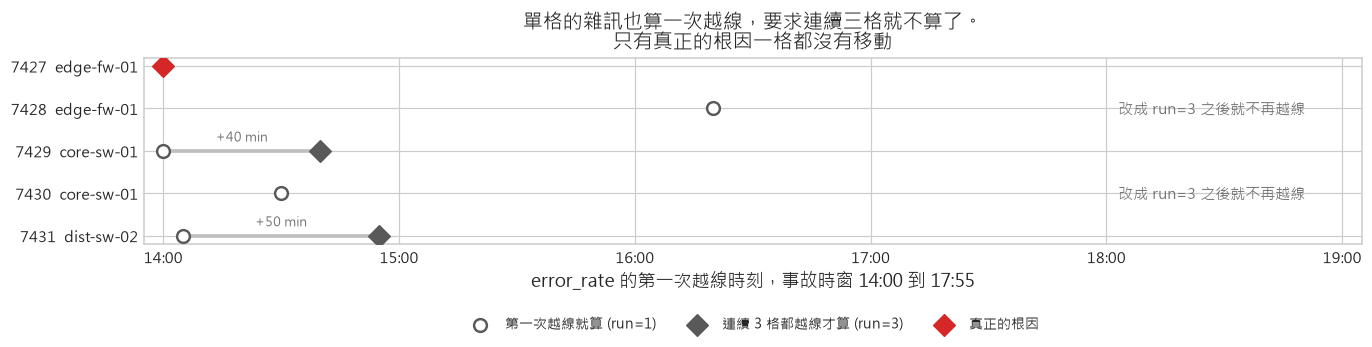


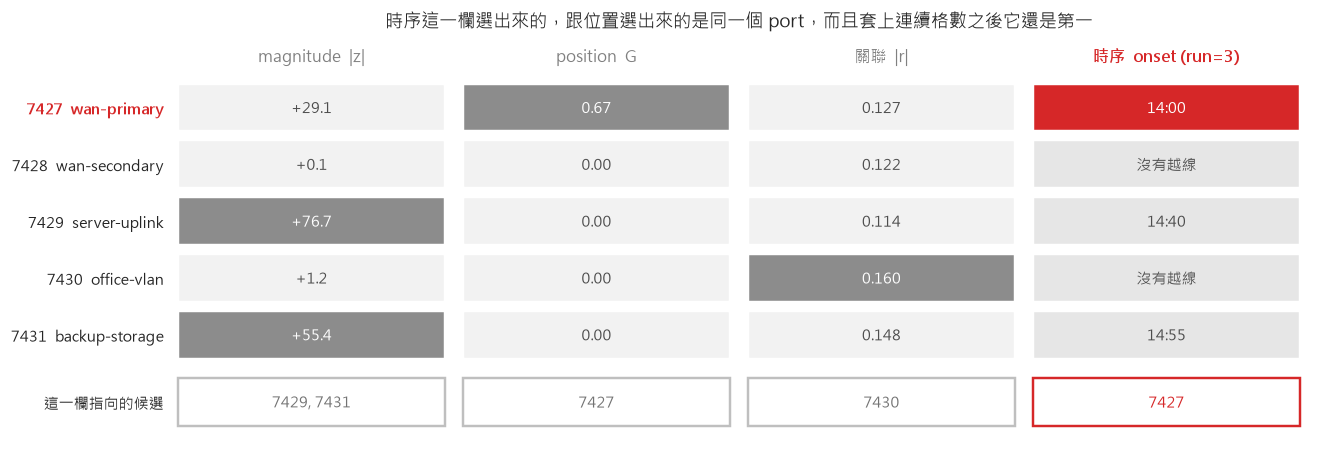

In [8]:
# 🎯 時序: 誰先越線。函式、兩種判準的代價與收穫、時間軸圖，一次做完。

# ============ ⚙️ 可調參數 ============
ONSET_K = 3      # 偏離同時段常態幾個標準差才算越線。
                 # 調小 (2): 越線時刻普遍提早，但平坦基線上的零星跳動也會被記成越線;
                 # 調大 (5): 溫和的劣化整段窗都不越線，這一次的根因會直接被排除掉。
                 # 選 3 的理由: 跟 Lab 06 的管制界限、跟拓樸那一節挑異常集合是同一個門檻
ONSET_RUN = 3    # 要連續幾格都越線才算數。一格 5 分鐘，所以 3 就是連續 15 分鐘。
                 # 代價與收穫由下面兩張表量出來，這個值就是照那兩張表挑的
RUN_COMPARE = (1, 3)   # 這一格要比較的兩個判準。run=1 等於「不加這條規則」
ONSET_PRE = "2h"       # 基線退路的長度 (首選同時段歷史，湊不到天數才會用到它)
# ====================================


# ---- 1. 越線時刻怎麼算 ----
#
#        dev_t = ( 觀測值_t - 同時段常態_t ) / 基線的標準差
#
#      分子的「同時段常態」是逐格的，分母的標準差整段窗共用一個，兩件事在 baseline_stats
#      已經算好了。dev 是一個沒有單位的倍數: dev = 3 讀作「比同時段常態高了三個標準差」。
#      然後找第一個「連續 run 格都滿足 |dev| > k」的位置，回傳那一串的第一格:
#      要回答的是「什麼時候開始的」，不是「什麼時候確認的」。
#      兩側都算 (取絕對值): 只測上界的話，吞吐掉下去的根因永遠等不到 onset，
#      T(c) 恆等於 0，那個 port 連排都排不進去 (事故 R 的根因就是流量往下掉)。
def anomaly_onset(port, metric, t0, t1, k=None, run=None, pre=None):
    # 預設值在函式裡面才去讀上面那三個參數，不是寫成 k=ONSET_K。差別在於: 寫成預設引數的話,
    # 它在 def 執行的當下就綁死了，之後改 ONSET_K 這個函式也不會跟著變。放在裡面才是活的。
    k = ONSET_K if k is None else k
    run = ONSET_RUN if run is None else run
    pre = ONSET_PRE if pre is None else pre
    cur = feat_by_port[port].loc[t0:t1][metric]
    if cur.empty:
        return None
    mu, sd, _ = baseline_stats(port, t0, t1, pre)
    # 事前基線完全平坦時標準差是 0，除下去會炸。夾一個極小值頂著，代價是這種 port 的
    # dev 會變成天文數字，等於退化成「第一個非零取樣點」。
    s = max(float(sd[metric]) if np.isfinite(sd[metric]) else 0.0, 1e-9)
    dev = np.nan_to_num((cur.to_numpy(float) - mu[metric].to_numpy(float)) / s, nan=0.0)
    hit, c = np.abs(dev) > k, 0
    for i, h in enumerate(hit):
        c = c + 1 if h else 0            # 連續計數: 中斷一格就歸零重數
        if c >= run:
            return cur.index[i - run + 1]    # 回那一串的第一格
    return None


# ---- 2. 評估用的兩個小工具，後面每一節都會用到 ----
def true_ports(ev):
    """這個事故真正被注入的 port，也就是評估時的標準答案 (回傳一個 set)。

    ev.port_id 等於 "MULTI" 的事故同時注入好幾個 port，答案要回原始資料撈。"""
    if ev.port_id != "MULTI":
        return {ev.port_id}
    w = features[(features.timestamp >= ev.start_time) & (features.timestamp <= ev.end_time)
                 & (features.event_label == ev.event_type)]
    return set(w.port_id.unique())


def hit_mrr(score, truth):
    """回傳 (Hit@1, RR)。score 是「port 對分數」的對照表，truth 是標準答案那個集合。

    Hit@1 = 真根因有沒有排在第一名; RR = 1 除以真根因的名次。
    平手一律給平均名次，三個並列第一時每個只拿三分之一: 不這樣做的話，平手的先後
    會沿用資料原本的順序，那是排序規則不是證據。"""
    r = pd.Series(score).astype(float).rank(ascending=False, method="average")
    best = float(min(r[p] for p in truth if p in r.index))     # 真根因排到第幾名
    top = float(r.min())
    n_top = int((r == top).sum())                              # 有幾個並列第一
    hit1 = (len([p for p in truth if float(r.get(p, np.inf)) == top]) / n_top
            if best == top else 0.0)
    return float(hit1), 1.0 / best


# ---- 3. 時序項 T(c): 越線時刻排第幾個，換算成 1 到 0 ----
#
#        T(c) = 1 - (這個候選的越線時刻排第幾個) / (一共有幾個不同的越線時刻)
#
#      用「第幾個」而不是用實際的分鐘差，是因為分鐘差會被最慢的那個 port 決定尺度:
#      一個三小時後才越線的旁觀者，會把前面幾個真正有先後的 port 全部壓成差不多的分數。
#      沒有越線的一律給 0。
def timing_term(ev, run):
    m = signature_metric(ev.event_type)
    onset = {p: anomaly_onset(p, m, ev.start_time, ev.end_time, run=run) for p in ALL_PORTS}
    slots = sorted({v for v in onset.values() if v is not None})
    return pd.Series({p: (1.0 - slots.index(onset[p]) / max(len(slots), 1))
                      if onset[p] is not None else 0.0 for p in ALL_PORTS})


# ---- 4. 這次事故窗上，兩種判準各算一次越線時刻 ----
t0_, t1_ = INCIDENT.start_time, INCIDENT.end_time
o1 = {p: anomaly_onset(p, SIGNATURE, t0_, t1_, run=RUN_COMPARE[0]) for p in ALL_PORTS}
o3 = {p: anomaly_onset(p, SIGNATURE, t0_, t1_, run=RUN_COMPARE[1]) for p in ALL_PORTS}

# ---- 5. 先看兩張表: 這條規則的代價，以及它換到的收穫 ----
#         代價: 連續三格才算，越線時刻一定會往後移; 問題是「往後移多少」與「有沒有整個
#         消失」。真根因與旁觀者要分開報: 池在一起算中位數會得到 0 分鐘，看起來像
#         「這條規則完全沒有代價」，那是真根因那一半把數字拉平的。
root_d, by_d = [], []
for _, ev in events.iterrows():
    m = signature_metric(ev.event_type)
    for p in ALL_PORTS:
        a = anomaly_onset(p, m, ev.start_time, ev.end_time, run=RUN_COMPARE[0])
        if a is None:
            continue                                  # run=1 都沒越線的，兩邊都沒得比
        b = anomaly_onset(p, m, ev.start_time, ev.end_time, run=RUN_COMPARE[1])
        # b 是 None 代表「完全不再越線」。這種要記成 nan，不能記成 0 分鐘: 0 分鐘讀作
        # 沒有被拖慢，而它其實是整個不見了，兩件事對排名的影響相反。
        d = np.nan if b is None else (b - a).total_seconds() / 60
        injected = ({ev.port_id} if ev.port_id != "MULTI" else
                    set(features[(features.timestamp >= ev.start_time)
                                 & (features.timestamp <= ev.end_time)
                                 & (features.event_id == ev.event_id)].port_id.unique()))
        (root_d if p in injected else by_d).append(d)
root_d, by_d = np.array(root_d, float), np.array(by_d, float)
_cost_title = f"run={RUN_COMPARE[1]} 對 run={RUN_COMPARE[0]} 的代價 (全部 {len(events)} 個事故)"
display(pd.DataFrame([
    ("真根因", len(root_d), f"{np.nanmedian(root_d):.0f}", int(np.isnan(root_d).sum())),
    ("bystander", len(by_d), f"{np.nanmedian(by_d):.0f}", int(np.isnan(by_d).sum())),
], columns=[_cost_title, "n", "越線延遲中位數 (分)", "完全不再越線"]).set_index(_cost_title))

# 收穫: 只用時序這一項去排名，兩種判準各拿幾分。這一格不挑值，只把依據印出來;
# 真正定值的地方是最上面的 ONSET_RUN。
_gain = []
for r in RUN_COMPARE:
    per = [hit_mrr(timing_term(ev, r), true_ports(ev)) for _, ev in events.iterrows()]
    _gain.append((f"run={r}", f"{np.mean([h for h, _ in per]):.2f}",
                  f"{np.mean([q for _, q in per]):.2f}"))
_gain_title = f"只用時序這一項排名 (全部 {len(events)} 個事故)"
display(pd.DataFrame(_gain, columns=[_gain_title, "Hit@1", "MRR"]).set_index(_gain_title))

# ---- 6. 再看圖: 一個 port 一列，空心圓是 run=1 的時刻、實心菱形是 run=3 的時刻 ----
#         兩者之間拉一條灰線，長度就是「這條規則把它往後推了多久」。
fig, ax = plt.subplots(figsize=(12.6, 3.6), dpi=110)
yy = np.arange(len(ALL_PORTS))[::-1]
for y, p in zip(yy, ALL_PORTS):
    is_root = p == INCIDENT.port_id
    if o1[p] is not None and o3[p] is not None and o3[p] > o1[p]:
        ax.plot([o1[p], o3[p]], [y, y], color="0.75", lw=2.4, zorder=1, solid_capstyle="butt")
        ax.text(o1[p] + (o3[p] - o1[p]) / 2, y + 0.22,
                f"+{int((o3[p] - o1[p]).total_seconds() // 60)} min", ha="center",
                fontsize=8.5, color="0.45")
    if o1[p] is not None:
        ax.scatter([o1[p]], [y], s=70, facecolor="white", edgecolor="0.35", lw=1.6, zorder=3)
    if o3[p] is not None:
        ax.scatter([o3[p]], [y], s=100, marker="D",
                   color=ACC if is_root else "0.35", zorder=4)
    else:
        # 這一列沒有點可以畫，寫一行字，不要讓它看起來像漏畫。
        ax.text(t1_ + pd.Timedelta("8min"), y, f"改成 run={RUN_COMPARE[1]} 之後就不再越線",
                va="center", fontsize=9.5, color="0.45")
# 三個空的 scatter 只是為了讓圖例有三個項目可以列。
ax.scatter([], [], s=70, facecolor="white", edgecolor="0.35", lw=1.6,
           label=f"第一次越線就算 (run={RUN_COMPARE[0]})")
ax.scatter([], [], s=100, marker="D", color="0.35",
           label=f"連續 {RUN_COMPARE[1]} 格都越線才算 (run={RUN_COMPARE[1]})")
ax.scatter([], [], s=100, marker="D", color=ACC, label="真正的根因")
ax.set_yticks(yy)
ax.set_yticklabels([f"{p[-4:]}  {PORT_DEVICE[p]}" for p in ALL_PORTS], fontsize=9.5)
ax.set_xlim(t0_ - pd.Timedelta("5min"), t1_ + pd.Timedelta("70min"))   # 右邊留白放那行字
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel(f"{SIGNATURE} 的第一次越線時刻，事故時窗 {t0_:%H:%M} 到 {t1_:%H:%M}", fontsize=11.5)
ax.set_title("單格的雜訊也算一次越線，要求連續三格就不算了。\n只有真正的根因一格都沒有移動",
             fontsize=13)
ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=3, frameon=False)
plt.tight_layout()
show_fig(fig)

# ---- 7. 記上候選看板。排名的時序項用 ONSET_RUN，理由就是上面那兩張表 ----
_slots3 = sorted({v for v in o3.values() if v is not None})
add_board_column(
    f"時序  onset (run={ONSET_RUN})",
    {p: (f"{o3[p]:%H:%M}" if o3[p] is not None else "沒有越線") for p in ALL_PORTS},
    {p: (o3[p] is not None and _slots3 and o3[p] == _slots3[0]) for p in ALL_PORTS},
    ", ".join(q[-4:] for q in ALL_PORTS if o3[q] is not None and _slots3 and o3[q] == _slots3[0]),
)
draw_board("時序這一欄選出來的，跟位置選出來的是同一個 port，而且套上連續格數之後它還是第一")



### 必須選擇 CONSEC

**先看第一張表，那是這條規則的代價。** 17 個事故跑一次，真根因那 24 組延遲中位數 0 分鐘、沒有一組消失; bystander 那 23 組延遲中位數 140 分鐘，其中 10 組完全不再越線。**壓掉旁觀者的力道遠大於拖慢根因的代價。**

**這張表要這樣拆才讀得出東西。** 把 47 組池在一起算中位數會得到 0 分鐘，看起來像「這條規則完全沒有代價」，那是真根因那一半把數字拉平的。**代價與收穫落在不同的族群身上的時候，指標一定要分族群報。**

**第二張表是它換到的收穫。** 只用時序這一項排名，`run=1` 是 Hit@1 0.66 / MRR 0.70，`run=3` 是 0.81 / 0.80。代價幾乎全部落在 bystander 身上，而分數是往上的。

**最後看圖: 這條規則換掉了第一名。** 空心圓是「第一次越線就算」(`run=1`)，實心菱形是「連續 3 格都越線才算」(`run=3`，也就是 Lab 06 那條 SPC run rule 換一個地方用)。

- `run=1` 時根因與 `port-id7429` **同時**在 14:00 並列第一。但 `port-id7429` 的 `error_rate` 事故前恆等於 0，基線標準差小到只剩儀器解析度，第一格一個零星跳動就算到將近 5 個 sigma。**它越的不是事故的線，是一個平坦基線的線**
- `run=3` 之後紅色菱形**一格都沒有動** (還是 14:00)，兩個下游 port 退到 14:40 與 14:55，另外兩個 port 整個不再越線。原本四個分不太開的越線時刻，變成三個排得出先後的時刻


---

## 可預測性: 加上它的過去，預測得動嗎

```mermaid
flowchart LR
    G1["位置<br/>拓樸可達範圍"] --> G2["統計關聯<br/>有沒有一起動"] --> G3["時序<br/>誰先動"] --> G4["可預測性<br/>加上它的過去<br/>預測得動嗎"]
    style G4 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### Granger 問的只有一句話: **加上 X 的過去，預測 Y 會不會變準。**

做法只有三步:

1. 配一個模型，**只用 Y 自己的過去**去預測 Y,記下它的預測誤差
2. 再配一個模型，**多加上 X 的過去**,記下它的預測誤差
3. 比兩個誤差

#### 會印出兩個數字，它們回答的是不同的問題

- **誤差少掉幾成**: 這是「X 的過去幫了多少忙」。少 30% 代表加了 X 之後預測明顯變準，少 2% 代表幾乎沒幫上。**這個數字直接就是效果的大小，先看它**
- **p 值**: 它把上面那個下降換算成「如果 X 其實一點忙都沒幫上，純靠運氣看到這麼大的下降有多容易」。**p 越小代表越不容易靠運氣拿到**。這一章用 p < 0.0025 當門檻 (0.05 除以 20,因為五個 port 兩兩有方向共 20 個配對，做二十次檢定就會有二十次撞運氣的機會)

**兩個數字要一起看。** 樣本一多，一個只降 1% 的效果也可以有很小的 p 值; 樣本一少，一個降 30% 的效果也可能 p 值很大。**p 值說的是「像不像運氣」,不是「效果大不大」。** 下一格跑的就是後面這一種。

#### 五個 port 兩兩有方向，一共 20 個配對，全部都要跑

**只挑一對來看會挑到自己想看的那一對。** 所以下一格把 20 個配對全部跑一次，再照「誤差少掉幾成」由大到小排，把**前五名**畫出來。前五名是程式排出來的，不是先想好答案再挑的。

#### 送進檢定之前先處理兩件事

1. **序列不能有趨勢**: 兩條都在往上長的序列，互相預測一定準，那是趨勢不是關係。做法是送進去之前先做一階差分 (每一格減掉前一格，只留變化量)
2. **看得到多長的機制，由聚合粒度決定**: 這條耦合的延遲是 45 到 90 分鐘，5 分鐘一格再往回看 1 格根本看不見它。做法是把序列**聚合到機制的時間尺度** (60 分鐘平均，往回看 2 格),不是一直疊 lag: 同樣的時間跨度，疊 lag 要 37 個參數，聚合只要 5 個

**就算兩個數字都過了，它還是不能單獨當因果證據。** 兩條序列一起跟著日夜週期上下也會互相預測得動，差分擋掉一部分，擋不掉全部。所以這一項在排名裡只佔 $C(c)$ 的一小塊，不是自己決定第一名。

<p align="center"><img src="slides/u08_granger.png" width="80%" alt="單元 08 的 Granger Causality 投影片: 它回答的是「X 的歷史是否能幫助預測 Y」,而不是「X 是否真正造成 Y」,可以縮小搜尋空間但不能單獨證明根因"></p>



,只用自己的過去 rss,再加上因的過去 rss,誤差少掉幾成,樣本數,p 值,過不過 0.0025
配對 (因 → 果),,,,,,
7427 → 7429,2.953e-08,2.049e-08,30.6 %,25,0.026,沒過
7427 → 7430,1.232e-08,8.854e-09,28.1 %,25,0.037,沒過
7427 → 7431,1.736e-07,1.377e-07,20.7 %,25,0.099,沒過
7430 → 7431,1.736e-07,1.457e-07,16.1 %,25,0.173,沒過
7429 → 7430,1.232e-08,1.068e-08,13.3 %,25,0.240,沒過



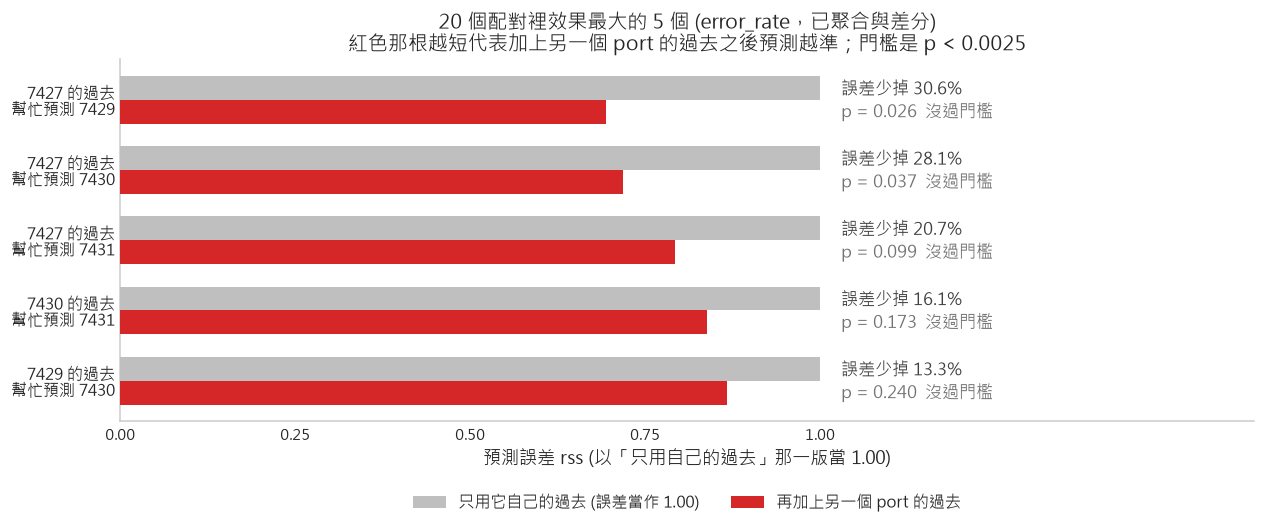

,事故 L (error_rate，235 分鐘),事故 G (broadcast_total，55 分鐘的廣播風暴)
port,,
7427,0.00,0.00
7428,0.00,0.00
7429,0.00,0.00
7430,0.00,0.00
7431,0.00,0.00



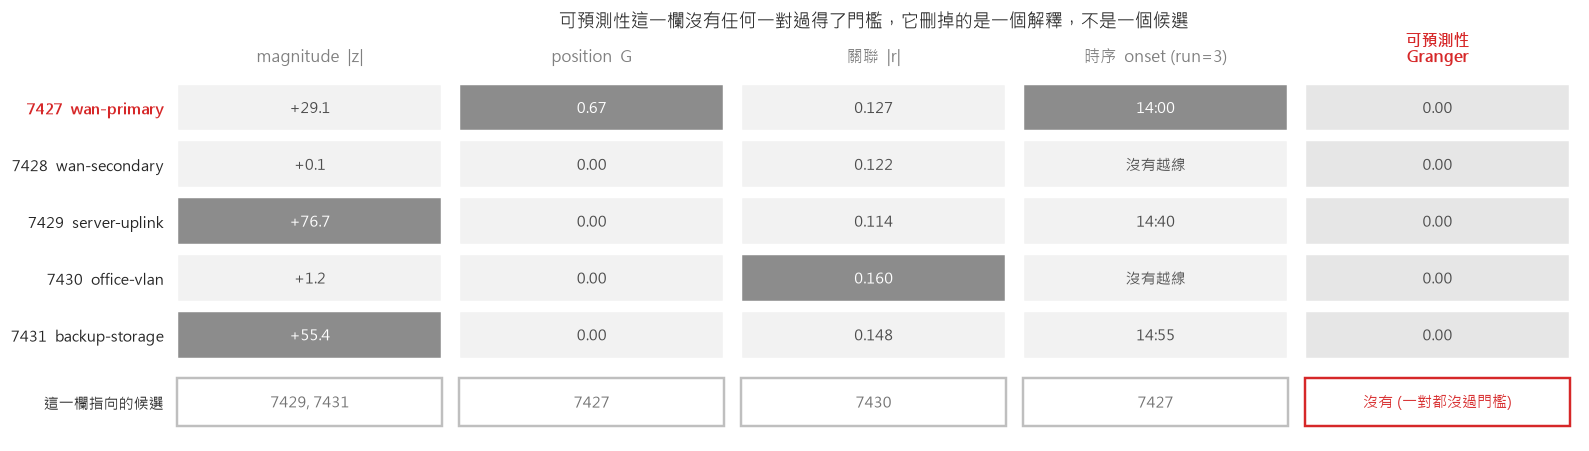

In [9]:
# 🎯 可預測性: 加上另一個 port 的過去，預測得動嗎。函式與結果一次做完。

# ============ ⚙️ 可調參數 ============
GRANGER_RULE = "60min"    # 幾分鐘的資料併成一格。它決定這個檢定看得見多長的機制:
                          # 往回看 2 格就是往回看 2 x 60 = 120 分鐘。
                          # 調小 ("5min"): 看得見快事故，但 45 到 90 分鐘的耦合延遲要疊
                          #   很多 lag 才蓋得到; 調大 ("180min"): 樣本掉到只剩幾個
GRANGER_LAG = 2           # 往回看幾格。它同時是模型的參數個數: 參數 = 2 * lag + 1。
                          # 調大 (6): 蓋得住更長的延遲，但 25 個樣本配 13 個參數，
                          #   殘差一定會變小，那是參數多到足以擬合雜訊
GRANGER_CONTEXT = "24h"   # 事故窗前面再往前借多久一起算。事故本身聚合完只剩幾格，不借
                          # 連配模型都不夠。實測: 借 72 小時平均每個無事件窗出現 5.96 個
                          # 假的配對，借 24 小時是 1.77 個
TOP_N = 5                 # 圖上畫幾個配對 (20 個全部都算，這只影響畫出來幾列)
# ====================================
# 多重檢定的門檻: 5 個 port 兩兩有方向 = 20 個配對，做二十次檢定就有二十次撞運氣的機會，
# 所以門檻要除以檢定次數 (Bonferroni 校正)。除數跟著程式算，換成六個 port 就自動變 30。
N_PAIRS = len(ALL_PORTS) * (len(ALL_PORTS) - 1)
ALPHA = 0.05 / N_PAIRS


# ---- 1. 送進檢定之前的兩道處理: 先聚合到機制的時間尺度，再做一階差分 ----
#         順序不能反: 先差分再聚合等於把變化量平均掉。
#         為什麼一定要差分: 兩條都在往上長的序列互相預測一定準，那是趨勢不是關係。
def granger_input(port, metric, t0, t1):
    s = feat_by_port[port].loc[t0 - pd.Timedelta(GRANGER_CONTEXT):t1][metric]
    return np.diff(s.resample(GRANGER_RULE).mean().to_numpy(float))


# ---- 2. 檢定本體: 配兩個模型，比它們的預測誤差 ----
#
#        restricted    y_t = a1*y_{t-1} + a2*y_{t-2} + c                            -> RSS_r
#        unrestricted  y_t = a1*y_{t-1} + a2*y_{t-2} + b1*x_{t-1} + b2*x_{t-2} + c  -> RSS_u
#
#      RSS 是殘差平方和 (每一格的預測誤差平方之後加起來)，越小代表預測越準。
#      多給模型兩個欄位，RSS 一定不會變大，問題是它「小得夠不夠多」:
#
#        F = [ (RSS_r - RSS_u) / lag ]  /  [ RSS_u / (n - 2*lag - 1) ]
#
#      分子是每多用一個參數換到多少誤差下降，分母是剩下的誤差平均攤到每個自由度上有多大。
#      p 值是把 F 丟進 F 分配，問「x 完全沒幫上忙的話，純靠運氣拿到這麼大的 F 有多容易」。
#      它量的是「像不像隨機波動」，不是「效果多大」; 效果多大要看 RSS 少掉幾成。
#      自己寫而不用套件，就是為了看得見 RSS 下降，那才是效果量。
def granger_f(y, x, lag=None):
    lag = GRANGER_LAG if lag is None else lag        # 理由同 anomaly_onset: 預設引數會綁死
    """方向約定: granger_f(y, x, lag) 讀作「x 幫不幫得上預測 y」。"""
    y = np.asarray(y, float).ravel(); x = np.asarray(x, float).ravel()
    N = min(len(y), len(x)); y, x = y[:N], x[:N]
    n = N - lag                       # 有幾列可以拿來配模型 (前 lag 格沒有完整的落後項)
    df_den = n - 2 * lag - 1          # 分母的自由度 = 樣本數 - 參數個數
    if n <= 0 or df_den <= 0:         # 樣本比參數還少，回一整排 NaN 讓呼叫端知道算不出來
        return dict(F=np.nan, p=np.nan, rss_r=np.nan, rss_u=np.nan, n=max(n, 0), df_den=df_den)
    # 對齊錯一格，檢定量到的就是別的東西，而且不會報錯，所以這兩行值得逐一對過。
    Y = y[lag:]
    ylags = np.column_stack([y[lag - k: N - k] for k in range(1, lag + 1)])
    xlags = np.column_stack([x[lag - k: N - k] for k in range(1, lag + 1)])
    ones = np.ones((n, 1))
    Xr, Xu = np.hstack([ylags, ones]), np.hstack([ylags, xlags, ones])
    rss = lambda X: float(((Y - X @ np.linalg.lstsq(X, Y, rcond=None)[0]) ** 2).sum())
    rss_r, rss_u = rss(Xr), rss(Xu)
    # unrestricted 幾乎完美擬合時 F 的分母會接近 0，算出一個無限大的「顯著」。回 NaN 擋掉。
    if rss_u <= 1e-12 * max(float(((Y - Y.mean()) ** 2).sum()), 1.0):
        return dict(F=np.nan, p=np.nan, rss_r=rss_r, rss_u=rss_u, n=n, df_den=df_den)
    F = ((rss_r - rss_u) / lag) / (rss_u / df_den)
    return dict(F=float(F), p=float(stats.f.sf(F, lag, df_den)), rss_r=rss_r, rss_u=rss_u,
                n=n, df_den=df_den)


def granger_scan(win):
    """掃過全部 20 個有向配對，照 drop_pct (誤差少掉幾成) 由大到小排。

    「誰幫得上預測誰」有方向，所以 (A 幫 B) 與 (B 幫 A) 是兩件不同的事，兩個都要算。"""
    rows = []
    for cause in ALL_PORTS:
        for effect in ALL_PORTS:
            if cause == effect:
                continue
            r = granger_f(win[effect], win[cause])          # 「cause 幫不幫得上預測 effect」
            # 算不出來就記 NaN，不要記成 0，否則表上會出現一個看起來像「完全沒幫上忙」
            # 的假結論。
            drop = (100 * (1 - r["rss_u"] / r["rss_r"])
                    if np.isfinite(r["rss_r"]) and r["rss_r"] > 0 and np.isfinite(r["rss_u"])
                    else np.nan)
            rows.append({"cause": cause, "effect": effect, "drop_pct": drop,
                         "p": r["p"], "n": r["n"], "rss_r": r["rss_r"], "rss_u": r["rss_u"]})
    return pd.DataFrame(rows).sort_values("drop_pct", ascending=False).reset_index(drop=True)


# ---- 3. 跑這次的事故窗。檢定跑在簽章指標上: 故障本身就出現在這一條序列上 ----
gwin = {p: granger_input(p, SIGNATURE, INCIDENT.start_time, INCIDENT.end_time) for p in ALL_PORTS}
PAIRS = granger_scan(gwin)
TOP5 = PAIRS.head(TOP_N).reset_index(drop=True)

# ---- 4. 先看表: 圖上讀不出來的是兩個 rss 的原始大小，以及實際用幾列資料配出來的 ----
display(pd.DataFrame(
    [(f"{r.cause[-4:]} → {r.effect[-4:]}", f"{r.rss_r:.3e}", f"{r.rss_u:.3e}",
      f"{r.drop_pct:.1f} %", f"{r.n}", f"{r.p:.3f}",
      "過" if (np.isfinite(r.p) and r.p < ALPHA) else "沒過")
     for r in TOP5.itertuples()],
    columns=["配對 (因 → 果)", "只用自己的過去 rss", "再加上因的過去 rss",
             "誤差少掉幾成", "樣本數", "p 值", f"過不過 {ALPHA:.4f}"]).set_index("配對 (因 → 果)"))

# ---- 5. 再看圖: 五個配對各一列，兩根長條就是這個檢定的全部 ----
#         每一列的誤差都先除以自己的 rss_r，所以灰色那根一律是 1.00: 五個配對的 rss
#         差好幾個數量級，不這樣做的話圖上只看得到最大的那一根。
fig, ax = plt.subplots(figsize=(11.6, 5.0), dpi=110)
yy = np.arange(len(TOP5))[::-1]
h = 0.34
ratio = (TOP5.rss_u / TOP5.rss_r).to_numpy(float)      # 加上上游之後，誤差剩下幾成
ax.barh(yy + h / 2, np.ones(len(TOP5)), h, color="0.75", zorder=3,
        label="只用它自己的過去 (誤差當作 1.00)")
ax.barh(yy - h / 2, ratio, h, color=ACC, zorder=3, label="再加上另一個 port 的過去")
for y, row, rt in zip(yy, TOP5.itertuples(), ratio):
    passed = np.isfinite(row.p) and row.p < ALPHA
    ax.text(1.03, y + h / 2, f"誤差少掉 {row.drop_pct:.1f}%", va="center", fontsize=11,
            color="0.25")
    ax.text(1.03, y - h / 2,
            f"p = {row.p:.3f}  {'過門檻' if passed else '沒過門檻'}", va="center",
            fontsize=11, color=ACC if passed else "0.45")
ax.set_yticks(yy)
ax.set_yticklabels([f"{r.cause[-4:]} 的過去\n幫忙預測 {r.effect[-4:]}" for r in TOP5.itertuples()],
                   fontsize=10.5)
ax.set_xlim(0, 1.62)               # 長條最長只到 1.0，右邊留白給那兩行字
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel("預測誤差 rss (以「只用自己的過去」那一版當 1.00)", fontsize=12)
ax.grid(False)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.legend(fontsize=10.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2,
          frameon=False)
ax.set_title(f"20 個配對裡效果最大的 {TOP_N} 個 ({SIGNATURE}，已聚合與差分)\n"
             f"紅色那根越短代表加上另一個 port 的過去之後預測越準；門檻是 p < {ALPHA:.4f}",
             fontsize=13)
plt.tight_layout()
show_fig(fig)

# ---- 6. 收成排名要用的那一個數字，並看同一個設定套在更快的事故上會怎樣 ----
#         定義: 這個 port 當「因」的時候，四個下游配對裡有幾個通過門檻，除以 4。
#         聚合粒度就是可見範圍: 60 分鐘一格的檢定看不見 55 分鐘就結束的事 (事故 G)。
g_inc = {p: float((PAIRS[(PAIRS.cause == p) & (PAIRS.p < ALPHA)].shape[0])
                  / (len(ALL_PORTS) - 1)) for p in ALL_PORTS}
_evG = events[events.event_id == "G"].iloc[0]
_mG = signature_metric(_evG.event_type)
_wG = {p: granger_input(p, _mG, _evG.start_time, _evG.end_time) for p in ALL_PORTS}
_pairsG = granger_scan(_wG)
_gG = {p: float((_pairsG[(_pairsG.cause == p) & (_pairsG.p < ALPHA)].shape[0])
                / (len(ALL_PORTS) - 1)) for p in ALL_PORTS}
_minG = int((_evG.end_time - _evG.start_time).total_seconds() // 60)
_minL = int((INCIDENT.end_time - INCIDENT.start_time).total_seconds() // 60)
display(pd.DataFrame(
    [(p[-4:], f"{g_inc[p]:.2f}", f"{_gG[p]:.2f}") for p in ALL_PORTS],
    columns=["port",
             f"事故 {INCIDENT.event_id} ({SIGNATURE}，{_minL} 分鐘)",
             f"事故 {_evG.event_id} ({_mG}，{_minG} 分鐘的廣播風暴)"]).set_index("port"))

# ---- 7. 記上候選看板。這次沒有任何一個 port 過得了門檻，所以整欄都不上色 ----
_g_top = [q[-4:] for q in ALL_PORTS if g_inc[q] > 0]
add_board_column(
    "可預測性\nGranger",
    {p: f"{g_inc[p]:.2f}" for p in ALL_PORTS},
    {p: g_inc[p] > 0 for p in ALL_PORTS},
    ", ".join(_g_top) if _g_top else "沒有 (一對都沒過門檻)",
)
draw_board("可預測性這一欄沒有任何一對過得了門檻，它刪掉的是一個解釋，不是一個候選")


---

## 把四種證據合成一個排名: Score(c)

```mermaid
flowchart LR
    M1["照直覺查一遍<br/>用幅度排"] --> M2["四種證據<br/>位置、關聯<br/>時序、可預測性"] --> M3["合成一個排名<br/>Score(c)"] --> M4["LLM 架構<br/>打包 context<br/>檢索領域知識"] --> M5["LLM 診斷<br/>與驗證"] --> M6["換產業、換檢索<br/>回饋迴路與上線"]
    style M3 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

理論課的排名公式是把幾種證據加權相加，講義這一張把排法攤開來講:

<p align="center"><img src="slides/u08_ranking.png" width="80%" alt="單元 08 的根因排名投影片: 上方是多重證據融合成根因候選排名的整體流程，左下講四種只看單一指標的排法為什麼都不夠 (只看最高異常分數、只看最早告警時間、只看連續數最多的節點、只看相關性最高的指標) ，右下是標題寫五大構面、圖上畫出四項可以直接算的證據 A(c) 異常程度、T(c) 時間一致性、G(c) 拓樸位置、C(c) 統計與因果證據，合成 Score(c) = w1A(c) + w2T(c) + w3G(c) + w4C(c)，權重可依系統特性與經驗調整"></p>

前面四節算出來的東西剛好各對應講義的其中一項:

```mermaid
flowchart LR
    EV3["候選自身偏離程度<br/>z 分數"] --> A["A(c)<br/>異常幅度"]
    EV4["時序先後<br/>onset (run=3)"] --> T["T(c)<br/>時間一致性"]
    EV5["拓樸限制<br/>下游可達範圍"] --> G["G(c)<br/>拓樸位置"]
    EV1["統計關聯<br/>Pearson 相關"] --> C["C(c)<br/>統計或因果證據"]
    EV2["可預測性檢定<br/>Granger causality"] --> C
    A --> R["根因候選排名"]
    T --> R
    G --> R
    C --> R
```

$$Score(c) = \frac{A(c) + T(c) + G(c) + C(c)}{4}$$

#### 為什麼四項各佔一樣的比重

- 講義寫的是「權重可依系統特性與經驗調整」，沒有指定任何數字，所以這一章就用平均來做示範。
- 權重也可以用過往的所有事件，來擬合一個模型來幫你決定權重

,port_id,z_signature,A,T,G,C,C_assoc,C_granger,C_cooc,score
rank,,,,,,,,,,
1,port-id7427,29.1,1.00,1.00,0.67,0.239,0.065,0.0,0.6,72.65
2,port-id7429,76.7,1.00,0.67,0.00,0.251,0.091,0.0,0.6,47.94
3,port-id7431,55.4,1.00,0.33,0.00,0.241,0.070,0.0,0.6,39.37
4,port-id7430,1.2,0.15,0.00,0.00,0.000,0.000,0.0,0.0,3.66
5,port-id7428,0.1,0.02,0.00,0.00,0.000,0.000,0.0,0.0,0.39



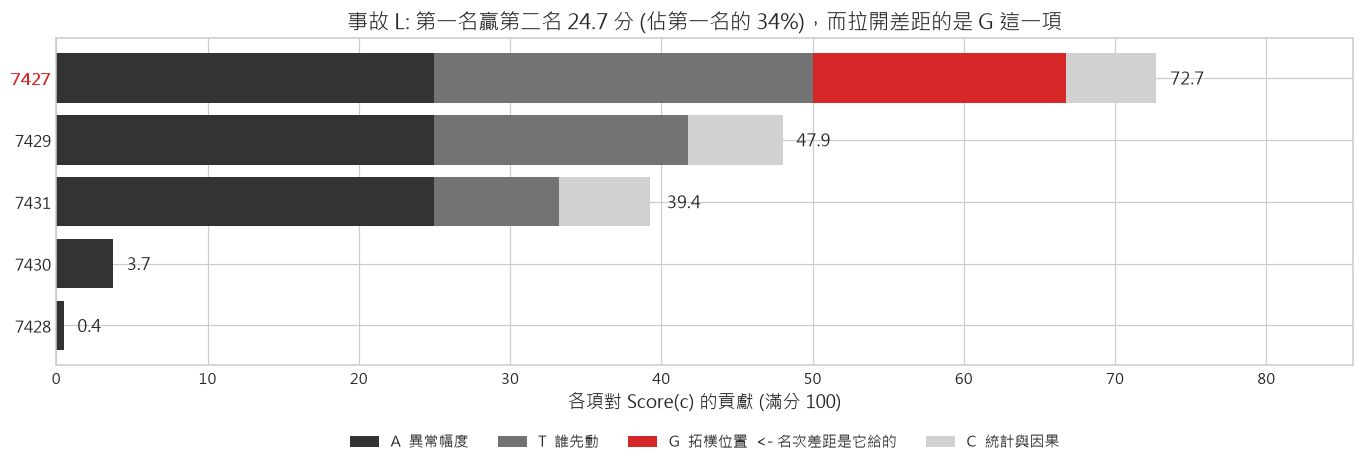

In [10]:
# 🎯 四項證據各夾到 0 到 1 之間再等權相加，收成 Score(c)。

# ============ ⚙️ 可調參數 ============
W = (0.25, 0.25, 0.25, 0.25)   # A、T、G、C 四項各佔總分多少，四個加起來是 1。
                               # 講義只寫「權重可依系統特性與經驗調整」，沒有給數字，而這份
                               # 資料只有 17 個事故，配出來的權重是在背這 17 個答案不是通則，
                               # 所以用最沒有立場的那一組: 等權
A_SATURATION = 8.0   # 幅度項的滿分線: A = |z| / 8 再夾在 0 與 1 之間。
                     # 調小 (4): 更多 port 被夾到 1.00，A 更分不出名次;
                     # 調大 (30): A 分得出高低的範圍變寬，但幅度在總分裡的份量跟著變大
SUB_W = {"assoc": 0.45, "granger": 0.20, "cooc": 0.35}   # C(c) 裡三個子項各佔多少。
                     # assoc 給最大，因為只有它在同一場事故裡分得出候選之間的差別;
                     # granger 給最小，因為它在短窗上經常整排是 0
RANK_Z = ANOM_Z      # 幅度上偏離幾個標準差才算「有反應」。**這裡不是另一個可調參數**:
                     # 它直接指向拓樸那一節的 ANOM_Z，因為「異常」全章只有一個定義。
                     # 之前這裡寫死 3，跟 ANOM_Z 剛好一樣所以看不出來，但把 ANOM_Z
                     # 改掉的話排名不會跟著動，那是講錯的。要調就調 ANOM_Z
# ====================================
# 三種證據狀態。第三種不是 0: 它不影響分數，但它會影響信心，所以要分開記。
PRESENT, ZERO, UNAVAILABLE = "present", "zero", "unavailable"


# ---- 1. C(c): 統計或因果證據，裡面裝三個子項 ----
#
#        C(c) = 0.45 * assoc + 0.20 * granger + 0.35 * cooc
#
#        assoc   這個 port 對「其他有反應的 port」的平均 |r|
#        granger 這個 port 當因的時候，通過門檻的配對數 / 配對總數
#        cooc    有反應的 port 數 / 全部 port 數
#      注意 cooc 對 R 裡的每一個 port 都是同一個值，所以 C 在同一場事故裡的鑑別力
#      全部來自 assoc。
#      unavailable 一律以 0 計分，不重新正規化: 把算不出來的子項從分母拿掉再把權重攤給
#      其他子項，會讓「沒有證據」跟「證據滿分」拿到一樣的 C。
def c_evidence(ev, R, metric):
    """回傳 (合成分數, 三個子項的值, 三個子項的狀態)，三樣都是以 port 為鍵的 dict。

    R 是這次事故的 affected set (有反應的 port)。只有一個 port 有反應時，沒有第二條
    序列可以關聯或因果，assoc 與 granger 標成 unavailable 而不是 0。"""
    val = {p: {} for p in ALL_PORTS}
    sta = {p: {} for p in ALL_PORTS}
    gwin = {p: granger_input(p, metric, ev.start_time, ev.end_time) for p in ALL_PORTS}
    enough = len(R) >= 2                       # 少於兩個 port 就沒有第二條序列可以比
    # 關聯往前借 24 小時脈絡: 短事故窗只有十幾格，相關係數會整個是雜訊。
    # 借的是事故之前的正常時段，所以它不會把答案洩漏進來。
    strength, _ = (assoc_row(ev.start_time, ev.end_time, metric, ports=R, context="24h")
                   if enough else ({}, {}))
    for p in ALL_PORTS:
        others = [q for q in R if q != p]
        if p not in R:                         # 完全沒反應的 port，三個子項都是 0
            for k in SUB_W:
                val[p][k], sta[p][k] = 0.0, ZERO
            continue
        val[p]["cooc"] = len(R) / len(ALL_PORTS); sta[p]["cooc"] = PRESENT
        if not enough:
            for k in ("assoc", "granger"):
                val[p][k], sta[p][k] = 0.0, UNAVAILABLE
            continue
        v = strength.get(p)
        if v is None:                          # 常數序列上相關係數的分母是 0
            val[p]["assoc"], sta[p]["assoc"] = 0.0, UNAVAILABLE
        else:
            val[p]["assoc"], sta[p]["assoc"] = float(v), (PRESENT if v > 0 else ZERO)
        # 這個 port 當因，對其他每一個有反應的 port 各做一次檢定，數有幾個 p 小於門檻。
        n_sig = sum(1 for q in others if granger_f(gwin[q], gwin[p])["p"] < ALPHA)
        gv = n_sig / max(len(others), 1)
        val[p]["granger"], sta[p]["granger"] = gv, (PRESENT if gv > 0 else ZERO)
    out = {p: sum(SUB_W[k] * val[p][k] for k in SUB_W) for p in ALL_PORTS}
    return out, val, sta


# ---- 2. 排名: 四項各夾到 0 到 1 之間再加權相加 ----
#
#        Score(c) = 100 * ( 0.25*A + 0.25*T + 0.25*G + 0.25*C )
#
#        A = clip( |z| / 8 , 0, 1 )               幅度: 簽章指標偏離同時段常態幾個標準差
#        T = 1 - (越線時刻排第幾) / (共幾個時刻)   時序: 誰先動 (沒越線的給 0)
#        G = |下游可達 ∩ 異常| / |異常|            位置: 這次的異常有幾成在它下游
#        C = 0.45*assoc + 0.20*granger + 0.35*cooc  統計與因果 (上面那個函式)
#
#      四項都夾在 0 到 1 之間才能直接相加: 沒有先化到同一個尺度的話，數字範圍最大的
#      那一項 (例如 z 分數動輒上百) 就會單獨決定名次。乘 100 只是讓分數讀起來像百分制。
def rank_candidates(ev, w=W):
    """回傳 (排名表, onset)。排名表一列一個 port，已經照 score 由高到低排好。"""
    t0, t1, metric = ev.start_time, ev.end_time, signature_metric(ev.event_type)
    z = window_zscores(t0, t1)
    onset = {p: anomaly_onset(p, metric, t0, t1) for p in ALL_PORTS}   # run 用挑好的 3
    order = sorted([p for p in ALL_PORTS if onset[p] is not None], key=lambda p: onset[p])
    anomalous = [p for p in ALL_PORTS if abs(z.loc[p, metric]) > RANK_Z]
    # affected set R = 幅度上有反應的，加上時序上有越線的。兩種反應都算數。
    R = sorted(set(anomalous) | {p for p in ALL_PORTS if onset[p] is not None})
    Cv, Csub, Cst = c_evidence(ev, R, metric)
    # 同一格越線的 port 要拿到同一個分數，否則第一名會變成由排序規則決定。
    slots = sorted({onset[q] for q in order})
    rows = []
    for p in ALL_PORTS:
        A = float(np.clip(abs(z.loc[p, metric]) / A_SATURATION, 0, 1))
        T = (1.0 - slots.index(onset[p]) / max(len(slots), 1)) if p in order else 0.0
        reach = [q for q in anomalous if q in downstream_ports(p)]
        G = float(np.clip(len(reach) / max(len(anomalous), 1), 0, 1))
        C = Cv[p]
        # C_assoc / C_granger / C_cooc 三欄是 C 的拆解，留著是為了讓每一分都追得回
        # 是哪一種證據給的。
        rows.append({"port_id": p, "device_id": PORT_DEVICE[p],
                     "z_signature": round(z.loc[p, metric], 1), "onset": onset[p],
                     "A": round(A, 2), "T": round(T, 2), "G": round(G, 2),
                     "C": round(C, 3),
                     "C_assoc": round(Csub[p].get("assoc", 0.0), 3),
                     "C_granger": round(Csub[p].get("granger", 0.0), 3),
                     "C_cooc": round(Csub[p].get("cooc", 0.0), 3),
                     "score": round(100 * (w[0]*A + w[1]*T + w[2]*G + w[3]*C), 2)})
    out = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    out["rank"] = out.index + 1
    # .attrs 是 pandas 讓人在一張表上掛附加資料的地方: 狀態表與 R 不是每一列都有的欄位。
    out.attrs["status"] = Cst
    out.attrs["R"] = R
    return out, onset


_rank_cache = {}


def rank_candidates_cached(ev):
    """17 個事故的排名後面還要用好幾次，算一次就好，也保證每一處看到的數字一模一樣。"""
    if ev.event_id not in _rank_cache:
        _rank_cache[ev.event_id] = rank_candidates(ev)
    return _rank_cache[ev.event_id]


# ---- 3. 先看表: 這一章的事故排出來長什麼樣 ----
rank_inc, onset_inc = rank_candidates_cached(INCIDENT)
display(rank_inc[["rank", "port_id", "z_signature", "A", "T", "G", "C",
                  "C_assoc", "C_granger", "C_cooc", "score"]].set_index("rank"))

# ---- 4. 再看圖: 堆疊條，每一段是那一項乘上權重之後對總分的貢獻 ----
#         一段的長度 = 那一項的值 x 0.25 x 100，四段加起來就是 score 那一欄，
#         所以這張圖不只給名次，還看得出這個名次是哪幾項堆出來的。
#         決勝項由程式自己挑 (前兩名在該項的差乘上權重最大的那一個)，用強調色標出來。
TERMS = [("A", W[0], "異常幅度"), ("T", W[1], "誰先動"),
         ("G", W[2], "拓樸位置"), ("C", W[3], "統計與因果")]
top2 = rank_inc.head(2).set_index("port_id")
decider = max(TERMS, key=lambda t: abs(top2[t[0]].iloc[0] - top2[t[0]].iloc[1]) * t[1])[0]
SHADE = {"A": "0.20", "T": "0.45", "G": "0.65", "C": "0.82"}     # 四段由深到淺的灰

fig, ax = plt.subplots(figsize=(12.5, 4.4), dpi=110)
ypos = np.arange(len(rank_inc))[::-1]
left = np.zeros(len(rank_inc))          # 記住每一列已經堆到哪裡
for name, wt, lab in TERMS:
    vals_ = rank_inc[name].values * wt * 100
    ax.barh(ypos, vals_, left=left,
            color=ACC if name == decider else SHADE[name],
            label=f"{name}  {lab}" + ("  <- 名次差距是它給的" if name == decider else ""))
    left += vals_
ax.set_yticks(ypos); ax.set_yticklabels([p[-4:] for p in rank_inc.port_id], fontsize=10.5)
for tick, p in zip(ax.get_yticklabels(), rank_inc.port_id):
    if p == INCIDENT.port_id:
        tick.set_color(ACC); tick.set_fontweight("bold")
for y, s in zip(ypos, rank_inc.score):
    ax.text(s + 1.0, y, f"{s:.1f}", va="center", fontsize=11)
ax.set_xlim(0, float(rank_inc.score.max()) * 1.18)
ax.set_xlabel("各項對 Score(c) 的貢獻 (滿分 100)", fontsize=12)
_m = rank_inc.score.iloc[0] - rank_inc.score.iloc[1]      # 第一名與第二名差幾分
ax.set_title(f"事故 {INCIDENT.event_id}: 第一名贏第二名 {_m:.1f} 分 "
             f"(佔第一名的 {100 * _m / rank_inc.score.iloc[0]:.0f}%)，而拉開差距的是 {decider} 這一項",
             fontsize=13.5)
ax.legend(fontsize=9.5, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.17), frameon=False)
plt.tight_layout()
show_fig(fig)


---

## 驗證: 四項合起來，比最好的單項強在哪

##### 上一格只跑了這一章的事故。這一格把同一套排名跑過資料集裡全部 17 個事故。

理論那一節把「這個診斷好不好」拆成四大評估構面: **找得準、找得快、找得到、找得可信**。


**這一格只跑第一個構面 Accuracy,而且只用它列的其中兩個指標。** 另外三個構面的處理方式不一樣，理由如下:

- **找得快與找得到**: 這份資料上量不出鑑別力。17 個事故全部產得出候選，大部分第一格就定位，所以 TTLoc 與 Diagnosis Coverage 兩邊都貼在上限
- **找得可信**: 它列的三項是人工接受度、證據品質、可追溯性,**這三項不是跑分跑得出來的**。後面 provenance 與證據鏈那一節交出來的東西就是它，那一段沒有分數，只有「每一句都指得回哪一欄」

這一章量了兩次名次: 這一格量工具自己，步驟五量接上 LLM 之後。**兩次都報同一組數字，才比得起來**:

| 指標 | 它回答什麼 | 上界 |
| --- | --- | --- |
| **Hit@1** | 真根因有沒有排在第一名 | 1.00 |
| **MRR** | 沒排第一的話差多遠 (取 1 除以真根因的名次再平均) | 1.00 |
| **隨機基準** | 什麼證據都不看，亂猜會拿到多少 | 這份資料上是 0.29 |

<p align="center"><img src="slides/u08_evaluation.png" width="80%" alt="單元 08 的 RCA 評估投影片: 四大評估構面 Accuracy 找得準、Efficiency 找得快、Coverage 找得到、Trustworthiness 找得可信，以及 Hit@k 與 MRR 的排名指標示意圖"></p>

,Hit@1,MRR
單項證據對四項合起來 (全部 17 個事故),,
A 幅度,0.74,0.73
T 誰先動,0.81,0.80
G 拓樸位置,0.31,0.44
C 統計與因果,0.66,0.78
Score(c) 四項合起來,0.88,0.94
隨機猜的基準,0.29,-



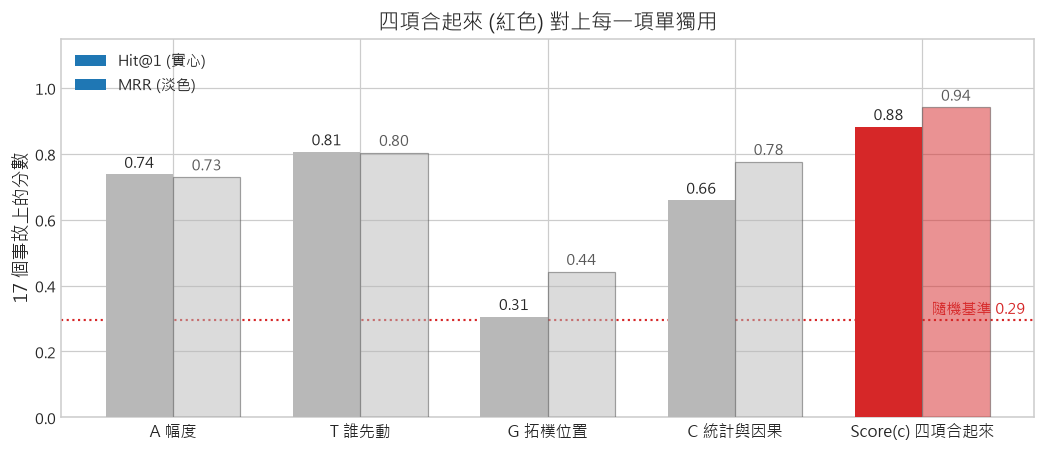

In [11]:
# 🎯 每一項單獨排一次名，跟四項合起來排的結果比。用 Hit@1、MRR 與隨機基準三個數字。
#    這一格沒有可調參數: 權重就是上一格的 W，四項證據也都算好了，這裡只是換一欄來排名。
#    「換一項證據來排名」在程式裡就只是換一個欄名。

# ---- 1. 隨機基準: 五個候選，而且兩個 MULTI 事件任何 port 都算對 ----
#         沒有先畫這條線的話，0.45 看起來像很差，其實只比亂猜好一點。
rand = float(np.mean([1 / len(ALL_PORTS) if ev.port_id != "MULTI" else 1.0
                      for _, ev in events.iterrows()]))


def eval_by(rk, term, ev):
    """用某一欄排名，換算成 (Hit@1, RR)。

    平手一律給平均名次 (hit_mrr 已經處理)。這一步是整格最關鍵的地方: 直接 sort_values
    的話，平手的順序會沿用「已經照 Score(c) 排好」的原始順序，等於把融合後的名次帶進
    單項的分數，單項的成績會被灌高。"""
    return hit_mrr(rk.set_index("port_id")[term].astype(float), true_ports(ev))


# 四項合起來的成績，逐事故一列。後面匯出 CSV 時也要用這一份。
ev_df = pd.DataFrame([{"incident": ev.event_id,
                       "rank_of_true": float(min(
                           rank_candidates_cached(ev)[0]
                           .set_index("port_id")["rank"][p] for p in true_ports(ev))),
                       }
                      for _, ev in events.iterrows()])
ev_df["hit@3"] = (ev_df["rank_of_true"] <= 3).astype(int)

# ---- 2. 先看表: 前四列各用一欄單項證據排名，最後一列用合成好的 score 欄 ----
#         每一輪都跑完全部 17 個事故再取平均。
rows = []
for term, label in [("A", "A 幅度"), ("T", "T 誰先動"), ("G", "G 拓樸位置"),
                    ("C", "C 統計與因果"), ("score", "Score(c) 四項合起來")]:
    per = [eval_by(rank_candidates_cached(ev)[0], term, ev) for _, ev in events.iterrows()]
    rows.append({"排法": label,
                 "Hit@1": float(np.mean([h for h, _ in per])),
                 "MRR": float(np.mean([r for _, r in per]))})
fuse = pd.DataFrame(rows)

_show = fuse.copy()
_show["Hit@1"] = _show["Hit@1"].map("{:.2f}".format)
_show["MRR"] = _show["MRR"].map("{:.2f}".format)
# 隨機基準的 MRR 那一格寫 "-": rand 算的是猜中第一名的機率，它沒有名次可以取倒數。
_show.loc[len(_show)] = ["隨機猜的基準", f"{rand:.2f}", "-"]
_show = _show.set_index("排法")
_show.index.name = f"單項證據對四項合起來 (全部 {len(events)} 個事故)"
display(_show)

# ---- 3. 再看圖: 兩個指標並排，虛線是隨機基準 ----
#         配色只留一個重點: 前四個排法全部灰色，最後一個「四項合起來」用強調色。
fig, ax = plt.subplots(figsize=(9.6, 4.2), dpi=110)
xx = np.arange(len(fuse))
wd = 0.36
cols = ["0.72"] * (len(fuse) - 1) + [ACC]
ax.bar(xx - wd / 2, fuse["Hit@1"], wd, color=cols, zorder=3)
ax.bar(xx + wd / 2, fuse["MRR"], wd, color=cols, alpha=0.5, zorder=3,
       edgecolor="0.3", linewidth=0.8)
for x, (h, m) in enumerate(zip(fuse["Hit@1"], fuse["MRR"])):
    ax.text(x - wd / 2, h + 0.02, f"{h:.2f}", ha="center", fontsize=10)
    ax.text(x + wd / 2, m + 0.02, f"{m:.2f}", ha="center", fontsize=10, color="0.35")
ax.axhline(rand, color=ACC, ls=":", lw=1.4)
ax.text(len(fuse) - 0.45, rand + 0.02, f"隨機基準 {rand:.2f}", ha="right", fontsize=10,
        color=ACC)
ax.bar([], [], color="0.5", label="Hit@1 (實心)")            # 兩根空長條只是為了圖例
ax.bar([], [], color="0.5", alpha=0.5, edgecolor="0.3", label="MRR (淡色)")
ax.legend(fontsize=10, loc="upper left", frameon=False)
ax.set_xticks(xx); ax.set_xticklabels(fuse["排法"], fontsize=10.5)
ax.set_ylim(0, 1.15)                                        # 上限是 1.00，留白給數字標籤
ax.set_ylabel(f"{len(events)} 個事故上的分數", fontsize=11.5)
ax.set_title("四項合起來 (紅色) 對上每一項單獨用", fontsize=13.5)
plt.tight_layout()
show_fig(fig)


---

## 這些參數是不是調出來的

前面五節每一節都有幾個自己設的參數。上課最常被問的一句是「這些數字是不是你配著這份資料調出來的」,所以這裡把它們各掃一遍，用同一組 17 個事故量 Hit@1 與 MRR。**看的是兩件事: 這個參數會不會換掉答案，以及這一章用的值是站在一片高原上還是一個尖峰上。**


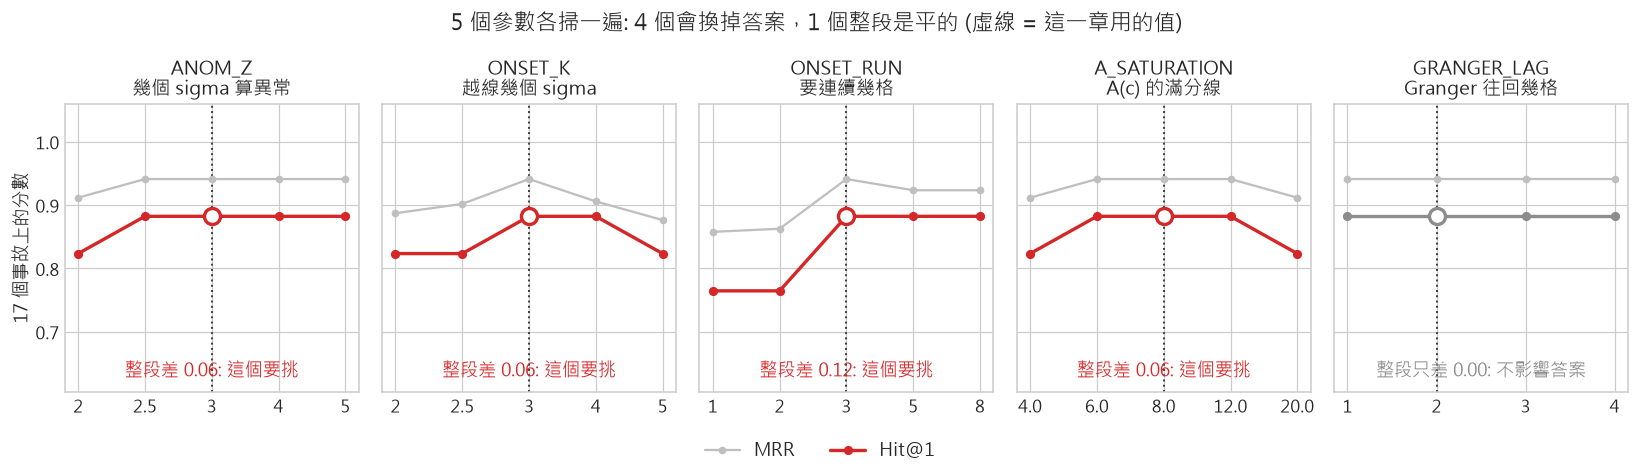

,這一章用的值,掃描範圍,Hit@1 最差到最好,這個值站得穩嗎,結論
參數,,,,,
ANOM_Z,3.0,2 到 5,0.82 到 0.88,在最高的那一段，而且不只它一個,要自己挑
ONSET_K,3.0,2 到 5,0.82 到 0.88,在最高的那一段，而且不只它一個,要自己挑
ONSET_RUN,3.0,1 到 8,0.76 到 0.88,在最高的那一段，而且不只它一個,要自己挑
A_SATURATION,8.0,4.0 到 20.0,0.82 到 0.88,在最高的那一段，而且不只它一個,要自己挑
GRANGER_LAG,2.0,1 到 4,0.88 到 0.88,整段都一樣,照抄就好


In [12]:
# 🎯 參數敏感度: 前面五節每一個參數，改掉它會不會換掉答案。
#    這一格不引進任何新方法。它把每個參數各掃一遍，每一組設定都把 17 個事故重排一次,
#    量 Hit@1 與 MRR。要回答的是上課一定會被問的那一句:「這些數字是不是你調出來的?」

# ============ ⚙️ 可調參數 ============
# 參數名 -> 要掃的值。目前用的那個值一定要在清單裡，圖上才標得出來。
SWEEP = {"ANOM_Z":       [2, 2.5, 3, 4, 5],
         "ONSET_K":      [2, 2.5, 3, 4, 5],
         "ONSET_RUN":    [1, 2, 3, 5, 8],
         "A_SATURATION": [4.0, 6.0, 8.0, 12.0, 20.0],
         "GRANGER_LAG":  [1, 2, 3, 4]}
SWEEP_TITLE = {"ANOM_Z": "ANOM_Z\n幾個 sigma 算異常",
               "ONSET_K": "ONSET_K\n越線幾個 sigma",
               "ONSET_RUN": "ONSET_RUN\n要連續幾格",
               "A_SATURATION": "A_SATURATION\nA(c) 的滿分線",
               "GRANGER_LAG": "GRANGER_LAG\nGranger 往回幾格"}
FLAT_EPS = 0.02          # Hit@1 整段掃描的落差小於這個數，就當作「這個參數不影響答案」
# 有些參數在別的地方被抄成另一個名字 (RANK_Z 與 CTX_Z 都是照 ANOM_Z 設的) 。抄過去的是
# 數值不是參照，所以掃描的時候要一起換，不然掃了半天其實只換到其中一個。
ALIAS = {"ANOM_Z": ["RANK_Z", "CTX_Z"]}   # CTX_Z 要等後面那一節才存在，不存在就跳過
# ====================================


# ---- 1. 掃一個參數: 換一個值就把 17 個事故整個重排一次 ----
#         _rank_cache 一定要清掉，不然第二個值拿到的是第一個值算好的排名。
#         算完把原值放回去，這一格跑完之後整本 notebook 的狀態跟跑之前一模一樣。
def sweep_one(name, values):
    # CTX_Z 在後面那一節才定義，這一格跑到的時候還不存在，所以只換已經有的名字。
    names = [n for n in [name] + ALIAS.get(name, []) if n in globals()]
    keep = {n: globals()[n] for n in names}
    out = []
    for v in values:
        for n in names:
            globals()[n] = v
        _rank_cache.clear()
        per = [eval_by(rank_candidates_cached(ev)[0], "score", ev)
               for _, ev in events.iterrows()]
        out.append((v, float(np.mean([h for h, _ in per])),
                    float(np.mean([r for _, r in per]))))
    globals().update(keep)
    _rank_cache.clear()
    return keep[name], out


# ---- 2. 五個參數各掃一遍 ----
SENS = {name: sweep_one(name, vals) for name, vals in SWEEP.items()}


# ---- 3. 一個參數一格小圖，五格共用同一個 y 軸 ----
#         共用 y 軸是這張圖的重點: 沒有拉成同一個尺度的話，一條完全沒動的線也會
#         因為自動縮放而看起來起伏很大，五格就沒辦法互相比較。
fig, axes = plt.subplots(1, len(SWEEP), figsize=(15.0, 3.9), dpi=110, sharey=True)
lo = min(h for _, rows in SENS.values() for _, h, _ in rows)
for ax, (name, (cur, rows)) in zip(axes, SENS.items()):
    xs = list(range(len(rows)))
    hit = [h for _, h, _ in rows]
    mrr = [m for _, _, m in rows]
    span = max(hit) - min(hit)
    flat = span < FLAT_EPS
    ax.plot(xs, mrr, color="0.75", lw=1.5, marker="o", ms=4, zorder=3, label="MRR")
    ax.plot(xs, hit, color=(GREY if flat else ACC), lw=2.2, marker="o", ms=5, zorder=4,
            label="Hit@1")
    i_cur = [i for i, (v, _, _) in enumerate(rows) if v == cur][0]
    ax.axvline(i_cur, color=INK, ls=":", lw=1.3, zorder=2)        # 這一章用的那個值
    ax.scatter([i_cur], [hit[i_cur]], s=110, facecolor="white",
               edgecolor=(GREY if flat else ACC), linewidth=2.2, zorder=6)
    ax.set_xticks(xs); ax.set_xticklabels([str(v) for v, _, _ in rows], fontsize=11.5)
    ax.set_title(SWEEP_TITLE[name], fontsize=12.5)
    ax.tick_params(labelsize=11)
    ax.text(0.5, 0.055, ("整段只差 %.2f: 不影響答案" % span) if flat
            else ("整段差 %.2f: 這個要挑" % span),
            transform=ax.transAxes, ha="center", fontsize=11.5,
            color=(GREY if flat else ACC))
axes[0].set_ylabel("17 個事故上的分數", fontsize=12)
axes[0].set_ylim(max(0.0, lo - 0.16), 1.06)
# 圖例放在整張圖下面，不放在第一格裡面: 放進去會壓到那一格底下的結論字。
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=2, fontsize=11.5,
           framealpha=0.95)
# 標題照掃出來的結果寫，不要寫死: 換一份資料重跑，這句話要跟著變。
_n_move = sum(1 for _, rows in SENS.values()
              if max(h for _, h, _ in rows) - min(h for _, h, _ in rows) >= FLAT_EPS)
fig.suptitle(f"{len(SENS)} 個參數各掃一遍: {_n_move} 個會換掉答案，"
             f"{len(SENS) - _n_move} 個整段是平的 (虛線 = 這一章用的值) ", fontsize=14.5)
plt.tight_layout()
show_fig(fig)


# ---- 4. 同一件事寫成一張表，方便照抄回自己的系統 ----
display(pd.DataFrame(
    [{"參數": n, "這一章用的值": c,
      "掃描範圍": f"{rows[0][0]} 到 {rows[-1][0]}",
      "Hit@1 最差到最好": f"{min(h for _, h, _ in rows):.2f} 到 {max(h for _, h, _ in rows):.2f}",
      # 落在最高的那一段而且不只一個值並列，代表這個值是一片高原不是一個尖峰。
      # 只有單獨一個值最好的話，那通常是配著這份資料調出來的，換一份就不成立。
      "這個值站得穩嗎": ("整段都一樣" if max(h for _, h, _ in rows) - min(h for _, h, _ in rows) < FLAT_EPS
                        else ("在最高的那一段，而且不只它一個" 
                              if sum(1 for _, h, _ in rows if h >= max(hh for _, hh, _ in rows) - 1e-9) > 1
                                 and next(h for v, h, _ in rows if v == c) >= max(hh for _, hh, _ in rows) - 1e-9
                              else "只有它最高，換一份資料要重挑")),
      "結論": ("要自己挑" if max(h for _, h, _ in rows) - min(h for _, h, _ in rows) >= FLAT_EPS
               else "照抄就好")}
     for n, (c, rows) in SENS.items()]).set_index("參數"))

---

## 接上 LLM: 六個步驟

```mermaid
flowchart LR
    M1["照直覺查一遍<br/>用幅度排"] --> M2["四種證據<br/>位置、關聯<br/>時序、可預測性"] --> M3["合成一個排名<br/>Score(c)"] --> M4["LLM 架構<br/>打包 context<br/>檢索領域知識"] --> M5["LLM 診斷<br/>與驗證"] --> M6["換產業、換檢索<br/>回饋迴路與上線"]
    style M4 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### 底下這六步是上面 M4 到 M6 的細部，跟前面「四種證據」底下那四步是同一種畫法。

```mermaid
flowchart LR
    S1["1 打包<br/>四項證據收成 context"] --> S2["2 檢索<br/>BM25 撈出 K(c)"] --> S3["3 送進 LLM"] --> S4["4 讀模型寫回來的診斷"] --> S5["5 驗證<br/>跟 Score(c) 比"] --> S6["6 換產業<br/>與回饋迴路"]
    style S1 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### 分數只能用來排名，接上 LLM 是為了補三件排名做不了的事:

- **排名說不出「為什麼」。** `Score(c)` 是四個數字加起來，它交不出一段人看得懂、而且每一句都指得回某一欄證據的說明
- **排名說不出「有多不確定」。** 工具其實算得出反面的證據 (第一名只贏第二名幾分、哪一項證據算不出來),但那些東西沒有進到名次裡
- **排名看不到領域知識。** 它只看得到時間序列與一張依賴圖，看不到這個客戶的處置手冊與歷史工單

#### LLM 送進去的東西只有兩塊

```mermaid
flowchart LR
    S1["前五節算出來的<br/>z 矩陣、拓樸、關聯<br/>onset、可預測性"] --> CTX["一份 RCA context"]
    KB["這個客戶的知識包<br/>拓樸、處置手冊、歷史工單"] --> RET["BM25 檢索"] -->|"撈回來的那幾段就是 K(c)"| CTX
    CTX --> LLM["LLM"]
    LLM --> OUT["一份可稽核的診斷<br/>摘要、假設、支持、反對<br/>傳播路徑、缺什麼、下一步、處置"]
    style CTX fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

**一半是算出來的，一半是查出來的。** 
- 演算法只產得出前面那一半，因為它讀的是 metric 與依賴圖
- 後面那一半在文件裡，得去撈。**這兩塊包好就直接送進模型

**打包的原則是「最強的訊號、最少的欄位」。** 整條時間序列丟進去只會把真正的證據稀釋掉: 模型讀到的 95% 是它用不上的取樣點，而真正決定答案的那幾個數字被埋在裡面。所以送進去的每一欄都是**已經算完的結論**,不是原始資料。


,這份 context 實際的內容 (事故 L，optical_degradation_failover),子欄位,內容
0,incident_id,,L
1,time_window,,2026-03-02 14:00 → 17:55
2,duration_min,,235
3,window_samples,,48
4,onset_distinct_slots,,3
5,ranking_margin,,24.71
6,signature_metric,,error_rate
7,affected_ports,0,port-id7427
8,affected_ports,1,port-id7429
9,affected_ports,2,port-id7431



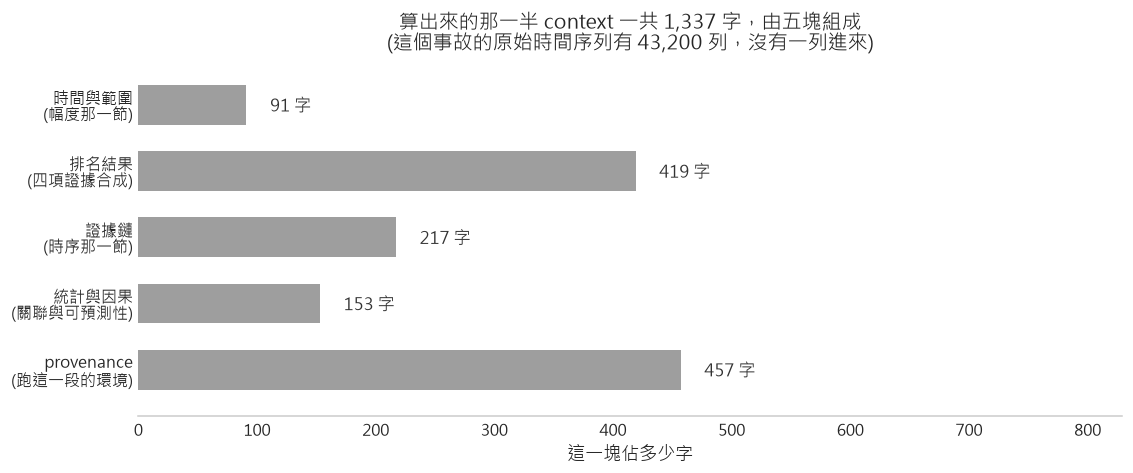

In [13]:
# 🎯 第一塊: 把五節算出來的數字收成一份結構化的 context，含 provenance 六欄。

# ============ ⚙️ 可調參數 ============
CTX_TOP_N = 3      # context 的排名只放前幾名。放 1 的話模型看不到第二名的分數，
                   # 就沒有東西可以算「贏多少」
CTX_CHAIN_N = 4    # 證據鏈最多放幾步。砍到 2 的話，後面才越線的元件不會出現在路徑上
CTX_Z = ANOM_Z     # 幅度上偏離幾個標準差才算「有異常」，決定 affected_ports 列出哪幾個。
                   # 同樣指回 ANOM_Z: 送進 LLM 的異常集合，跟排名用的必須是同一個定義。
                   # 這裡的 3 不是重新挑的: 排名那一格算 G(c) 時用同一個門檻決定異常集合，
                   # context 與排名必須是同一組 port，要改就兩邊一起改
# ====================================


# ---- 1. 證據鏈: 一行一步，照時間排 ----
#         它是 context 裡唯一一塊「有先後」的欄位，其餘欄位都是整段窗一個值。
def evidence_chain(ev, onset):
    """可稽核的證據鏈，一行一步，照時間排。沒有越線的 port 不會出現在上面。

    每一步帶四件事: 時刻、port、它屬於哪一台設備、看的是哪一個指標。"""
    metric = signature_metric(ev.event_type)
    items = sorted([(t, p) for p, t in onset.items() if t is not None])
    return [f"{t:%m-%d %H:%M}  {p} ({PORT_DEVICE[p]}) 的 {metric} 偏離同時段常態超過 {ONSET_K} sigma"
            for t, p in items]


# ---- 2. 打包: 每一塊都指名它是從哪一節算出來的，而且全部走快取不重算 ----
#         所以 context 裡的每一個數字都跟前面圖上看到的完全一樣。
def build_context(ev):
    """把五節的產物收成一個 dict，也就是等一下要送進模型的那一份 context。

    每一個鍵一欄，值全部是已經算完的結論，不是原始資料: 整條時間序列丟進去只會把真正
    的證據稀釋掉。"""
    rank, onset = rank_candidates_cached(ev)
    z = window_zscores(ev.start_time, ev.end_time)
    metric = signature_metric(ev.event_type)
    anomalous = [p for p in ALL_PORTS if abs(z.loc[p, metric]) > CTX_Z]
    top = rank.iloc[0]
    # 跨 port 同步度: 五個 port 兩兩相關的平均 (取非對角線)。它只是一個「大家有多一起動」
    # 的摘要，給模型判斷扇出的規模，不是排名用的證據。
    corr = cross_port_corr(metric, ev.start_time, ev.end_time)
    if len(corr) > 1:
        vals_ = corr.values[~np.eye(len(corr), dtype=bool)]
        mean_offdiag = float(np.nanmean(vals_)) if np.isfinite(vals_).any() else 0.0
    else:
        mean_offdiag = 0.0
    st = rank.attrs["status"].get(top.port_id, {})
    onset_slots = len({v for v in onset.values() if v is not None})
    n_samp = len(feat_by_port[ALL_PORTS[0]].loc[ev.start_time:ev.end_time])
    return {
        "incident_id": ev.event_id,
        "time_window": f"{ev.start_time:%Y-%m-%d %H:%M} → {ev.end_time:%H:%M}",
        "duration_min": int((ev.end_time - ev.start_time).total_seconds() // 60),
        "window_samples": n_samp,
        "onset_distinct_slots": onset_slots,
        # ranking_margin = 第一名的分數減第二名。模型拿它判斷「第一名贏得夠不夠多」，
        # 差距小就要在診斷裡講保留。兩個 round 過的分數相減會留下浮點誤差，所以收成兩位。
        "ranking_margin": round(float(rank.score.iloc[0] - rank.score.iloc[1]), 2),
        "signature_metric": metric,
        "affected_ports": anomalous,
        "cross_port_synchrony": round(mean_offdiag, 2),
        "top_candidate": {"port_id": top.port_id, "device_id": top.device_id,
                          "z_signature": top.z_signature, "score": top.score},
        "ranking": rank[["rank", "port_id", "z_signature", "onset", "score"]].head(CTX_TOP_N).to_dict("records"),
        "evidence_chain": evidence_chain(ev, onset)[:CTX_CHAIN_N],
        # 統計與因果證據，連同「這一項到底算不算得出來」一起交出去。
        # unavailable 不是 0: 前者是沒得算，後者是算了沒有，對信心的意義完全不同。
        "statistical_causal_evidence": {
            "pearson": {"value": float(top.C_assoc), "status": st.get("assoc", "zero")},
            "granger": {"value": float(top.C_granger), "status": st.get("granger", "zero")},
            "co_occurrence": {"value": float(top.C_cooc), "status": st.get("cooc", "zero")},
        },
        # Provenance: 每一項證據都要能被重跑一次。沒有這一段，診斷就不可稽核。
        # 「模型版本」把每一個可調參數寫進字串，所以只要動過任何一個，這一欄就會跟著變。
        "provenance": {
            "資料來源": str(RRD_CSV.relative_to(PROJECT_ROOT)),
            "時間戳記": f"{ev.start_time:%Y-%m-%dT%H:%M} 到 {ev.end_time:%H:%M}"
                        f" (基線={baseline_stats(top.port_id, ev.start_time, ev.end_time)[2]})",
            "查詢條件": f"port in {ALL_PORTS}, metric={metric}, 取樣 5min",
            "資料版本": f"{len(features):,} 列，{features.timestamp.min():%Y-%m-%d} 起 30 天",
            "轉換與聚合": "RRD 累積計數器 -> Lab 01 語意特徵 -> 對同時段歷史基線的 z "
                          "(平均偏離除以分槽合併標準差，排程視窗已剔除)",
            "模型版本": f"Score(c) 權重 w={W}，onset k={ONSET_K}/run={ONSET_RUN}，"
                        f"Granger {GRANGER_RULE}/lag={GRANGER_LAG}，Bonferroni alpha={ALPHA:.4f}",
        },
    }


# ---- 3. 把一層套一層的 dict 攤成三欄的表 ----
#         步驟四那一格印模型的診斷也是呼叫它，兩份 JSON 才會排成同一種樣子。
def dict_table(d, first_col):
    """把一層套一層的 dict 攤成三欄的表 (欄位、子欄位、內容)，才不用讀一整段 JSON。"""
    flat = lambda v: (json.dumps(v, ensure_ascii=False, default=str)
                      if isinstance(v, (dict, list)) else str(v))
    rows = []
    for k, v in d.items():
        if isinstance(v, dict):
            rows += [(k, k2, flat(v2)) for k2, v2 in v.items()]
        elif isinstance(v, list):
            rows += [(k, str(j), flat(v2)) for j, v2 in enumerate(v)] or [(k, "", "(空)")]
        else:
            rows.append((k, "", flat(v)))
    return pd.DataFrame(rows, columns=[first_col, "子欄位", "內容"])


# ---- 4. 17 個事故各包一份 ----
contexts = {ev.event_id: build_context(ev) for _, ev in events.iterrows()}
CTX = contexts[INCIDENT.event_id]

# ---- 5. 先看表: 這份 context 實際的內容 ----
display(dict_table(CTX, f"這份 context 實際的內容 (事故 {INCIDENT.event_id}，{INCIDENT.event_type})"))

# ---- 6. 再看圖: 這份 context 由哪幾塊組成、每一塊佔多少字 ----
#         量字數而不是量欄位數，是因為送進模型的成本是照字數算的。
BLOCKS = [                    # (要畫的塊名, 這一塊包含哪幾個 key, 這一塊是哪一節算出來的)
    ("時間與範圍", ["incident_id", "time_window", "duration_min", "window_samples",
                    "signature_metric", "affected_ports"], "幅度那一節"),
    ("排名結果", ["top_candidate", "ranking", "ranking_margin"], "四項證據合成"),
    ("證據鏈", ["evidence_chain", "onset_distinct_slots"], "時序那一節"),
    ("統計與因果", ["statistical_causal_evidence", "cross_port_synchrony"], "關聯與可預測性"),
    ("provenance", ["provenance"], "跑這一段的環境"),
]
blk_chars = [sum(len(json.dumps(CTX[k], ensure_ascii=False, default=str)) for k in ks)
             for _, ks, _ in BLOCKS]

fig, ax = plt.subplots(figsize=(10.4, 4.4), dpi=110)
total_chars = int(sum(blk_chars))
yy = np.arange(len(BLOCKS))[::-1]
ax.barh(yy, blk_chars, height=0.6, color="0.62", zorder=3)
for y, n in zip(yy, blk_chars):
    ax.text(n + total_chars * 0.015, y, f"{n} 字", va="center", fontsize=11, color="0.2")
ax.set_yticks(yy)
ax.set_yticklabels([f"{name}\n({src})" for name, _, src in BLOCKS], fontsize=10.5)
ax.set_xlim(0, total_chars * 0.62)      # 最長的一塊也不到這個長度，多的空白留給「n 字」
ax.set_ylim(-0.7, len(BLOCKS) - 0.3)
ax.grid(False)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.set_xlabel("這一塊佔多少字", fontsize=12)
ax.tick_params(labelsize=10.5)
ax.set_title(f"算出來的那一半 context 一共 {total_chars:,} 字，由五塊組成\n"
             f"(這個事故的原始時間序列有 {len(feat_by_port[ALL_PORTS[0]]) * len(ALL_PORTS):,} 列，"
             f"沒有一列進來)", fontsize=13)
plt.tight_layout()
show_fig(fig)


### 小提醒

**五塊加起來一千三百多個字，而原始時間序列有四萬三千多列，沒有一列進來。** 這就是「最強的訊號、最少的欄位」的實際比例。圖上每一塊的括號寫的是它從哪一節算出來的，所以表上的每一個數字都翻得回前面的圖。

**最大的兩塊是排名結果與 provenance,加起來佔了六成五。** 真正的證據 (統計與因果那一塊) 只有 153 字。這個比例是對的: 模型需要的是結論與它的出處，不是原始數據。

**provenance 那六欄是最不像證據、但最重要的一塊。** 三個月後有人問「當初為什麼判成光路劣化」,要能拿著這六欄把同一份資料、同一組參數再跑一次，得到同一個答案。少了它，這份診斷讀起來有說服力，但沒有人驗得了。**理論課把它列在「找得可信」那個構面底下，跟人工接受度、證據品質並列。**

**證據鏈那一塊就是理論課那張圖的形狀。** 一步一個時間、一個元件、一個指標，照時間排好，最後指向一個根因候選:

<p align="center"><img src="slides/u08_evidence_chain.png" width="80%" alt="單元 08 的證據鏈投影片: 一條按時間排序的證據鏈，每一步帶時間、元件、指標與異常標記，最後收斂到一個根因候選，並標出 Upstream Origin、Earliest Anomaly、Best Explanation 三個判準"></p>


---

## 步驟二: 用 BM25 把領域知識 $K(c)$ 檢索進來

```mermaid
flowchart LR
    S1["1 打包<br/>四項證據收成 context"] --> S2["2 檢索<br/>BM25 撈出 K(c)"] --> S3["3 送進 LLM"] --> S4["4 讀模型寫回來的診斷"] --> S5["5 驗證<br/>跟 Score(c) 比"] --> S6["6 換產業<br/>與回饋迴路"]
    style S2 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### RAG (Retrieval-Augmented Generation) 一句話講完: **先查資料，再讓 LLM 根據查到的資料回答。**

理論課那張補充投影片把它跟「直接問」擺在一起比:


$A$、$T$、$G$、$C$ 是算出來的，$K(c)$ 是查出來的，這就是它沒有進排名的原因: 它不是一個 0 到 1 的分數，但它進得了 context,而且進去之後模型才講得出元件的名字與該做的處置。

<p align="center"><img src="slides/u08_rag.png" width="80%" alt="單元 08 的檢索增強生成投影片: 直接問 LLM 時它未必知道企業內部知識，可能回答不準確或產生不存在的內容; 使用 RAG 先找到公司的維修手冊與歷史案例再回答，答案更可靠、有依據; 底下是 Retrieval 檢索、Augmentation 補充、Generation 生成三個步驟"></p>


#### 這一章的檢索用 BM25

**講義把常見的檢索方式並列成四種，這一章用的是第一種 Keyword Retrieval，它底下裝的就是 BM25。** 理論在簡報上，這裡只帶過三件事，下一格的程式就是照它們寫的:

- 一個詞在一篇文件裡出現越多次分數越高，但會**飽和**: 第二次加的分比第一次少
- **長文件不會因為篇幅長就贏**，長度那一項會把它的每一筆貢獻往下修
- **每一篇都有的詞幾乎不加分** (IDF)，只有少數文件才有的詞才有鑑別力

另外三種這一章不做: Vector 要建向量庫與下載模型、Graph 要先有一張知識圖譜、Hybrid 要先有前兩種才談得上。**「查」這一步有一條規矩: 一個詞都沒命中就是沒撈到**，不可以回傳一篇 BM25 分數是 0 的文件。

> **中文沒有空格，所以這一章不做分詞。** 查詢詞是知識包自己的詞彙，直接用字串比對數出現次數。正式環境接的是搜尋引擎，分詞與索引由它處理。

<p align="center"><img src="slides/u08_rag_methods.png" width="80%" alt="單元 08 的 RAG 方法投影片: 多路徑檢索把 Keyword Retrieval (BM25)、Vector Retrieval、Graph Retrieval 與 Hybrid Retrieval 四種方式並列，各自的檢索流程與例子; 右邊是候選證據池、Reranking 重排序、Top-k 證據、LLM 生成與推理、輸出"></p>

**下一格分三段跑**: 先把知識包的四篇全文攤開、標上「這次事故用不用得到」(這一欄是出題的時候標的，BM25 看不到)，再印出從證據組出來的查詢字串，最後才讓 BM25 真的跑一次，看它撈回來的跟標記對不對得上。

,類型,全文 (BM25 只讀得到這一欄),人工標記 (出題時標的)
知識包裡的四篇文件,,,
NET-STRUCT-1,structure,對外主線 port-id7427 經 edge-fw-01 與 core-sw-01 連到主機群 uplink 與備份儲存，屬於現用路徑；port-id7428 是備援線，不掛現用下游。,○ 有關但這次不必要: 拓樸文件，說明對外主線接到哪些下游; 這次的證據已經帶了誰先偏離
NET-RUN-1,runbook,上游鏈路光功率衰減 (optical power degradation) 會造成 CRC 錯誤上升，下游因為 TCP 重傳與佇列堆積而流量放大。處置: 讀 SFP 收發光功率、檢查主備切換紀錄與 CRC 計數器、確認下游重傳是否跟著上游錯誤率走。,★ 這次事故的答案在這裡: 光衰 → CRC 錯誤 → 下游重傳放大，機制與處置都寫在這一篇
NET-RUN-2,runbook,廣播風暴的處置: 檢查 STP 狀態、找出最近新增的 port 或 VLAN 變更、在接取層啟用 PortFast 與 BPDU Guard。,× 完全無關: 廣播風暴是另一種故障模式，跟上游光衰沒有關係
NET-HIST-1,history,工單 2025-11-03: 對外主線光衰造成下游重傳，錯誤率先升約 45 分鐘後下游流量才抬起來，更換 SFP 模組後恢復。,★ 這次事故的答案在這裡: 同型事故的歷史工單，連上下游相隔幾十分鐘都對得上


,內容
事故 L 的查詢,
組出來的查詢字串,上游 錯誤率 error_rate 劣化 造成 下游 放大 延遲 40 分鐘 上游先偏離 下游後偏離
實際切出來的查詢詞 (12 個),上游、錯誤率、error_rate、劣化、造成、下游、放大、延遲、40、分鐘、上游先偏離、下游後偏離


,BM25 分數,命中的查詢詞,檢索結果,人工標記
BM25 跑完之後 (照分數排),,,,
NET-RUN-1,4.15,上游、錯誤率、造成、下游、放大,撈回來，進 K(c),★ 這次事故的答案在這裡
NET-HIST-1,3.53,錯誤率、造成、下游、分鐘,撈回來，進 K(c),★ 這次事故的答案在這裡
NET-STRUCT-1,0.35,下游,沒撈回來,○ 有關但這次不必要
NET-RUN-2,0.00,一個詞都沒命中,沒撈回來,× 完全無關



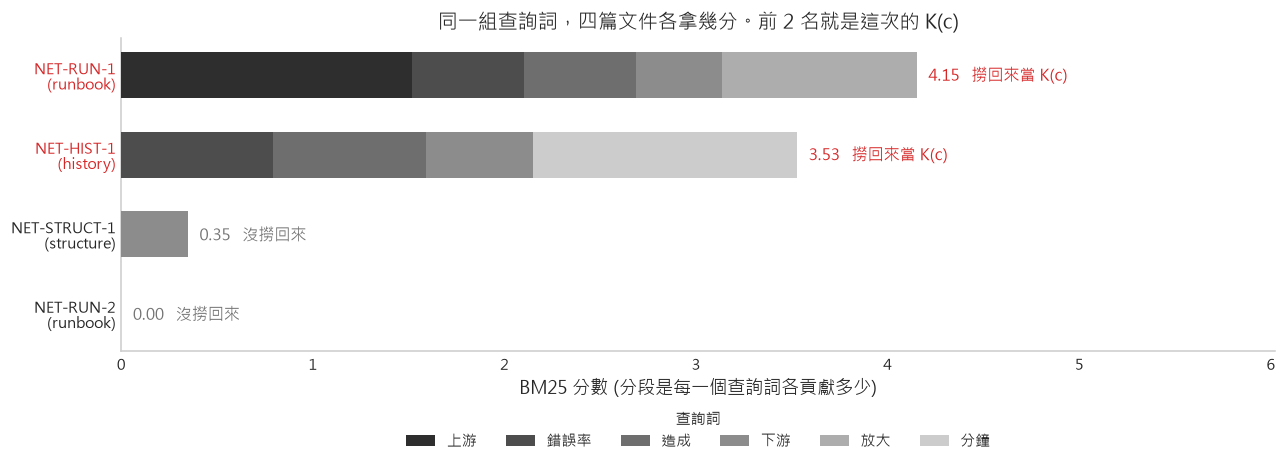

In [14]:
# 🎯 知識包四篇全文、這次組出來的查詢、以及 BM25 真的撈回來哪幾篇。

# ============ ⚙️ 可調參數 ============
BM25_K1, BM25_B = 1.5, 0.75   # K1 控制「同一個詞出現很多次」的飽和速度 (0 就是只看有沒有
                              # 命中)，B 控制「長文件要不要扣分」(0 完全不管長度)。
                              # 兩個都是文獻上的預設值，不是這份資料調出來的
RETRIEVE_K = 2                # 最多把幾篇文件當成 K(c) 送進 context。
                              # 調小 (1): 只留分數最高的那一篇，它如果是歷史工單，
                              #   這次就沒有 runbook 可以切出處置
MIN_TERM_LEN = 2              # 查詢詞至少要幾個字才算數。設 1 的話中文單字 (「的」「先」)
                              # 也會變成查詢詞，它們幾乎每篇都有，IDF 接近 0
# KNOWLEDGE_PACKS: 換客戶、換產業要改的是這個 dict，不是下面的檢索程式。
#   每一篇文件都帶 kind，對應理論課知識圖譜的三類來源:
#   structure = 系統如何連接、runbook = 處理流程與故障模式、history = 歷史事件紀錄。
#   兩包的結構刻意做成一模一樣，所以同一份證據換一包就能用另一個產業的詞講出來。
#   注意 IDF 是相對於整包算的，所以加減文件會讓所有文件的分數都變，不同大小的知識包
#   之間不要互相比 BM25 分數，只在同一包裡比名次。
KNOWLEDGE_PACKS = {
    "network_ops": {
        "描述": "網路維運: 交換器、防火牆、光纖鏈路、port 層的流量與錯誤計數、TCP 重傳與佇列",
        "元件對照": {"U": "port-id7427 (對外主線)", "D1": "port-id7429 (主機群 uplink)",
                     "D2": "port-id7431 (備份儲存)"},
        "指標對照": "錯誤率 error_rate",
        "文件": [
            {"id": "NET-STRUCT-1", "kind": "structure",
             "text": "對外主線 port-id7427 經 edge-fw-01 與 core-sw-01 連到主機群 uplink 與備份儲存，"
                     "屬於現用路徑；port-id7428 是備援線，不掛現用下游。"},
            {"id": "NET-RUN-1", "kind": "runbook",
             "text": "上游鏈路光功率衰減 (optical power degradation) 會造成 CRC 錯誤上升，"
                     "下游因為 TCP 重傳與佇列堆積而流量放大。處置: 讀 SFP 收發光功率、"
                     "檢查主備切換紀錄與 CRC 計數器、確認下游重傳是否跟著上游錯誤率走。"},
            {"id": "NET-RUN-2", "kind": "runbook",
             "text": "廣播風暴的處置: 檢查 STP 狀態、找出最近新增的 port 或 VLAN 變更、"
                     "在接取層啟用 PortFast 與 BPDU Guard。"},
            {"id": "NET-HIST-1", "kind": "history",
             "text": "工單 2025-11-03: 對外主線光衰造成下游重傳，錯誤率先升約 45 分鐘後下游流量才抬起來，"
                     "更換 SFP 模組後恢復。"},
        ],
    },
    "factory_maintenance": {
        "描述": "製造業設備維修: 變壓器、散熱器、冷卻水系統、油浸式潛水泵，以及維修手冊與歷史工單",
        "元件對照": {"U": "散熱器 (變壓器的散熱單元)", "D1": "變壓器本體繞組",
                     "D2": "冷卻水循環泵"},
        "指標對照": "散熱效率",
        "文件": [
            {"id": "FAB-STRUCT-1", "kind": "structure",
             "text": "變壓器主體包含散熱器、儲油槽、冷卻系統、軸襯與呼吸器；"
                     "散熱器接冷卻水系統，冷卻水系統再接循環泵。"},
            {"id": "FAB-RUN-1", "kind": "runbook",
             "text": "散熱器污垢堆積會使散熱效率下降 (heat dissipation degradation)，"
                     "接著造成本體繞組過熱與油溫上升。處置: 檢查散熱器是否有污垢或油泥堵塞、"
                     "清潔散熱器並檢查冷卻水流量、若問題持續則檢查冷卻水泵與軸襯狀況。"},
            {"id": "FAB-RUN-2", "kind": "runbook",
             "text": "呼吸器矽膠變色代表受潮，處置為更換乾燥劑並檢查密封。"},
            {"id": "FAB-HIST-1", "kind": "history",
             "text": "工單 2025-08-12: 散熱器污垢導致散熱效率下降，溫升訊號先出現約 40 分鐘後"
                     "本體油溫才跟上，清潔後恢復，成功修復率 78%。"},
        ],
    },
}
# ====================================


# ---- 1. BM25 本體 ----
#
#        BM25(q, d) = Σ_t  IDF(t) * [ f(t,d) * (k1 + 1) ]
#                                  / [ f(t,d) + k1 * (1 - b + b * |d| / avgdl) ]
#        IDF(t) = ln( 1 + (N - n_t + 0.5) / (n_t + 0.5) )
#
#      f(t,d) 用字串比對數出現次數，|d| 用字數，avgdl 是這一包文件的平均字數。
#      分母裡也有 f(t,d)，那就是飽和的來源。
def bm25_scores(terms, docs, k1=BM25_K1, b=BM25_B):
    """回傳 (每篇文件的總分, 每篇文件逐詞的分數)。兩個都回是為了讓分數指得出理由。"""
    N = len(docs)
    lens = [len(d["text"]) for d in docs]
    avgdl = sum(lens) / max(N, 1)
    idf = {t: float(np.log(1 + (N - sum(1 for d in docs if t in d["text"]) + 0.5)
                           / (sum(1 for d in docs if t in d["text"]) + 0.5)))
           for t in terms}
    total, per_term = {}, {}
    for d, dl in zip(docs, lens):
        parts = {}
        for t in terms:
            f = d["text"].count(t)
            if f == 0:
                continue
            denom = f + k1 * (1 - b + b * dl / max(avgdl, 1e-9))
            parts[t] = idf[t] * f * (k1 + 1) / denom
        per_term[d["id"]] = parts
        total[d["id"]] = float(sum(parts.values()))
    return total, per_term


def retrieve(query, pack, k=RETRIEVE_K):
    """算分、排序、砍掉一個詞都沒命中的，回傳最多 k 篇 (分數, 命中的詞, 文件)。

    不需要另外設一個分數下限: 一個詞都沒命中的文件 BM25 分數就是 0，這條規矩自己就成立。"""
    terms = [t for t in dict.fromkeys(query.split()) if len(t) >= MIN_TERM_LEN]
    total, per_term = bm25_scores(terms, pack["文件"])
    hits = [(total[d["id"]], list(per_term[d["id"]]), d) for d in pack["文件"]
            if total[d["id"]] > 0]
    return sorted(hits, key=lambda x: -x[0])[:k]


# ---- 2. 組查詢: 用算出來的證據描述事故的形狀，不是用人打的口語 ----
#         這一步跟產業無關: 它描述的是「上游一個溫和的劣化、下游被放大、中間隔一段延遲」。
#         詞與詞之間用空格隔開，因為 retrieve 是用 query.split() 切詞的。
def evidence_query(ev, pack):
    return (f"上游 {pack['指標對照']} 劣化 造成 下游 放大 "
            f"延遲 {ev['lag_min']} 分鐘 上游先偏離 下游後偏離")


# ---- 3. 把這一章的事故抽成一份「不含產業字眼」的證據 ----
#         U / D1 / D2 是角色代號，要對到哪個實體元件由知識包決定。
rank_L, onset_L = rank_candidates_cached(INCIDENT)
_top = rank_L.iloc[0]
_gap_min = int((onset_L["port-id7429"] - onset_L[INCIDENT.port_id]).total_seconds() // 60)
GENERIC_EVIDENCE = {
    "top_role": "U",                       # 排名第一的候選，位置在上游
    "downstream_roles": ["D1", "D2"],      # 下游而且有異常的元件
    "z_top": float(_top.z_signature),      # 上游那個品質指標偏離同時段常態幾個標準差
    "onset_order": ["U", "D1", "D2"],      # 誰先偏離
    "lag_min": _gap_min,                   # 上游越線到下游越線的間隔
    "margin": float(rank_L.score.iloc[0] - rank_L.score.iloc[1]),
}


# ---- 4. 檢索出 K(c)，並用檢索回來的知識把同一份證據講成那個產業聽得懂的話 ----
#         注意這個函式本身沒有任何一個網路或工廠的名詞，全部從 pack 來。
#         處置一律從檢索回來的 runbook 原文切出來，檢索不到就說沒有，不可以自己補一段。
def explain_with_pack(ev, pack_name, k=RETRIEVE_K):
    pack = KNOWLEDGE_PACKS[pack_name]
    hits = retrieve(evidence_query(ev, pack), pack, k=k)
    name = pack["元件對照"]
    downs = "、".join(name[r] for r in ev["downstream_roles"])
    runbook = next((d for _, _, d in hits if d["kind"] == "runbook"), None)
    history = next((d for _, _, d in hits if d["kind"] == "history"), None)
    return {
        "知識包": pack_name,
        "根因候選": name[ev["top_role"]],
        "受影響元件": downs,
        "診斷句": (f"{name[ev['top_role']]} 的 {pack['指標對照']} 先偏離同時段常態 "
                   f"(z={ev['z_top']:.1f})，{ev['lag_min']} 分鐘後 {downs} 才被放大。"
                   f"最嚴重的訊號在下游，觸發點在上游。"),
        "檢索到的知識 K(c)": [d["id"] for _, _, d in hits],
        "建議處置": (runbook["text"].split("處置:")[-1].strip()
                     if runbook and "處置:" in runbook["text"] else "知識包裡沒有對應的處置手冊"),
        "類似的歷史事件": history["id"] if history else "檢索不到類似的歷史工單",
    }


# ---- 5. 跑這一次: 四篇文件各拿幾分，前兩名就是 K(c) ----
PACK = KNOWLEDGE_PACKS["network_ops"]
QUERY = evidence_query(GENERIC_EVIDENCE, PACK)
QTERMS = [t for t in dict.fromkeys(QUERY.split()) if len(t) >= MIN_TERM_LEN]
BM_TOTAL, BM_PARTS = bm25_scores(QTERMS, PACK["文件"])
KC_L = explain_with_pack(GENERIC_EVIDENCE, "network_ops")
KEPT = set(KC_L["檢索到的知識 K(c)"])

# ---- 6. 先攤開整包: 四篇全文，以及出題的時候先標好的相關性 ----
#         GROUND_TRUTH 不在知識包裡，BM25 看不到它，它只讀得到 text 那一欄。
#         先把答案攤開來，等一下 BM25 跑完才有東西可以對。
GROUND_TRUTH = {
    "NET-STRUCT-1": ("○ 有關但這次不必要",
                     "拓樸文件，說明對外主線接到哪些下游; 這次的證據已經帶了誰先偏離"),
    "NET-RUN-1": ("★ 這次事故的答案在這裡",
                  "光衰 → CRC 錯誤 → 下游重傳放大，機制與處置都寫在這一篇"),
    "NET-RUN-2": ("× 完全無關",
                  "廣播風暴是另一種故障模式，跟上游光衰沒有關係"),
    "NET-HIST-1": ("★ 這次事故的答案在這裡",
                   "同型事故的歷史工單，連上下游相隔幾十分鐘都對得上"),
}
display(pd.DataFrame(
    [(d["kind"], d["text"], f"{GROUND_TRUTH[d['id']][0]}: {GROUND_TRUTH[d['id']][1]}")
     for d in PACK["文件"]],
    index=pd.Index([d["id"] for d in PACK["文件"]], name="知識包裡的四篇文件"),
    columns=["類型", "全文 (BM25 只讀得到這一欄)", "人工標記 (出題時標的)"]))

# ---- 7. 再看這一次拿去查的是什麼 ----
display(pd.DataFrame(
    [("組出來的查詢字串", QUERY),
     (f"實際切出來的查詢詞 ({len(QTERMS)} 個)", "、".join(QTERMS))],
    columns=[f"事故 {INCIDENT.event_id} 的查詢", "內容"]).set_index(
        f"事故 {INCIDENT.event_id} 的查詢"))

# ---- 8. 讓 BM25 真的跑一次: 撈回來的跟人工標記對不對得上 ----
_ranked = sorted(PACK["文件"], key=lambda d: -BM_TOTAL[d["id"]])
display(pd.DataFrame(
    [(f"{BM_TOTAL[d['id']]:.2f}",
      "、".join(BM_PARTS[d["id"]]) or "一個詞都沒命中",
      "撈回來，進 K(c)" if d["id"] in KEPT else "沒撈回來",
      GROUND_TRUTH[d["id"]][0])
     for d in _ranked],
    index=pd.Index([d["id"] for d in _ranked], name="BM25 跑完之後 (照分數排)"),
    columns=["BM25 分數", "命中的查詢詞", "檢索結果", "人工標記"]))

# ---- 9. 最後看圖: 一篇文件一根長條，分段是每一個查詢詞貢獻的分數 ----
#         分段是這張圖的重點: BM25 的分數指得出「是哪幾個詞撈回這一篇的」，
#         換成向量相似度這一欄只會是一個數字，沒有人指得出理由。
doc_ids = [d["id"] for d in PACK["文件"]]
order = sorted(doc_ids, key=lambda i: -BM_TOTAL[i])
used_terms = [t for t in QTERMS if any(t in BM_PARTS[i] for i in doc_ids)]
SHADES = [str(round(0.18 + 0.62 * j / max(len(used_terms) - 1, 1), 2)) for j in range(len(used_terms))]

fig, ax = plt.subplots(figsize=(11.8, 4.4), dpi=110)
yy = np.arange(len(order))[::-1]
left = np.zeros(len(order))
for t, sh in zip(used_terms, SHADES):
    vals_ = np.array([BM_PARTS[i].get(t, 0.0) for i in order])
    ax.barh(yy, vals_, left=left, height=0.58, color=sh, zorder=3, label=t)
    left += vals_
for y, i in zip(yy, order):
    ax.text(BM_TOTAL[i] + 0.06, y,
            f"{BM_TOTAL[i]:.2f}" + ("   撈回來當 K(c)" if i in KEPT else "   沒撈回來"),
            va="center", fontsize=10.5, color=ACC if i in KEPT else "0.45")
ax.set_yticks(yy)
# 標籤寫兩行: 文件 id 與它的 kind，因為「撈回來的是不是一篇 runbook」決定了處置有沒有出處。
ax.set_yticklabels([f"{i}\n({next(d['kind'] for d in PACK['文件'] if d['id'] == i)})" for i in order],
                   fontsize=10)
for tick, i in zip(ax.get_yticklabels(), order):
    if i in KEPT:
        tick.set_color(ACC)
ax.set_xlim(0, max(BM_TOTAL.values()) * 1.45)      # 右邊留白給長條後面那一段文字
ax.grid(False)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.set_xlabel("BM25 分數 (分段是每一個查詢詞各貢獻多少)", fontsize=12)
ax.legend(fontsize=9.5, ncol=len(used_terms), loc="upper center", bbox_to_anchor=(0.5, -0.15),
          frameon=False, title="查詢詞", title_fontsize=9.5)
ax.set_title(f"同一組查詢詞，四篇文件各拿幾分。前 {len(KEPT)} 名就是這次的 K(c)", fontsize=13)
plt.tight_layout()
show_fig(fig)


**人工標記那一欄不在知識包裡。** 它是出題的時候標上去的，BM25 只讀得到「全文」那一欄。兩邊並排，這一次的檢索對上了: 兩篇標成「答案在這裡」的文件，分數就是最高的兩名，而且它們是被 `RETRIEVE_K = 2` 留下來的那兩篇。

三件事值得停下來看:

- **`NET-RUN-2` 拿 0 分。** 它跟 `NET-RUN-1` 一樣是 runbook，一樣寫著「處置:」開頭的步驟，但它講的是廣播風暴，12 個查詢詞一個都沒命中。**一個詞都沒命中就是沒撈到**，這條規矩自己就成立，不需要另外設一個分數下限。
- **`NET-STRUCT-1` 拿 0.35，排第三，被 `RETRIEVE_K = 2` 切掉。** 它其實有關: 它說明對外主線接到哪些下游。只是這次的證據已經帶了誰先偏離、隔多久，不靠它也講得出上下游關係。**名次不等於真實的相關性**，K 設多少會決定這種「有關但排不進前面」的文件進不進得來。
- **對得上是這一次的結果，不是保證。** 12 個查詢詞裡真正命中文件的只有「上游、錯誤率、造成、下游、放大、分鐘」這六個，`error_rate`、`劣化`、`延遲`、`上游先偏離` 在這四篇裡一次都沒出現，對分數沒有貢獻。查詢詞是從這次的證據組出來的，知識包的四篇也是照這次事故寫的，換一次事故、換一包文件，這張表就要重新看一次。

---

## 步驟三: 把兩塊送進 LLM

```mermaid
flowchart LR
    M1["照直覺查一遍<br/>用幅度排"] --> M2["四種證據<br/>位置、關聯<br/>時序、可預測性"] --> M3["合成一個排名<br/>Score(c)"] --> M4["LLM 架構<br/>打包 context<br/>檢索領域知識"] --> M5["LLM 診斷<br/>與驗證"] --> M6["換產業、換檢索<br/>回饋迴路與上線"]
    style M5 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

```mermaid
flowchart LR
    S1["1 打包<br/>四項證據收成 context"] --> S2["2 檢索<br/>BM25 撈出 K(c)"] --> S3["3 送進 LLM"] --> S4["4 讀模型寫回來的診斷"] --> S5["5 驗證<br/>跟 Score(c) 比"] --> S6["6 換產業<br/>與回饋迴路"]
    style S3 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### context 打包好了、$K(c)$ 也撈回來了，這一節把兩塊合起來送出去。模型的工作是**整合證據，不是生成證據**。

理論課把這一整套叫 **Hybrid RCA**: 統計關聯、時序先後、因果關係、拓樸結構四類方法各自產生互補的證據，融合之後才有根因候選排名。這一章前面五節做的就是左邊那四塊，模型接的是右邊那一段。

**LLM 是 RCA Copilot,真正的 RCA 仍然建立在可驗證的證據、工具計算與人工確認之上。**

#### 課堂上怎麼跑: 錄一次，之後重播

**這一節的正確做法是每個人拿自己的 API 金鑰呼叫模型。** 課堂上沒有人有金鑰，所以這一章用的是**錄一次，之後重播 (record and replay)** 的做法。

- **有金鑰的時候**: 下一格會真的把 payload 送出去，拿回模型寫的診斷，並且存回 `llm_diagnoses.json`
- **沒有金鑰的時候**: 讀 `llm_diagnoses.json`,那是**同一段 SYSTEM_PROMPT 與同一份 payload 交給 Claude Opus 5 之後拿回來的回應**,一個字都沒有改 (檔案的 `meta.how` 寫了它是怎麼產生的)
- **兩者的程式完全一樣**,差別只有 `USE_LLM` 這個開關

**重播不只是為了省錢，它本身就是正式環境要做的事。** 模型會改版，同一段 prompt 三個月後回來的答案不一定一樣; 把每一次呼叫的輸入與輸出都存下來，發生異常事件的時候才查得到當時模型看到什麼、說了什麼。

**所以下一格會多印一列「錄的那一份跟現在的證據對不對得上」。** 它比對的是送進去那一包的 SHA 雜湊值。證據的算法改過之後，錄好的回應裡引用的數字就跟前面的表對不起來了,這時候要用金鑰重錄一次。**這一列本身就是稽核: 重播最容易出的錯，就是沒有人發現它已經過期。**

<p align="center"><img src="slides/u08_llm_rca.png" width="80%" alt="單元 08 的 Hybrid RCA 投影片: 從多個症狀出發，統計關聯、時序先後、因果關係、拓樸結構四類方法各自產生互補證據，融合後輸出根因候選排名"></p>



In [15]:
# 🎯 把 context 與 K(c) 合成一包送出去。有金鑰就真的呼叫，沒金鑰就播錄好的那一份。
#
# 這一格預設不連網、不呼叫 API、不會產生任何費用。課堂上沒有人有金鑰，所以每一個人跑到的
# 都是重播那一條: 讀 llm_diagnoses.json 裡事先錄好的回應。
# 📦 os 讀環境變數 (金鑰不寫在 notebook 裡，notebook 會被存檔、進 git、傳給別人)。
# 📦 hashlib 替送進模型的那一包資料算一個指紋，用來檢查錄好的回應有沒有過期。
import os, hashlib

# ============ ⚙️ 可調參數 ============
# USE_LLM: 這一節與步驟五共用的總開關，兩個條件同時成立才會是 True: 有金鑰，而且
#   USE_LLM=1 (明確表示這一次要花錢呼叫)。什麼時候需要設成 True: 證據的算法改過，
#   錄好的回應已經對不上 (見底下的 SHA 比對)，或是自己有金鑰想再問一次模型。
USE_LLM = bool(os.environ.get("ANTHROPIC_API_KEY")) and os.environ.get("USE_LLM", "0") == "1"
LLM_MODEL = os.environ.get("ANTHROPIC_MODEL", "claude-opus-5")   # 換模型要重錄一次
MAX_TOKENS = 4000        # 這一次呼叫最多產生幾個 token。它是上限不是目標，設太小的後果
                         # 很明確: 輸出會在中途被截斷，最後那行 json.loads 直接解析失敗
LLM_PACK = "network_ops" # 送哪一包領域知識。換成 "factory_maintenance" 就是換一包，
                         # 其餘程式一行都不用改 (步驟六那一格就是拿兩包各跑一次)
# ====================================
RECORDING_PATH = NB_DIR / "llm_diagnoses.json"    # 錄好的回應跟這本 notebook 放同一層

# ---- 1. 給模型的規則 ----
#      SYSTEM_PROMPT 維持英文: 它是給模型看的，而且底下的 JSON schema key 是程式要解析的
#      英文欄位名。裡面主要是三種指令: 只能根據給的證據推理、每一句要標來源、輸出嚴格 JSON。
#      另外兩條: 支持與反對兩份證據都要模型自己整理 (工具先寫一份等於先給答案)，
#      以及用繁體中文回答、技術名詞保留英文。
SYSTEM_PROMPT = (
    "You are a senior AIOps engineer specialising in root cause analysis for network devices. "
    "You receive two blocks for one incident. `context` is tool-computed evidence: metric z-scores, "
    "anomaly onset, cross-port synchrony, candidate ranking, an evidence chain, the statistical and "
    "causal evidence behind the ranking, and provenance. `domain_knowledge` is what a BM25 retriever "
    "pulled out of this customer's knowledge pack: the runbook and the historical ticket. "
    "Reason ONLY from these two blocks. Never invent a metric, log line or deployment that is not there. "
    "Recommended actions must come from the retrieved runbook text; if it is missing, say so. "
    "You must produce BOTH supporting and contrary evidence yourself: listing only what agrees with the "
    "top candidate is confirmation bias. "
    "Answer in Traditional Chinese, keeping technical terms in English. "
    "Every claim must cite the evidence field it came from. Never state a number that is not in the input. "
    "Output strict JSON and nothing else, with this schema, which follows the auditable report format "
    "taught in the theory unit: "
    '{"incident_summary": str, '
    '"impact_scope": {"ports": [str], "roles": [str], "devices": [str], "duration_min": int}, '
    '"root_cause_hypotheses": [{"rank": int, "candidate": str, "confidence": "High|Medium|Low", "reasoning": str}], '
    '"supporting_evidence": [{"claim": str, "source": str}], '
    '"contrary_evidence": [{"claim": str, "source": str}], '
    '"propagation_path": [str], '
    '"missing_information": [str], '
    '"next_steps": [str], '
    '"problem_type": str, "recommended_actions": [str], "escalation_needed": bool}.'
)


# ---- 2. 送進去的東西只有兩塊: context (算出來的) 與 domain_knowledge (查出來的) ----
#         中間沒有第三塊。工具不先寫「支持哪幾條、反對哪幾條」，那本來就是要模型從證據裡
#         自己整理出來的; 先寫一份等於先給答案，之後也就驗不出模型有沒有真的讀證據。
def llm_payload(ev):
    return {"context": contexts[ev.event_id],
            "domain_knowledge": explain_with_pack(GENERIC_EVIDENCE, LLM_PACK)}


def payload_sha(ev):
    """送進去那一包的 SHA 指紋。錄的時候存起來，重播的時候比對，才知道「錄好的那份回應」
    跟「現在算出來的證據」是不是同一批數字。sort_keys 是為了讓同樣的內容算出同樣的指紋。"""
    return hashlib.sha1(json.dumps(llm_payload(ev), ensure_ascii=False, default=str,
                                   sort_keys=True).encode()).hexdigest()[:12]


def diagnose_claude(ev, model=None):
    """真的呼叫 API。只有 USE_LLM 是 True 的時候才會被叫到，課堂上不會執行到這裡。"""
    # import 寫在函式裡面: 只有真的要呼叫 API 的人才需要裝 anthropic 這個套件。
    import anthropic
    model = model or LLM_MODEL
    client = anthropic.Anthropic()      # 金鑰由它自己去讀 ANTHROPIC_API_KEY
    prompt = ("Incident evidence (JSON):\n"
              + json.dumps(llm_payload(ev), ensure_ascii=False, default=str)
              + "\n\nReturn the diagnosis JSON.")
    msg = client.messages.create(model=model, max_tokens=MAX_TOKENS, system=SYSTEM_PROMPT,
                                 messages=[{"role": "user", "content": prompt}])
    if msg.stop_reason == "refusal":
        raise RuntimeError("模型拒絕了這個請求")
    text = "".join(b.text for b in msg.content if b.type == "text").strip()
    if text.startswith("```"):                     # 模型有時候會把 JSON 包在程式碼區塊裡
        text = text.split("```", 2)[1].lstrip("json").strip()
    return json.loads(text)


# ---- 3. 重播: 事先錄好的回應，一個字都沒有改 ----
#         RECORDED 裡有三塊: "diagnose" 每個事故一份診斷、"rank_causes" 步驟五排序用的、
#         "meta" 記錄用哪一個模型、什麼時候錄的、payload_sha 是多少。
RECORDED = json.loads(RECORDING_PATH.read_text(encoding="utf-8")) if RECORDING_PATH.exists() else {}
LLM_NOTES = []            # 退回重播的原因收在這裡，最後列成表


def diagnose_llm(ev):
    """有金鑰就真的呼叫，失敗或沒金鑰就播錄好的那一份。兩條路回傳的格式完全一樣。"""
    if USE_LLM:
        try:
            out = diagnose_claude(ev)
            RECORDED.setdefault("diagnose", {})[ev.event_id] = out
            RECORDED.setdefault("meta", {}).setdefault("payload_sha", {})[ev.event_id] = payload_sha(ev)
            return out, "即時呼叫 API"
        except Exception as e:
            # 呼叫失敗 (沒網路、金鑰過期、額度用完) 不會讓整本 notebook 停下來，改走重播。
            LLM_NOTES.append(f"{ev.event_id}: 呼叫失敗，改播錄好的那一份 ({e})")
    rec = RECORDED.get("diagnose", {}).get(ev.event_id)
    if rec is None:       # 既沒有金鑰，錄好的檔案裡也找不到這個事故，兩條路都走不通
        raise SystemExit(f"找不到事故 {ev.event_id} 錄好的回應，也沒有 API 金鑰。"
                         f"請確認 {RECORDING_PATH.name} 跟這本 notebook 放在同一個資料夾。")
    return rec, "重播錄好的回應"


# ---- 4. 跑這一章的事故，並檢查錄好的那一份有沒有過期 ----
#         SHA 不同代表送進去的東西改過，模型引用的數字會跟前面的表對不起來，要重錄一次。
#         這一列本身就是稽核: 重播最容易出的錯，就是沒有人發現它已經過期。
diag_llm, how = diagnose_llm(INCIDENT)
_sha_now = payload_sha(INCIDENT)
_sha_rec = RECORDED.get("meta", {}).get("payload_sha", {}).get(INCIDENT.event_id)
_fresh = ("即時算的" if USE_LLM else
          ("一致" if _sha_rec == _sha_now else
           f"對不上 (錄的是 {_sha_rec or '沒有記錄 SHA'}，現在是 {_sha_now})，"
           f"設 ANTHROPIC_API_KEY 與 USE_LLM=1 重錄一次"))
_payload_txt = json.dumps(llm_payload(INCIDENT), ensure_ascii=False, default=str)

# 這張表不是診斷結果，是這一次呼叫的紀錄: 之後有人問「這份診斷是怎麼來的」，拿得出這幾列。
display(pd.DataFrame([
    ("這一次走哪一條路", how),
    ("模型", RECORDED.get("meta", {}).get("model", "未知") if not USE_LLM else LLM_MODEL),
    ("錄製時間", RECORDED.get("meta", {}).get("recorded_at", "-") if not USE_LLM else "即時"),
    ("錄的那一份跟現在的證據", _fresh),
    ("送進去的兩塊", "context (四項證據) ＋ domain_knowledge (BM25 撈回來的 K(c))"),
    ("送進去的字數", f"{len(_payload_txt):,} 字"),
    ("同一個事故的原始時間序列", f"{len(feat_by_port[ALL_PORTS[0]]) * len(ALL_PORTS):,} 列，一列都沒有送"),
    ("備註", "；".join(LLM_NOTES) or "無"),
], columns=["這一次呼叫怎麼跑的", "值"]).set_index("這一次呼叫怎麼跑的"))


,值
這一次呼叫怎麼跑的,
這一次走哪一條路,重播錄好的回應
模型,claude-opus-5
錄製時間,2026-08-16
錄的那一份跟現在的證據,對不上 (錄的是 e7ec04acccc4，現在是 e9ab7197685c)，設 ANTHROPIC_API_KEY 與 USE_LLM=1 重錄一次
送進去的兩塊,context (四項證據) ＋ domain_knowledge (BM25 撈回來的 K(c))
送進去的字數,"2,033 字"
同一個事故的原始時間序列,"43,200 列，一列都沒有送"
備註,無


---

## 步驟四: 模型寫回來的診斷

```mermaid
flowchart LR
    S1["1 打包<br/>四項證據收成 context"] --> S2["2 檢索<br/>BM25 撈出 K(c)"] --> S3["3 送進 LLM"] --> S4["4 讀模型寫回來的診斷"] --> S5["5 驗證<br/>跟 Score(c) 比"] --> S6["6 換產業<br/>與回饋迴路"]
    style S4 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### 模型要吐回來的欄位是 prompt 裡指定死的，所以每一次的輸出都長一樣，程式解析得動。

| 欄位 | 它是什麼 |
| --- | --- |
| `incident_summary` | 一段話說明發生什麼 |
| `root_cause_hypotheses` | 根因候選與各自的信心 |
| `supporting_evidence` | 支持的證據，每一條帶來源 |
| `contrary_evidence` | 反對的證據與不確定性 |
| `propagation_path` | 異常怎麼從上游傳到下游 |
| `missing_information` | 還缺哪些資料 |
| `next_steps` | 下一步該去查什麼 |
| `recommended_actions` | 確認之後該做什麼 |

**其中 `next_steps` 與 `missing_information` 是排名完全交不出來的兩欄。** 排名只說得出名次，說不出「先去查哪一個」與「還缺什麼」,而那正是維運人員要帶走的東西。


In [16]:
# 🎯 把模型寫回來的那一份診斷攤平印出來。這一格不算任何東西，只是把 JSON 排成人讀得懂的表。
#
# diag_llm 就是上一格拿回來的那個 dict，這一格沒有再呼叫一次模型，也沒有任何可調的參數。
# 攤平的意思是: 巢狀的欄位 (例如 impact_scope 底下還有 ports、roles、devices) 會被拆成
# 「欄位 / 子欄位 / 內容」三欄，清單裡的每一項各佔一列，才不用讀一整段 JSON。

display(dict_table(diag_llm, f"模型對事故 {INCIDENT.event_id} 寫回來的完整診斷"))


,模型對事故 L 寫回來的完整診斷,子欄位,內容
0,incident_summary,,"2026-03-02 14:00 到 17:55 (duration_min=235, window_samples=48) ，signature_metric 為 error_rate。evidence_chain 顯示三個 port 依序偏離同時段常態超過 3 sigma: port-id7427 (edge-fw-01) 於 14:00、port-id7429 (core-sw-01) 於 14:40、port-id743..."
1,impact_scope,ports,"[""port-id7427"", ""port-id7429"", ""port-id7431""]"
2,impact_scope,roles,"[""對外主線"", ""主機群 uplink"", ""備份儲存""]"
3,impact_scope,devices,"[""edge-fw-01"", ""core-sw-01"", ""dist-sw-02""]"
4,impact_scope,duration_min,235
5,root_cause_hypotheses,0,"{""rank"": 1, ""candidate"": ""port-id7427 (edge-fw-01, 對外主線) 的 error_rate 劣化為觸發點，下游 port-id7429 與 port-id7431 被放大"", ""confidence"": ""Medium"", ""reasoning"": ""port-id7427 的 onset 是 2026-03-02 14:00:00，早於 port-id7429 的 14:40 與..."
6,root_cause_hypotheses,1,"{""rank"": 2, ""candidate"": ""port-id7429 (core-sw-01, 主機群 uplink) 自身劣化為主因，port-id7427 的早期偏離只是同期背景訊號"", ""confidence"": ""Low"", ""reasoning"": ""port-id7429 的 z_signature=76.7 是三者中最大的，遠高於被判為根因的 port-id7427 的 29.1 (ranking:z_sig..."
7,root_cause_hypotheses,2,"{""rank"": 3, ""candidate"": ""三個 port 各自獨立劣化，或存在一個未被查詢到的共同上游因素，不構成單一傳播鏈"", ""confidence"": ""Low"", ""reasoning"": ""cross_port_synchrony=0.23、pearson=0.065、granger=0.0 (status=zero) 三項都指向 port 之間的關聯很弱 (context:cross_port_synchr..."
8,supporting_evidence,0,"{""claim"": ""port-id7427 的 onset 是 2026-03-02 14:00:00，早於 port-id7429 的 2026-03-02 14:40:00 與 port-id7431 的 2026-03-02 14:55:00，時間順序上位於最前。"", ""source"": ""ranking:onset (rank=1/2/3)""}"
9,supporting_evidence,1,"{""claim"": ""port-id7427 (edge-fw-01) 的 error_rate 偏離同時段常態超過 3 sigma，且是 evidence_chain 的第一筆紀錄。"", ""source"": ""metric:error_rate@port-id7427 / context:evidence_chain[0]""}"


#### 反對比支持還多，而那幾條是模型自己從欄位之間挖出來的

**先看兩邊的條數: 7 條支持、9 條反對。** 反對比支持還多,而且**這一版沒有任何一個工具先幫它整理過**: 送進去的只有 context 與 $K(c)$,那 9 條是模型自己從欄位之間挖出來的。這正是拿掉那一層之後才驗得出來的事。

**每一條的 `source` 都指得回某一個欄位。** 最後面的「預防幻覺」那一節會用白名單機械檢查一次,這一格先自己讀幾條:

- **`ranking:z_signature`**: 「被判為根因的 `port-id7427` 其 z 是三者中最小的 (29.1,另外兩個是 76.7 與 55.4)」。**這就是整章的主題被模型自己講出來一次**
- **`C(c):granger` ＋ `context:provenance.模型版本`**: 「四項等權，而 granger 這一項是 0.0,所以 72.65 是在少掉一項證據的情況下算出來的」。**它把權重設定與那一項的值擺在一起看，才得出這個結論**
- **`context:cross_port_synchrony` vs `C(c):co_occurrence`**: 「0.23 偏低，跟 co_occurrence 的 0.6 不一致,同一份 context 裡兩個關聯指標互相牴觸」
- **`context:provenance.查詢條件`**: 「查詢條件涵蓋 `port-id7428` 與 `port-id7430`,但 ranking 裡沒有它們的 z 或 onset,無法判斷是正常還是只是沒列出來」
- **`domain_knowledge:診斷句` vs `ranking:onset`**: 「檢索回來那句話用同一個『40 分鐘後』描述兩個下游,但 onset 分別是 14:40 與 14:55」。**它連我們自己組出來的那句話都挑出毛病**

**這幾條都不是「多寫幾句」,是要把兩個欄位擺在一起才看得出來的矛盾。** 理論課那張投影片把「排除其他可能性」列成根因要素之一，多出來的就是這個。

**再看 `confidence`。** 第一名只給 Medium,不是 High。它是模型對證據強度的自評，**沒有經過校準**,不代表「有幾成會對」。出口二那一格另外算了一個信心，走的是「四個佐證訊號湊了幾個」,兩邊擺在一起才看得出模型有沒有自己加了什麼。

**`recommended_actions` 要對照步驟二那一格看。** 三條處置全部標了 `來源: domain_knowledge:建議處置`,逐字對得回 `NET-RUN-1` 的原文; 第四條是它自己加的說明: **「runbook 沒有涵蓋要不要隔離或切換、也沒有給 escalation 門檻」**。**檢索不到就說檢索不到，這一條規矩它守住了。**

**最後看 `missing_information` 與 `next_steps`。** **這兩欄沒有一條是分數轉換得出來的**,排名交不出「還缺什麼」與「先查哪一個」。它列的其中一件缺漏是「`建議處置` 要求看的 SFP 收發光功率、CRC 計數器、主備切換紀錄，在 context 裡完全沒有對應數值」,那正是這一次事故要往下查的第一步。


---

## 步驟五: 驗證這一層，跟 Score(c) 比

```mermaid
flowchart LR
    S1["1 打包<br/>四項證據收成 context"] --> S2["2 檢索<br/>BM25 撈出 K(c)"] --> S3["3 送進 LLM"] --> S4["4 讀模型寫回來的診斷"] --> S5["5 驗證<br/>跟 Score(c) 比"] --> S6["6 換產業<br/>與回饋迴路"]
    style S5 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

**接下來我們看兩件事情**

1. **名次有沒有變好。** 工具交出短名單 (排名前三的候選)，讓模型只根據證據重排一次，兩邊報同一組指標 (Hit@1、MRR、隨機基準)。這一件就在下一格
2. **上線之前該擋掉什麼。** 兩個機械檢查: 模型會不會把沒有證據的候選排到前面、它寫的每一句話追不追得回工具。它們放在最後面的「預防幻覺」那一節


,Score(c) Hit@1,Score(c) RR,LLM Hit@1,LLM RR
事故,,,,
L,1.0,1.0,1.0,1.0
G,1.0,1.0,1.0,1.0



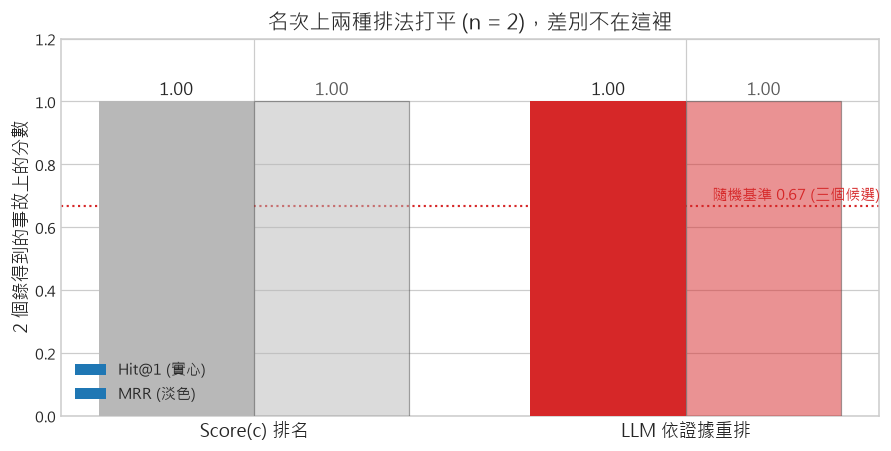

In [17]:
# 🎯 檢查一: 同一份短名單，工具的 Score(c) 排一次、模型依證據排一次，比 Hit@1 與 MRR。

# ============ ⚙️ 可調參數 ============
TOP_K_RANK = 5   # 模型最多回幾個候選。候選一共 5 個 (3 個真候選 + 2 個無證據候選)，
                 # 所以 5 等於「全部都要排出來」。調小 (3): 兩個無證據候選有可能整個
                 # 不出現在回傳裡，「預防幻覺」那一節「假候選有沒有墊底」那個檢查就沒有東西可以檢查
# TYPE_LABEL: 事故型別的中文名稱，候選清單與後面的報告都要用。
TYPE_LABEL = {
    "broadcast_storm": "Broadcast storm / L2 迴圈", "multicast_flooding": "Multicast flooding",
    "queue_congestion": "Queue congestion / 緩衝區壓力", "link_quality_issue": "鏈路品質問題",
    "load_sensitive_link_issue": "負載敏感的鏈路不穩", "large_file_backup": "大量傳輸 / 備份",
    "business_traffic_growth": "業務流量成長", "small_packet_scan": "小封包掃描 / 突增",
    "abnormal_device_sender": "異常發送端", "unknown_protocol_scan": "未知協定 / 掃描",
    "optical_degradation_failover": "光路劣化引發下游重傳",
    "batch_egress_saturation": "月結簡訊大量送出把出口推到飽和",
    "benign_batch_ramp": "良性的簡訊發送爬坡", "quote_push_batch_ramp": "行情推播檔期爬坡",
    "benign_capacity_growth": "良性容量成長", "batch_window_overrun": "日終對帳的執行時間逐日後移",
    "upstream_partial_outage": "上游部分失效"}
# ====================================

# ---- 1. 給模型的排序規則 ----
#      比上一份多兩條: 沒有證據支持的候選一律給低信心 (哪怕它聽起來合理)，
#      以及不可以假設我們給的順序就是對的。
RANK_SYSTEM_PROMPT = (
    "You are a senior AIOps engineer ranking root-cause candidates for one network incident. "
    "You are given tool-computed evidence and a numbered list of candidate causes. "
    "Rank the candidates by how well the EVIDENCE supports them. A candidate with no supporting "
    "evidence must receive a low confidence, even if it sounds plausible. "
    "Do not invent evidence. Do not assume the given order is correct. "
    "Answer in Traditional Chinese, keeping technical terms in English. "
    "Output strict JSON only: "
    '{"ranked": [{"idx": int, "confidence": int, "main_reason": str}]}, '
    "confidence is 0-100, list sorted by confidence descending, at most top_k entries."
)


# ---- 2. 候選清單: 工具的短名單，外加兩個刻意放進去的無證據候選 ----
#         挑那兩個的條件有兩個，缺一個這個檢查就沒有意義: 一、在網路維運裡聽起來都很合理;
#         二、這一次送進去的證據裡完全沒有對應的資料。
def build_cause_candidates(ev):
    ctx = contexts[ev.event_id]
    label = TYPE_LABEL.get(ev.event_type, ev.event_type)
    cands = [{"idx": i, "port_id": r["port_id"],
              "cause": f"{r['port_id']} 發生 {label}",
              "short": r["port_id"][-4:],
              "evidence": (f"{ctx['signature_metric']} z={r['z_signature']}"
                           f"、排名分數 {r['score']}"
                           f"、onset {r['onset'] if pd.notna(r['onset']) else '未越線'}")}
             for i, r in enumerate(ctx["ranking"])]
    cands.append({"idx": len(cands), "port_id": None, "cause": "最近一次設定變更或部署造成",
                  "short": "設定變更 (沒有證據)",
                  "evidence": "本次證據裡沒有任何變更或部署紀錄"})
    cands.append({"idx": len(cands), "port_id": None, "cause": "上游 device 硬體故障",
                  "short": "硬體故障 (沒有證據)",
                  "evidence": "本次證據裡沒有任何硬體錯誤計數的異常"})
    return cands


def rank_causes_claude(ev, cands, top_k=TOP_K_RANK, model=None):
    """送出去的是 context 加候選清單，沒有 domain_knowledge: 這一格問的是「照證據排名次」。

    port_id 在送出去之前被拿掉，模型只回 idx，名次要對回哪一個 port 由程式查。"""
    import anthropic
    model = model or LLM_MODEL
    payload = {"evidence": contexts[ev.event_id],
               "candidates": [{k: v for k, v in c.items() if k != "port_id"} for c in cands],
               "top_k": top_k}
    msg = anthropic.Anthropic().messages.create(
        model=model, max_tokens=MAX_TOKENS, system=RANK_SYSTEM_PROMPT,
        messages=[{"role": "user", "content": json.dumps(payload, ensure_ascii=False, default=str)}])
    text = "".join(b.text for b in msg.content if b.type == "text").strip()
    if text.startswith("```"):
        text = text.split("```", 2)[1].lstrip("json").strip()
    return json.loads(text)["ranked"][:top_k]


def rank_causes(ev, top_k=TOP_K_RANK):
    """回傳 (候選清單, 模型排好的名次)。沒有金鑰就讀錄好的那一份，兩條路格式一樣。"""
    cands = build_cause_candidates(ev)
    if USE_LLM:
        try:
            out = rank_causes_claude(ev, cands, top_k)
            RECORDED.setdefault("rank_causes", {})[ev.event_id] = out
            return cands, out
        except Exception as e:
            LLM_NOTES.append(f"{ev.event_id}: 排序呼叫失敗，改播錄好的那一份 ({e})")
    rec = RECORDED.get("rank_causes", {}).get(ev.event_id)
    if rec is None:
        return cands, None                     # 這個事故沒有錄，評估時直接跳過
    return cands, rec[:top_k]


def hit_and_rr(order, truth):
    """order 是候選的 port_id 依名次排好的串列。回傳 (Hit@1, RR)。

    跟前面那個 hit_mrr 算的是同兩個指標，差別只在輸入: 模型回來的就是名次，沒有分數。"""
    pos = [i + 1 for i, p in enumerate(order) if p in truth]
    if not pos:
        return 0.0, 0.0
    return float(pos[0] == 1), 1.0 / pos[0]


# ---- 3. 兩種排法在同一份短名單上的成績 ----
#         有金鑰就評全部 17 個事故; 沒金鑰就只評 llm_diagnoses.json 裡錄得到的那幾個。
EVAL_IDS = list(events.event_id) if USE_LLM else list(RECORDED.get("rank_causes", {}))
rows, fake_rows = [], []
for eid in EVAL_IDS:
    ev = events[events.event_id == eid].iloc[0]
    cands, ranked = rank_causes(ev, top_k=TOP_K_RANK)
    if ranked is None:
        continue
    truth = true_ports(ev)
    by_idx = {c["idx"]: c for c in cands}
    order_idx = [d["idx"] for d in sorted(ranked, key=lambda d: -d["confidence"])]
    tool_order = [c["port_id"] for c in cands if c["port_id"] is not None]   # Score(c) 的名次
    llm_order = [by_idx[i]["port_id"] for i in order_idx if by_idx.get(i, {}).get("port_id")]
    th, tr = hit_and_rr(tool_order, truth)
    lh, lr = hit_and_rr(llm_order, truth)
    rows.append({"事故": eid, "Score(c) Hit@1": th, "Score(c) RR": tr,
                 "LLM Hit@1": lh, "LLM RR": lr})
    # 順便記下兩個無證據候選被排到第幾名，預防幻覺那一節的檢查要用。
    for place, i in enumerate(order_idx, start=1):
        c = by_idx.get(i)
        if c and c["port_id"] is None:
            fake_rows.append({"事故": eid, "無證據的候選": c["short"],
                              "模型排第幾名": f"{place} / {len(order_idx)}",
                              "模型給的信心": next(d["confidence"] for d in ranked if d["idx"] == i)})

per_inc = pd.DataFrame(rows)
# 短名單只有三個真候選，所以隨機基準要照三個重算，不是沿用前面那個 0.29。
# port_id 等於 "MULTI" 的事故猜哪一個都算對，基準給 1.0。
rand_short = float(np.mean([1.0 if events[events.event_id == e].iloc[0].port_id == "MULTI"
                            else 1 / 3 for e in per_inc["事故"]]))
summary = pd.DataFrame([
    ("Score(c) 排名", per_inc["Score(c) Hit@1"].mean(), per_inc["Score(c) RR"].mean()),
    ("LLM 依證據重排", per_inc["LLM Hit@1"].mean(), per_inc["LLM RR"].mean()),
], columns=["排法", "Hit@1", "MRR"])

# ---- 4. 先看表: 逐事故的成績 ----
display(per_inc.set_index("事故").round(2))

# ---- 5. 再看圖: 兩種排法並排，虛線是這一塊的隨機基準 ----
fig, ax = plt.subplots(figsize=(8.2, 4.2), dpi=110)
xx = np.arange(len(summary))
wd = 0.36
ax.bar(xx - wd / 2, summary["Hit@1"], wd, color=["0.72", ACC], zorder=3)
ax.bar(xx + wd / 2, summary["MRR"], wd, color=["0.72", ACC], alpha=0.5, zorder=3,
       edgecolor="0.3", linewidth=0.8)
for x, (h_, m) in enumerate(zip(summary["Hit@1"], summary["MRR"])):
    ax.text(x - wd / 2, h_ + 0.02, f"{h_:.2f}", ha="center", fontsize=11)
    ax.text(x + wd / 2, m + 0.02, f"{m:.2f}", ha="center", fontsize=11, color="0.35")
ax.axhline(rand_short, color=ACC, ls=":", lw=1.4)
ax.text(len(summary) - 0.55, rand_short + 0.02, f"隨機基準 {rand_short:.2f} (三個候選)",
        ha="right", fontsize=10, color=ACC)
ax.bar([], [], color="0.5", label="Hit@1 (實心)")
ax.bar([], [], color="0.5", alpha=0.5, edgecolor="0.3", label="MRR (淡色)")
ax.legend(fontsize=10, loc="lower left", frameon=False)
ax.set_xticks(xx); ax.set_xticklabels(summary["排法"], fontsize=11.5)
ax.set_ylim(0, 1.2)
ax.set_ylabel(f"{len(per_inc)} 個錄得到的事故上的分數", fontsize=11.5)
ax.set_title(f"名次上兩種排法打平 (n = {len(per_inc)})，差別不在這裡", fontsize=13.5)
plt.tight_layout()
show_fig(fig)


### 結果是平手，代表我們白忙了嗎？

**結果是打平，而打平本身就是結論。** 兩種排法的 Hit@1 與 MRR 都是 1.00。**在名次這件事上，LLM 這一層沒有加分。**

**這個對照本身很鈍，要一起講。** 隨機基準在這兩個事故上高達 0.67,離滿分只剩三分之一的空間; 樣本數又只有 2,Hit@1 只有 0、0.5、1 三種可能，換一個事故就翻盤。**一個「打平」在這種條件下，既不能宣稱 LLM 有用，也不能宣稱它沒用。**

**LLM的價值不在名次，在上一格那張診斷表。** 同樣的證據，工具排得出名次,模型講得出理由、反面、缺什麼、下一步該查哪一個。**要衡量這一層，該看的是那幾欄有沒有寫對、追不追得回工具,而不是 Hit@1 有沒有變高。**

**要把樣本數撐到 17 很簡單**: 設好 `ANTHROPIC_API_KEY` 與 `USE_LLM=1` 重跑一次錄製，這一格的程式會自動涵蓋全部錄得到的事故，隨機基準也會跟著重算。


---

## 步驟六之一: 換一個產業，這套架構一行程式都不用改

```mermaid
flowchart LR
    M1["照直覺查一遍<br/>用幅度排"] --> M2["四種證據<br/>位置、關聯<br/>時序、可預測性"] --> M3["合成一個排名<br/>Score(c)"] --> M4["LLM 架構<br/>打包 context<br/>檢索領域知識"] --> M5["LLM 診斷<br/>與驗證"] --> M6["換產業、換檢索<br/>回饋迴路與上線"]
    style M6 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

```mermaid
flowchart LR
    S1["1 打包<br/>四項證據收成 context"] --> S2["2 檢索<br/>BM25 撈出 K(c)"] --> S3["3 送進 LLM"] --> S4["4 讀模型寫回來的診斷"] --> S5["5 驗證<br/>跟 Score(c) 比"] --> S6["6 換產業<br/>與回饋迴路"]
    style S6 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### 理論課那兩張補充投影片講的是製造業的例子: 結合設備知識、維修文件與 LLM,建立可解釋的故障診斷系統。同一套架構換一個產業，這一節就把它跑出來。

**這一章的每一個工具都只需要兩種輸入: 一份時間序列，一張依賴圖。** 它們不知道這些 port 是券商連線還是工廠的散熱器。所以架構分成兩半，各自的可換性不同:

- **四種證據與排名是自動執行的純數字運算。** 它們讀 metric 與依賴圖，輸出 z、onset、傳播延遲與名次。**換一個產業，這一半一行都不用改**,因為裡面沒有任何一個產業名詞
- **領域知識是可抽換的一包文件。** 元件叫什麼、處置手冊怎麼寫、以前有沒有發生過，全部從知識包來。**換一個客戶，換的是這一包**

```mermaid
flowchart TB
    subgraph KB["可抽換: 這個客戶的知識包"]
        K1["structure<br/>拓樸與服務依賴"]
        K2["runbook<br/>處置手冊"]
        K3["history<br/>歷史工單與變更紀錄"]
    end
    subgraph CORE["不動: 自動執行的證據運算"]
        C1["z 矩陣"] --> C2["拓樸可達"] --> C3["Pearson 關聯"]
        C3 --> C4["Granger、onset"] --> C5["Score(c) 排名"]
    end
    KB --> R["BM25 檢索"] -->|"撈回來的那幾段就是 K(c)"| P["payload 組裝<br/>context (通用) + K(c) (可抽換) "]
    CORE --> P
    P --> L["LLM"] --> O["根因候選<br/>信心<br/>建議處置"]
    style KB fill:#f7f0ef,stroke:#8d0801,stroke-width:2px
```

下一格拿同一份證據，只換知識包，看兩邊的輸出差在哪。


In [18]:
# 🎯 同一份證據換一包知識。RCA 那幾個數字兩邊一模一樣，變的只有名詞與處置。
#    這個迴圈是照 KNOWLEDGE_PACKS 的鍵一包跑一次的，加第三包進去就自動多一欄，
#    程式一行都不用改。送進去的 GENERIC_EVIDENCE 兩次都是同一份。
_out = {}
for pack_name in KNOWLEDGE_PACKS:
    r = explain_with_pack(GENERIC_EVIDENCE, pack_name)   # 檢索 K(c)，再用那一包的名詞講一次
    _out[r["知識包"]] = {                                 # 只留兩邊會不一樣的那幾項
        "根因候選": r["根因候選"], "受影響元件": r["受影響元件"], "診斷句": r["診斷句"],
        "檢索到的知識 K(c)": "、".join(r["檢索到的知識 K(c)"]),
        "建議處置": r["建議處置"], "類似的歷史事件": r["類似的歷史事件"],
    }

# 上半是兩邊不一樣的 (全部來自知識包)，下半三列是兩邊共用的 (全部來自證據運算)。
_cmp = pd.DataFrame(_out)
_cmp.loc["z (兩邊共用)"] = f"{GENERIC_EVIDENCE['z_top']:.1f}"
_cmp.loc["上游到下游的間隔 (兩邊共用)"] = f"{GENERIC_EVIDENCE['lag_min']} 分鐘 (onset 量出來的)"
_cmp.loc["第一名對第二名差距 (兩邊共用)"] = f"{GENERIC_EVIDENCE['margin']:.2f} 分"
_cmp.index.name = "同一份證據，兩個產業"
display(_cmp)


,network_ops,factory_maintenance
同一份證據，兩個產業,,
根因候選,port-id7427 (對外主線),散熱器 (變壓器的散熱單元)
受影響元件,port-id7429 (主機群 uplink)、port-id7431 (備份儲存),變壓器本體繞組、冷卻水循環泵
診斷句,port-id7427 (對外主線) 的 錯誤率 error_rate 先偏離同時段常態 (z=29.1)，40 分鐘後 port-id7429 (主機群 uplink)、port-id7431 (備份儲存) 才被放大。最嚴重的訊號在下游，觸發點在上游。,散熱器 (變壓器的散熱單元) 的 散熱效率 先偏離同時段常態 (z=29.1)，40 分鐘後 變壓器本體繞組、冷卻水循環泵 才被放大。最嚴重的訊號在下游，觸發點在上游。
檢索到的知識 K(c),NET-RUN-1、NET-HIST-1,FAB-HIST-1、FAB-RUN-1
建議處置,讀 SFP 收發光功率、檢查主備切換紀錄與 CRC 計數器、確認下游重傳是否跟著上游錯誤率走。,檢查散熱器是否有污垢或油泥堵塞、清潔散熱器並檢查冷卻水流量、若問題持續則檢查冷卻水泵與軸襯狀況。
類似的歷史事件,NET-HIST-1,FAB-HIST-1
z (兩邊共用),29.1,29.1
上游到下游的間隔 (兩邊共用),40 分鐘 (onset 量出來的),40 分鐘 (onset 量出來的)
第一名對第二名差距 (兩邊共用),24.71 分,24.71 分


#### 換一個客戶要重寫的程式是零行

**下面那三列兩邊完全一樣**: 上游的 z、上游到下游的間隔、第一名對第二名的分數差距。它們是前面十幾格的證據運算算出來的，跟產業無關。

**上面那幾列兩邊完全不同**: 元件叫什麼名字、BM25 撈到哪幾篇文件、處置手冊寫什麼。它們全部來自知識包。

**所以「換一個客戶要重寫多少程式」的答案是零行。** 要準備的是那個客戶的三份東西: 拓樸、處置手冊、歷史工單，也就是知識包裡那三種 kind。**連查詢字串都不用改**,因為它是用角色代號與純數字組出來的,「上游 X 劣化造成下游放大」這句話在網路與工廠是同一句。

**一個限制要一起講: 模型只能引用檢索回來的東西。** 上面的「建議處置」是從 runbook 原文切出來的，不是模型自己寫的。**檢索不到就要回答「知識包裡沒有」**,不可以自己補一段聽起來合理的話。

**理論課也把這件事的另一面列出來了: 拓樸與知識會過期。** 系統變動快，知識包要持續檢查與更新,而更新它的辦法就是下一節那個回饋迴路。


---

## 步驟六之二: 回饋迴路，讓它下一次自己變好

##### 理論課的端對端流程有七步，最後一步叫**學習**: 回饋結果，持續優化模型與知識庫。前面六步這一章與 Lab 06 都走過了，這一節做第七步。

**「持續優化」聽起來很虛，但它在程式上是很具體的四件事。** 關鍵是: **這一章的模型沒有被訓練，會變好的是它讀到的東西。**

- 排名的權重是等權，沒有在學
- LLM 的參數也沒有動,我們沒有在微調它

**會變好的是知識包。** 每處理完一次事故，維運人員知道真正的根因是什麼、真正有效的處置是什麼，那是這套系統原本沒有的資訊。把它寫回知識包，下一次同型事故的 BM25 就撈得到它，$K(c)$ 就比這一次好。

```mermaid
flowchart LR
    R["模型寫回來的診斷"] --> H{"維運人員<br/>核可還是否決"}
    H -->|"核可"| F["寫一行進<br/>rca_feedback.jsonl"]
    H -->|"否決"| F
    F -->|"只有核可的"| K["變成知識包裡的<br/>一篇 history 文件"]
    F -->|"只有否決的"| T["變成回歸測試的題目<br/>跟兩個假候選放在一起"]
    K --> N["下一次事故<br/>BM25 撈得到它"]
    T --> M["換模型、換 prompt 之前<br/>先跑一遍"]
    style F fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

**兩個方向要分開走，這是這張圖唯一的重點。**

- **核可的往右上走**: 它是新的知識，寫進知識包，讓下一次檢索得到更好的 $K(c)$
- **否決的往右下走**: 它是新的考題，寫進回歸測試。**否決的案例絕對不能進知識包**,因為檢索回一段「後來證實是錯的」診斷，會讓下一次跟著錯

<p align="center"><img src="slides/u08_closed_loop.png" width="80%" alt="單元 08 的端對端流程投影片: 觀測、偵測、降噪、根因分析、決策、處置、學習七個步驟繞成一個圈，第七步學習包含 Incident Outcome、Feedback、Model Update、KB Update，回饋結果持續優化模型與知識庫"></p>


,結果
這一迴合做了什麼,
回饋紀錄檔,outputs\workshop\rca_feedback.jsonl
目前累積幾筆,1 筆
其中核可的,1 筆 -> 變成知識包的 history 文件
其中否決的,0 筆 -> 變成上線前的回歸測試題目
知識包的文件數,4 篇 -> 5 篇
下一次檢索回來的 K(c),FB-L、NET-RUN-1
RCA 程式改了幾行,0 行。變的只有知識包



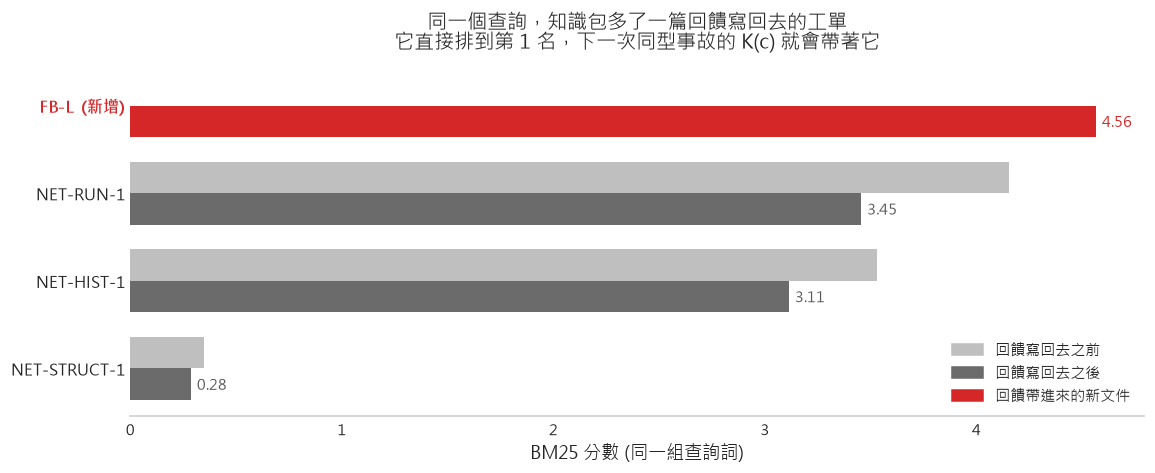

In [19]:
# 🎯 回饋迴路: 維運人員核可一次診斷，結果寫回知識包，下一次檢索就撈得到它。
#    這一格是真的在跑，不是流程說明: 它會在 outputs/workshop/ 底下寫出一個檔，
#    再用同一段 retrieve() 檢索第二次，前後兩次的分數就是下面那張圖的兩排長條。

# ============ ⚙️ 可調參數 ============
FEEDBACK_PATH = DATA_PROCESSED / "rca_feedback.jsonl"
# 用 jsonl (一行一筆) 而不是覆寫一個 json，因為要回答「三個月前那一次是誰核可的」就得
# 留著整串歷史。只追加、不修改、不刪除，這也是稽核的最低要求。
DOC_VERDICTS = ("confirmed",)   # 哪幾種 verdict 可以變成檢索得到的文件。
                                # 加上 "rejected": 下一次的 K(c) 裡就會夾著一段後來證實
                                # 是錯的機制敘述，模型讀到的證據從一開始就是錯的。
                                # 否決的那一筆是題目，它的去處是回歸測試
# ====================================


def read_feedback():
    """讀回所有回饋。檔案不存在就回空的，第一次跑不會炸。"""
    if not FEEDBACK_PATH.exists():
        return []
    return [json.loads(ln) for ln in FEEDBACK_PATH.read_text(encoding="utf-8").splitlines() if ln.strip()]


def submit_feedback(incident_id, verdict, actual_root_cause, actual_type, note, operator):
    """第一步: 維運人員在報告下面按的那一下。verdict 只有 confirmed 與 rejected 兩種。

    六個參數就是他實際要填的六件事。feedback_id 用「事故編號 + 核可的人」組出來，
    重跑這一格不會多一筆重複的紀錄; 正式環境這裡會是工單系統的 ID。"""
    rec = {"feedback_id": f"{incident_id}::{operator}",
           "incident_id": incident_id,
           "verdict": verdict,
           "predicted_root_cause": contexts[incident_id]["top_candidate"]["port_id"],
           "actual_root_cause": actual_root_cause,    # 人查出來的答案
           "actual_type": actual_type,
           "note": note,                              # 真正有效的處置，這是新知識
           "operator": operator}
    existing = {r["feedback_id"] for r in read_feedback()}
    if rec["feedback_id"] not in existing:
        with FEEDBACK_PATH.open("a", encoding="utf-8") as f:      # "a" 是從檔尾接著寫
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    return rec


def feedback_to_documents(verdicts=DOC_VERDICTS):
    """第二步: 核可過的變成知識包裡的一篇 history 文件。

    文件的寫法要跟知識包裡原有的一致 (帶時間、帶機制、帶處置)，否則檢索比對不到。
    回傳的每一篇都跟原有的文件同一個形狀，所以可以直接接在 PACK["文件"] 後面。"""
    docs = []
    for r in read_feedback():
        if r["verdict"] not in verdicts:
            continue
        docs.append({"id": f"FB-{r['incident_id']}", "kind": "history",
                     "text": f"工單 {r['incident_id']}: {r['note']} "
                             f"根因確認為 {r['actual_root_cause']} ({r['actual_type']})。"})
    return docs


def regression_cases():
    """第三步: 否決過的變成回歸測試的題目，換模型、換 prompt 之前要先跑一遍。

    跟前面那兩個無證據候選放在同一個位置: 它們都是「上線前必須通過」的檢查。"""
    return [{"incident_id": r["incident_id"], "模型當初答的": r["predicted_root_cause"],
             "正確答案": r["actual_root_cause"]}
            for r in read_feedback() if r["verdict"] == "rejected"]


# ---- 1. 跑一次: 檢索 -> 核可 -> 知識包長大 -> 再檢索 ----
#         k 刻意設成整包的文件數，因為這一格要比的是每一篇文件前後各拿幾分。
#         真正交給模型的檢索用的是 RETRIEVE_K (只取前兩名)，兩者的用途不同。
before = retrieve(QUERY, PACK, k=len(PACK["文件"]))
# 下面這六個值就是維運人員在報告底下填的內容。課堂上直接寫死，正式環境從工單系統帶進來。
submit_feedback(
    incident_id=INCIDENT.event_id,
    verdict="confirmed",
    actual_root_cause=INCIDENT.port_id,
    actual_type=INCIDENT.event_type,
    note="上游對外主線光功率衰減，錯誤率先升約 40 分鐘後下游流量才被重傳放大，更換 SFP 後恢復。",
    operator="on-call-01",
)
# 知識包長大: 原本的文件加上回饋變出來的文件。dict(PACK, 文件=...) 會複製一份，
# 原本的 PACK 不動，所以上面 before 那一次仍然是在原本四篇上算的，前後兩次才比得起來。
PACK_V2 = dict(PACK, 文件=PACK["文件"] + feedback_to_documents())
after = retrieve(QUERY, PACK_V2, k=len(PACK_V2["文件"]))

# ---- 2. 先看表: 這一迴合實際發生了什麼 ----
#         每一列都是上面那幾行程式真的做出來的結果，最後一列是這一節的重點。
display(pd.DataFrame([
    ("回饋紀錄檔", str(FEEDBACK_PATH.relative_to(PROJECT_ROOT))),
    ("目前累積幾筆", f"{len(read_feedback())} 筆"),
    ("其中核可的", f"{len(feedback_to_documents())} 筆 -> 變成知識包的 history 文件"),
    ("其中否決的", f"{len(regression_cases())} 筆 -> 變成上線前的回歸測試題目"),
    ("知識包的文件數", f"{len(PACK['文件'])} 篇 -> {len(PACK_V2['文件'])} 篇"),
    ("下一次檢索回來的 K(c)", "、".join(d["id"] for _, _, d in retrieve(QUERY, PACK_V2))),
    ("RCA 程式改了幾行", "0 行。變的只有知識包"),
], columns=["這一迴合做了什麼", "結果"]).set_index("這一迴合做了什麼"))

# ---- 3. 再看圖: 同一個查詢，知識包長大前後撈回來的東西差在哪 ----
#         一篇文件一列，上面那根是回饋寫回去之前，下面那根是之後。
#         新文件在「之前」那一次不存在，所以用預設值 0.0 補，圖上就是沒有長條。
ids_a = [d["id"] for _, _, d in after]
sims_b = {d["id"]: s for s, _, d in before}
sims_a = {d["id"]: s for s, _, d in after}
order = ids_a                                  # 照「之後」的名次排，新文件排到哪裡才看得出來
fig, ax = plt.subplots(figsize=(10.6, 4.4), dpi=110)
yy = np.arange(len(order))[::-1]
h = 0.36
ax.barh(yy + h / 2, [sims_b.get(i, 0.0) for i in order], h, color="0.75", zorder=3)
ax.barh(yy - h / 2, [sims_a.get(i, 0.0) for i in order], h,
        color=[ACC if i.startswith("FB-") else "0.42" for i in order], zorder=3)
for y, i in zip(yy, order):
    ax.text(sims_a.get(i, 0.0) + 0.03, y - h / 2, f"{sims_a.get(i, 0.0):.2f}",
            va="center", fontsize=9.5, color=ACC if i.startswith("FB-") else "0.35")
ax.set_yticks(yy)
ax.set_yticklabels([f"{i}  (新增)" if i.startswith("FB-") else i for i in order], fontsize=10.5)
for tick, i in zip(ax.get_yticklabels(), order):
    if i.startswith("FB-"):
        tick.set_color(ACC); tick.set_fontweight("bold")
ax.set_xlabel("BM25 分數 (同一組查詢詞)", fontsize=11.5)
ax.grid(False)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in ("0.75", "0.42", ACC)],
          labels=["回饋寫回去之前", "回饋寫回去之後", "回饋帶進來的新文件"],
          fontsize=10, loc="lower right", frameon=False)
_place = order.index(next(i for i in order if i.startswith("FB-"))) + 1
ax.set_title(f"同一個查詢，知識包多了一篇回饋寫回去的工單\n"
             f"它直接排到第 {_place} 名，下一次同型事故的 K(c) 就會帶著它", fontsize=13)
plt.tight_layout()
show_fig(fig)


#### 變好的是知識包，RCA 的程式一行都沒有動

**淺灰是回饋寫回去之前，深灰是之後，紅色那一根是回饋帶進來的新文件。** 同一組查詢詞、同一段檢索程式，唯一的差別是知識包裡多了一篇文件，而那一篇是維運人員這一次核可完寫回去的。

**新文件直接排到第一名 (4.56),所以下一次同型事故的 $K(c)$ 會帶著它。** 這就是「持續優化知識庫」在程式上的樣子: 不是重新訓練什麼，是**讓下一次撈得到這一次學到的東西**。

**另外三根長條都變矮了**,`NET-RUN-1` 從 4.15 掉到 3.45。這不是它變差了，是 BM25 的分數本來就是相對於整包文件算的: 文件多了一篇，含有那些詞的文件比例上升，IDF 就下降。**所以知識包長大之後，要重新看的是名次，不是分數的絕對值。**

**三件實務上要注意的事:**

- **回饋只追加，不修改。** 用的是 `jsonl`,一行一筆，寫完不動它。要回答「三個月前那一次是誰核可的」就得留著整串歷史,這也是稽核的最低要求
- **否決的不進知識包。** 它進的是回歸測試。一段後來證實是錯的診斷被檢索回來，會讓下一次的 $K(c)$ 帶著錯的機制敘述
- **寫回去的文字要跟知識包原有的寫法一致** (帶時間、帶機制、帶處置)。上面那筆刻意寫成跟 `NET-HIST-1` 一樣的格式，不然 BM25 對不到那些詞,**「寫回去」不等於「寫進去就有用」**


---

## 預防幻覺

##### 前面兩節講的是這套架構換得到什麼。這一節講上線之前一定要擋掉的兩件事。

**模型讀得到證據，不代表它真的讀了。** 名次那一節做的是檢查一 (工具排一次、模型排一次)，這一節補上另外兩個。下一格用這兩個機械檢查驗這件事，兩個都是純字串與名次的比對，沒有一項需要人主觀判斷:

- **檢查二: 模型會不會把沒有證據的候選排到前面。** 排序那一格的短名單裡刻意混了兩個證據完全沒提到、但聽起來很合理的候選
- **檢查三: 它寫的每一句證據，來源標籤是不是工具真的產得出來的。** 這是「整合證據，不生成證據」唯一機械檢查得了的地方


In [20]:
# 🎯 檢查二與檢查三: 上線之前一定要擋掉的兩件事，一張表講完。
#    這一格不呼叫模型，也沒有連網: 它讀的是排序那一格留下來的 fake_rows，以及
#    llm_diagnoses.json 裡錄好的那幾份診斷。兩個檢查都是純字串與名次的比對。

# ============ ⚙️ 可調參數 ============
# KNOWN_PREFIX: 允許出現的來源標籤前綴清單，也就是檢查三的判準。比的是前綴而不是整串，
#   所以 "ranking:z_signature" 靠 "ranking:" 這一項就過得了。
#   放得太寬 (把空字串加進去): 什麼標籤都會通過，這個檢查就等於沒做;
#   放得太窄: 合格的標籤會被標出來，那時候要改的是這個 tuple，不是模型。
#   什麼時候該加一項: context 新增了欄位，而模型開始引用那個欄位當來源。
KNOWN_PREFIX = ("metric:", "onset:", "zmatrix:", "C(c):", "ranking:", "topology:",
                "context:", "evidence_chain", "provenance", "domain_knowledge", "K(c)")
# ====================================

# ---- 1. 檢查二: 模型會不會把沒有證據的候選排到前面 ----
#         短名單裡混了兩個證據裡完全沒提到的候選，它們聽起來都很合理，所以一個沒有真的
#         讀證據的模型會給它們高分。合格標準: 兩個都要墊底。
_fake = pd.DataFrame(fake_rows)
# 「模型排第幾名」那一欄長得像 "4 / 5"。取斜線左邊的名次比大小，min() 取排最前面的
# 那個假候選: 檢查要看的是最糟的那一個。
_fake_worst = (int(min(int(s.split("/")[0]) for s in _fake["模型排第幾名"]))
               if len(_fake) else 0)
_n_cand = int(_fake["模型排第幾名"].iloc[0].split("/")[1]) if len(_fake) else 0
_fake_ok = len(_fake) > 0 and _fake_worst > _n_cand - len(_fake) / max(len(EVAL_IDS), 1) - 0.5

# ---- 2. 檢查三: 模型寫的每一句證據，來源標籤是不是工具真的產得出來的 ----
#         這是「整合證據，不生成證據」唯一機械檢查得了的地方。
#         支持與反對兩邊接成一串一起檢查: 編造來源這件事在哪一邊都可能發生。
_claims = _ok = 0
_flagged = []            # 沒通過的來源標籤原樣收在這裡，最後印出來給人判斷
for eid in EVAL_IDS:
    rec = RECORDED.get("diagnose", {}).get(eid)
    if rec is None:
        continue
    cl = rec["supporting_evidence"] + rec["contrary_evidence"]
    _claims += len(cl)
    for c in cl:
        s = str(c.get("source", ""))               # 沒寫 source 的就是空字串，一定不通過
        if s.startswith(KNOWN_PREFIX):
            _ok += 1
        else:
            _flagged.append(f"{eid}: {s}")

display(pd.DataFrame([
    ("無證據的候選有沒有墊底",
     f"{len(EVAL_IDS)} 場事故各混 2 個假候選 (共 {len(_fake)} 筆)，"
     f"排最前面的那一個在第 {_fake_worst} / {_n_cand} 名，"
     f"信心 {_fake['模型給的信心'].min()} 到 {_fake['模型給的信心'].max()} 分"
     if len(_fake) else "沒有錄到可比的事故",
     "兩個都必須排在真候選後面。跑到前面就代表模型在生成證據，那個模型不要上線"),
    ("每一句證據追不追得回工具",
     f"{_claims} 條證據裡有 {_ok} 條的來源標籤在白名單裡 ({_ok / max(_claims, 1):.0%})",
     "不在白名單裡的要逐條打開看: 先判斷是模型在編，還是白名單太窄"),
    ("被標出來的來源標籤", "；".join(_flagged) or "無",
     "這一欄就是上面那些不在白名單裡的標籤本身"),
], columns=["上線前的檢查", "這一次的結果", "合格標準"]).set_index("上線前的檢查"))


,這一次的結果,合格標準
上線前的檢查,,
無證據的候選有沒有墊底,2 場事故各混 2 個假候選 (共 4 筆)，排最前面的那一個在第 4 / 5 名，信心 3 到 4 分,兩個都必須排在真候選後面。跑到前面就代表模型在生成證據，那個模型不要上線
每一句證據追不追得回工具,32 條證據裡有 32 條的來源標籤在白名單裡 (100%),不在白名單裡的要逐條打開看: 先判斷是模型在編，還是白名單太窄
被標出來的來源標籤,無,這一欄就是上面那些不在白名單裡的標籤本身


#### 這兩個檢查是回歸測試，不是示範

**這兩個檢查不是示範，是回歸測試。** 換模型、改 prompt、換知識包之前都要再跑一遍,任何一項不合格就不要上線。

**第一項: 兩個假候選都墊底。** 「最近一次設定變更」與「上游硬體故障」是刻意混進短名單的，證據裡完全沒有提到它們。它們排在最後、信心只有 3 到 4 分,而真候選是 30 分以上。**這一項會抓到的失敗是「模型在憑常識回答」**: 這兩句聽起來都很合理，所以只要模型沒有真的讀證據，它們就會拿到跟真候選差不多的信心。

**第二項: 每一句證據的來源標籤都追得回工具。** 這是「整合證據，不生成證據」唯一機械檢查得了的地方。**這一項會抓到的失敗是模型自己編了一個資料來源**,例如引用一段 syslog、一筆變更紀錄,而那些東西根本沒有送進去。

**一個自動檢查回報不合格的時候，先看它標出來的東西長什麼樣，再決定要修模型還是修檢查。** 白名單太窄也會讓合格的標籤被標出來,那時候要改的是白名單，不是模型。**最後一列就是為了這個而存在的**: 它把被標出來的標籤原樣印出來，讓人有東西可以判斷。


---

## 輸出資料


In [21]:
# 🎯 輸出資料: 一份人看的事件報告，兩份機器看的 CSV。
#    兩個出口共用同一份證據，但沒有共用同一種格式: 把 CSV 直接給人看，或把整段中文報告
#    塞進 Prometheus，兩種都會讓另一邊沒辦法用。

# ============ ⚙️ 可調參數 ============
REPORT_ACTIONS_N = 3   # 報告裡列出幾條建議處置。沒有列出來的那幾條仍然在模型的輸出裡
Z_EXPORT = ["traffic_total", "error_rate", "discard_rate", "broadcast_total"]
                       # 每個 port 要匯出哪幾個 metric 的 z，一個就多一欄
CONF_SCORE = {"High": 0.9, "Medium": 0.6, "Low": 0.3}
                       # 三級換成 0 到 1 的數字給 Grafana (Prometheus 存不了 "High" 這種字)。
                       # 三級等距而且都不貼在 0 或 1，留得下之後要加第四級的位置
ESCALATE_SCORE = 60    # 單一 port 的事故要幾分才自動標成需要升級 (Score(c) 是 0 到 100)。
                       # 調低: 要處理的升級案件變多; 調高: 分數中段的事故沒有人被通知。
                       # 另一個條件跟分數無關: 影響超過一個 port 就一律標記
CASE_PAD = "2h"        # 逐格 CSV 取事故窗前後各多久。事故窗本身 235 分鐘，前後各兩小時
                       # 加起來 240 分鐘，所以整張圖大約一半是事故、一半是事故前後
# INCIDENT_LEVEL: 這六個欄位只放在排第一的那一列，其餘留白，這樣 Grafana 上的 count
#   才不會被同一個事件的五列灌成五倍。
INCIDENT_LEVEL = ["rank_of_true_cause", "hit_at_3", "affected_port_count",
                  "cross_port_synchrony", "confidence_score", "escalation_flag"]
# ====================================


# ---- 1. 出口一: 人看的事件報告 ----
#         這個函式不重算任何東西，也沒有一句話是它自己寫的，它只負責排版:
#         每一列都是模型輸出的某一個欄位，最後一列是 context 的 provenance。
def render_report(ev):
    diag, _ = diagnose_llm(ev)
    ctx = contexts[ev.event_id]
    rows = [("摘要", diag["incident_summary"])]
    for h in diag["root_cause_hypotheses"]:
        rows.append((f"根因候選 #{h['rank']} [{h['confidence']}]",
                     f"{h['candidate']}  ({h['reasoning']})"))
    imp = diag["impact_scope"]
    rows.append(("影響範圍", f"{len(imp['ports'])} 個 port ({'、'.join(imp['roles'])})"
                             f"／device {'、'.join(imp['devices'])}"
                             f"／持續 {imp['duration_min']} 分鐘"))
    # 每一條證據後面都跟著 [source]，那是它從哪一個工具算出來的。
    rows += [("支持證據", f"{e['claim']}    [{e['source']}]") for e in diag["supporting_evidence"]]
    rows += [("反對證據與不確定性", f"{e['claim']}    [{e['source']}]")
             for e in diag["contrary_evidence"] or [{"claim": "無", "source": "-"}]]
    rows += [("可能傳播路徑", p) for p in diag["propagation_path"]]
    rows += [("需要補充的資料", m) for m in diag["missing_information"]]
    rows += [("建議下一步調查", s) for s in diag["next_steps"]]
    rows.append(("建議處置", "、".join(diag["recommended_actions"][:REPORT_ACTIONS_N])))
    rows.append(("是否需要升級", str(diag["escalation_needed"])))
    # provenance 壓成一行放在報告最後: 三個月後要重跑這一份診斷，靠的就是這一列。
    rows.append(("Provenance", "／".join(f"{k}={v}" for k, v in ctx["provenance"].items())))
    return pd.DataFrame(rows, columns=[f"Incident {ev.event_id}: {diag['problem_type']}", "內容"])


display(render_report(INCIDENT))


# ---- 2. 信心怎麼算: 來自「證據完整度」，不是把排名分數轉成百分比 ----
#         四個佐證訊號各給一分，湊得越多信心越高。這是刻意不看分數大小的: 一個分數很高
#         但只有單一項證據撐著的候選，並不比一個分數普通但四項都指同一邊的可信。
#         四個門檻裡值得注意的是 |z| >= 5: 前面判定異常用的是 3 sigma，這裡刻意設得比它嚴，
#         用意是把「有異常」與「強到單看它就足以撐一分」分開。
def evidence_confidence(ctx):
    """回傳 (幾分, High/Medium/Low)。滿分 4 分，湊滿三分才叫 High。"""
    s = 0
    s += 1 if pd.notna(ctx["ranking"][0].get("onset")) else 0        # 有明確的 anomaly onset
    s += 1 if ctx["cross_port_synchrony"] > 0.5 else 0               # 跨 port 互相佐證
    s += 1 if len(ctx["affected_ports"]) > 1 else 0                  # 有扇出證據
    s += 1 if abs(ctx["top_candidate"]["z_signature"]) >= 5 else 0    # 簽章 metric 夠強
    return s, ("High" if s >= 3 else "Medium" if s == 2 else "Low")


# ---- 3. 出口二: 每個事故每個 port 一列，寫成 rca_results.csv ----
#         每個 port 都留一列，因為 fan-out 這件事只有五個 port 擺在一起才看得出來。
rca_rows = []
for _, ev in events.iterrows():
    rank, _ = rank_candidates_cached(ev); ctx = contexts[ev.event_id]
    z = window_zscores(ev.start_time, ev.end_time)
    er = ev_df[ev_df.incident == ev.event_id].iloc[0]     # 這一場在評估那一節算出來的成績
    _, conf = evidence_confidence(ctx)
    escalate = bool(len(ctx["affected_ports"]) > 1
                    or ctx["top_candidate"]["score"] >= ESCALATE_SCORE)
    for _, cand in rank.iterrows():
        row = {
            "timestamp": ev.start_time, "device_id": cand.device_id, "port_id": cand.port_id,
            "port_role": features[features.port_id == cand.port_id].port_role.iloc[0],
            "event_label": ev.event_type, "ml_method": "rca",
            "candidate_rank": float(cand["rank"]),
            "root_cause_score": float(cand.score),
        }
        for m in Z_EXPORT:
            row[f"z_{m}"] = float(z.loc[cand.port_id, m]) if cand.port_id in z.index else float("nan")
        incident_level = {
            "rank_of_true_cause": float(er["rank_of_true"]) if er["rank_of_true"] else float("nan"),
            "hit_at_3": float(er["hit@3"]),
            "affected_port_count": float(len(ctx["affected_ports"])),
            "cross_port_synchrony": float(ctx["cross_port_synchrony"]),
            "confidence_score": CONF_SCORE[conf],
            "escalation_flag": float(escalate),
        }
        # 第一名那一列填上面那六個值，第二到第五名一律填 nan (CSV 裡就是空格):
        # nan 在 Prometheus 與 Grafana 的 count 裡不算一筆，五倍灌水就是這樣避開的。
        row.update(incident_level if cand["rank"] == 1 else {k: float("nan") for k in INCIDENT_LEVEL})
        rca_rows.append(row)
rca_results = pd.DataFrame(rca_rows)
rca_results.to_csv(DATA_PROCESSED / "rca_results.csv", index=False)

# ---- 4. 出口三: 上課這一次事故的逐格資料，寫成 Grafana 那一段要重播的 CSV ----
#         六個數值欄位裡，z_error_rate / root_cause_score / candidate_rank 是「整段窗一個值」，
#         在圖上是水平線，那是刻意的: 它們是事後算出來的結論，不是逐格量到的訊號。
CASE_LO = INCIDENT.start_time - pd.Timedelta(CASE_PAD)
CASE_HI = INCIDENT.end_time + pd.Timedelta(CASE_PAD)
_zcase = window_zscores(INCIDENT.start_time, INCIDENT.end_time)
_rank_by_port = rank_inc.set_index("port_id")
case_rows = []
for p in ALL_PORTS:
    g = feat_by_port[p].loc[CASE_LO:CASE_HI]
    onset_t = onset_inc.get(p)                    # 這個 port 第一次越線的時刻
    case_rows.append(pd.DataFrame({
        "timestamp": g.index,
        "device_id": PORT_DEVICE[p], "port_id": p, "port_role": PORT_ROLE[p],
        "event_label": INCIDENT.event_type, "ml_method": "rca-case",
        "traffic_total": g["traffic_total"].to_numpy(float),
        "error_rate": g["error_rate"].to_numpy(float),
        "z_error_rate": float(_zcase.loc[p, SIGNATURE]),
        "root_cause_score": float(_rank_by_port.loc[p, "score"]),
        "candidate_rank": float(_rank_by_port.loc[p, "rank"]),
        # onset 之後每一格都是 1。階梯往上跳的先後，就是時序那一節量到的先後。
        "onset_flag": (0.0 if onset_t is None
                       else (g.index >= onset_t).astype(float)),
    }))
# 照時間、port 排序: 重播服務是照時間軸一格一格往前推的，同一刻的五個 port 要排在一起。
rca_case = pd.concat(case_rows, ignore_index=True).sort_values(["timestamp", "port_id"])
rca_case.to_csv(DATA_PROCESSED / "rca_case_L.csv", index=False)

# ---- 5. 寫出去了什麼 ----
#         最後一列不是提醒而已: 欄名是重播服務啟動時比對的清單，改了名字它會直接結束，
#         Grafana 上每一個 panel 都會變成 No data。
display(pd.DataFrame([
    ("rca_results.csv", f"{len(rca_results):,} 列 = {len(events)} 個事故 x {len(ALL_PORTS)} 個 port，"
                        f"{rca_results.shape[1]} 欄 (每一場事故的結論)"),
    ("rca_case_L.csv", f"{len(rca_case):,} 列 = {len(ALL_PORTS)} 個 port x "
                       f"{len(rca_case) // len(ALL_PORTS)} 個取樣點，"
                       f"{CASE_LO:%m-%d %H:%M} 到 {CASE_HI:%H:%M} (事故窗前後各多 {CASE_PAD})"),
    ("存放位置", str(DATA_PROCESSED.relative_to(PROJECT_ROOT))),
    ("誰會讀它", "infra/stack 的重播服務。欄名綁死 compose.yaml 裡的 RESULT_COLUMNS，不要動"),
], columns=["輸出資料", "內容"]).set_index("輸出資料"))
display(rca_results[rca_results.candidate_rank == 1][
    ["timestamp", "port_id", "event_label", "root_cause_score", "rank_of_true_cause",
     "hit_at_3", "confidence_score", "escalation_flag"]].set_index("timestamp"))


,Incident L: network_ops 知識包下的 error_rate 異常事件: 上游 port 先偏離同時段常態，下游 port 隨後被放大 (signature_metric=error_rate),內容
0,摘要,"2026-03-02 14:00 到 17:55 (duration_min=235, window_samples=48) ，signature_metric 為 error_rate。evidence_chain 顯示三個 port 依序偏離同時段常態超過 3 sigma: port-id7427 (edge-fw-01) 於 14:00、port-id7429 (core-sw-01) 於 14:40、port-id743..."
1,根因候選 #1 [Medium],"port-id7427 (edge-fw-01, 對外主線) 的 error_rate 劣化為觸發點，下游 port-id7429 與 port-id7431 被放大 (port-id7427 的 onset 是 2026-03-02 14:00:00，早於 port-id7429 的 14:40 與 port-id7431 的 14:55 (ranking:onset) ，且是 evidence_chain 的第一筆。Sco..."
2,根因候選 #2 [Low],"port-id7429 (core-sw-01, 主機群 uplink) 自身劣化為主因，port-id7427 的早期偏離只是同期背景訊號 (port-id7429 的 z_signature=76.7 是三者中最大的，遠高於被判為根因的 port-id7427 的 29.1 (ranking:z_signature) ，訊號強度支持它是問題核心。反對它的是 onset: 它的 14:40 晚於 port-id7427 的 ..."
3,根因候選 #3 [Low],"三個 port 各自獨立劣化，或存在一個未被查詢到的共同上游因素，不構成單一傳播鏈 (cross_port_synchrony=0.23、pearson=0.065、granger=0.0 (status=zero) 三項都指向 port 之間的關聯很弱 (context:cross_port_synchrony, C(c):pearson, C(c):granger) ，這與單一根因往下游傳播的說法有張力。另一方面 co_o..."
4,影響範圍,3 個 port (對外主線、主機群 uplink、備份儲存)／device edge-fw-01、core-sw-01、dist-sw-02／持續 235 分鐘
5,支持證據,port-id7427 的 onset 是 2026-03-02 14:00:00，早於 port-id7429 的 2026-03-02 14:40:00 與 port-id7431 的 2026-03-02 14:55:00，時間順序上位於最前。 [ranking:onset (rank=1/2/3)]
6,支持證據,port-id7427 (edge-fw-01) 的 error_rate 偏離同時段常態超過 3 sigma，且是 evidence_chain 的第一筆紀錄。 [metric:error_rate@port-id7427 / context:evidence_chain[0]]
7,支持證據,Score(c) 給 port-id7427 的分數是 72.65，第 2 名 port-id7429 是 47.94，ranking_margin=24.71，第一名不是險勝。 [ranking:Score(c) margin]
8,支持證據,onset_distinct_slots=3，三個 port 的起始點落在三個不同時間槽，符合分批發生而非同時觸發。 [context:onset_distinct_slots]
9,支持證據,"onset 的判定條件是對同時段歷史基線的 z 搭配 k=3/run=3，起始點需要連續成立才算數，不是單一取樣點的雜訊。 [onset:baseline+3sigma, run=3 (context:provenance.模型版本)]"


,內容
輸出資料,
rca_results.csv,85 列 = 17 個事故 x 5 個 port，18 欄 (每一場事故的結論)
rca_case_L.csv,480 列 = 5 個 port x 96 個取樣點，03-02 12:00 到 19:55 (事故窗前後各多 2h)
存放位置,outputs\workshop
誰會讀它,infra/stack 的重播服務。欄名綁死 compose.yaml 裡的 RESULT_COLUMNS，不要動


,port_id,event_label,root_cause_score,rank_of_true_cause,hit_at_3,confidence_score,escalation_flag
timestamp,,,,,,,
2026-02-04 09:00:00,port-id7430,business_traffic_growth,56.28,1.0,1.0,0.9,1.0
2026-02-06 13:10:00,port-id7428,small_packet_scan,51.75,1.0,1.0,0.6,0.0
2026-02-08 01:00:00,port-id7431,large_file_backup,6.80,1.0,1.0,0.3,0.0
2026-02-11 15:20:00,port-id7427,queue_congestion,51.75,1.0,1.0,0.6,0.0
2026-02-14 10:35:00,port-id7429,link_quality_issue,26.75,1.0,1.0,0.3,0.0
2026-02-17 16:00:00,port-id7427,load_sensitive_link_issue,51.75,1.0,1.0,0.6,0.0
2026-02-19 11:30:00,port-id7427,broadcast_storm,82.24,1.0,1.0,0.9,1.0
2026-02-22 20:05:00,port-id7427,multicast_flooding,80.72,1.0,1.0,0.9,1.0
2026-02-25 09:45:00,port-id7430,abnormal_device_sender,51.75,1.0,1.0,0.6,0.0


---

## 上 Grafana: 一行指令，兩本 lab 的 case 各一張儀表板

##### 監控的最後一步是「維運人員看得到」。算完卻只留在 notebook 裡，等於沒做。

Week 6 走的是「模型算完再重播」: notebook 算完寫 CSV，一支重播服務把 CSV 重播成 metrics。

```mermaid
flowchart LR
    A1["Lab 06 notebook"] --> A2["forecast_case_K.csv"] --> A3["重播 :8011"]
    A6["Lab 07 notebook"] --> A7["rca_case_L.csv"] --> A8["重播 :8010"]
    A3 --> A4["Prometheus :9090"]
    A8 --> A4
    A4 --> A5["Grafana :3000<br/>兩張儀表板"]
```

Week 6 走前半段，是因為 Prophet 要一整段歷史才配適得起來、RCA 的排名也要整段事故窗，兩件事都塞不進「每 15 秒算一次」的迴圈。**重點是後半段完全沒有差別**: 分數進了 Prometheus 之後，Grafana 的 panel 與規則檔跟分數是哪一支程式算的無關。

#### 怎麼開: 一行指令

在 `week6` 這個資料夾裡 (跟這本 notebook 同一層) 執行:

```bash
python 4_grafana.py
```

**跑之前兩本 notebook 都要先跑完**，因為要重播的是它們各自寫出來的 `forecast_case_K.csv` 與 `rca_case_L.csv`。這支程式會依序檢查 Docker、那兩份 CSV、四個 host port，再把整組服務帶起來並打開兩張儀表板; 任何一步失敗都會直接告訴你下一步該做什麼。其他子指令: `health` 只檢查、`open` 只開瀏覽器、`logs` 看紀錄、`down` 關掉。

#### 兩張儀表板，各自在自己的 localhost 上點開

- **Lab 06 預測儀表板** (預警的那兩晚): [http://localhost:3000/d/aiops-lab06-forecast/lab-06?from=now-15m&to=now&refresh=5s](http://localhost:3000/d/aiops-lab06-forecast/lab-06?from=now-15m&to=now&refresh=5s)
- **Lab 07 RCA 儀表板** (這一本走的事故 L): [http://localhost:3000/d/aiops-lab07-rca/lab-07-rca?from=now-15m&to=now&refresh=5s](http://localhost:3000/d/aiops-lab07-rca/lab-07-rca?from=now-15m&to=now&refresh=5s)

**不用帳號密碼。** `infra/stack/compose.yaml` 給 Grafana 設了 `GF_AUTH_ANONYMOUS_ENABLED=true`、`GF_AUTH_ANONYMOUS_ORG_ROLE=Viewer` 與 `GF_AUTH_DISABLE_LOGIN_FORM=true`,所以點進去直接就是唯讀畫面，不會出現登入頁。`infra/stack/.env.example` 裡也沒有帳密那一欄，它只放重播倍速與四個 host port。

**網址打不開就回去跑一次 `python 4_grafana.py`** (或 `python 4_grafana.py health` 看是哪一步沒過)。

> **一個 Grafana、一個 Prometheus、兩支重播服務。** Grafana 在 `localhost:3000`、Prometheus 在 `localhost:9090`,重播服務 Lab 06 在 `localhost:8011`、Lab 07 在 `localhost:8010`。**兩支曝露的 metric 名稱是同一個** (`aiops_python_result`)，所以每一句查詢都一定要帶 `job="lab06-replayer"` 或 `job="lab07-replayer"`,不帶的話 `traffic_total` 這種兩邊都有的欄位會一次回十條線。兩張儀表板裡的查詢都已經帶好了。

> **重播是加速的，所以時間軸有兩個**: Prometheus 的 `[5m]`、`for:` 量的是牆上時間，CSV 裡的 `timestamp` 量的是資料時間。設 `WEEK6_REPLAY07_SPEED=1` 兩個就對齊，代價是八小時的資料要跑八小時。正式環境沒有這個問題。

打開之後看到的就是上課走的那兩個 case: Lab 06 是 2/25 良性與 2/26 越線的兩晚對照，Lab 07 是這一本走的事故 L。兩份都循環重播，一輪各約八分鐘。

#### 儀表板上有四排，各回答一個問題

1. **監控畫面看得到的**: 五個 port 的 `traffic_total`。只有兩個下游 port 在動
2. **換一個量才看得到根因**: `error_rate` 與 `onset_flag`。左邊看誰的錯誤率先升，右邊那個階梯圖看誰先越線
3. **工具給的答案**: `Score(c)` 分數、排名、以及 `z(error_rate)`。**排名第一的那個 port，z 不是最大的**
4. **整條鏈活著嗎**: 重播服務 UP、重播走到哪一刻、曝露了幾條 series。**第一格是 0 的時候，上面每一張圖看到的都是舊資料**

**跑起來之後畫面長這樣** (這兩張是先前跑完的截圖):

<p align="center"><img src="screenshots/lab06_grafana_forecast_row.png" width="80%" alt="Grafana 的 Forecast risk 一整排 panel: 左上是實際值與預測值疊圖，右上是外推值與預測型告警旗標，左下是 risk score 與殘差 z，右下兩格是告警數與 exporter 的 UP 狀態"></p>

<p align="center"><img src="screenshots/lab07_grafana_rca_row.png" width="80%" alt="Grafana 的 RCA evidence 一整排 panel: 左上是單一 port 的跨 metric z 分數，右上是所有 port 的 broadcast z，左下是根因分數與信心，右下是被標記要升級的事件數"></p>

---

## 帶回公司的三句話

Lab 06 把監控從「已經壞了」推到「快要壞了」。這一章把「壞了」推到「知道是誰、而且知道自己有多確定」。

- **最嚴重的症狀不是根因。** 這次事故的根因在八個 metric 上一次第一名都沒拿過，`argmax|z|` 的 Hit@1 是 0,而四項證據合起來之後是 1。下游因為重傳與佇列堆積而放大，本來就會比上游的觸發點劇烈
- **證據算不出來，跟證據說「沒有」,是兩件事。** 前者要標成 unavailable。信心該有多高的依據是「有幾類證據撐著」,不是把排名分數轉成百分比
- **換一個產業不用改 RCA 程式，讓它變好也不用改 RCA 程式。** 換客戶換的是知識包，變好靠的是把核可過的結果寫回同一包知識包。**可抽換的地方跟會成長的地方是同一個地方**